# Attention Mechanism

- 입력 문장의 각 요소에 대해 가중치(Weight)를 계산한 뒤, 중요한 요소에 높은 가중치를 부여하고, 낮은 곳은 낮은 가중치를 부여하여 특정 부분을 강조하는 구조
- Decoder에서 출력 단어를 예측할 때 (추론을 수행할 때), Encoder의 전체 문장을 다시 한번 참조 (Attention Score)

## 원리

- 모든 토큰에 대해 쌍을 만들어, 해당 쌍에 대한 Key-Value 형태로 유사도 분석
- Encoder의 각 시점 출력을 Key-Value 쌍으로 구성하고, Decoder의 Query와 각 Key 간의 유사도를 계산
- 각 단어 쌍의 유사도를 바탕으로 Attention Score를 계산
- **Attention Score** : Decoder에서 특정 t 시점에 단어를 예측하기 위해, Encoder의 모든 Node 상태 각각이 Decoder의 현 시점과 얼마나 유사한지를 비교

## 구성 요소

### 1. Query (질의)

- 현재 출력 시점에서 모델이 "어떤 정보가 필요한지"를 표현
- 일반적으로 Decoder의 현재 State 값으로 표현
- Decoder가 현 시점에서 추론을 수행할 때 어떤 토큰이 필요한지를 찾는 객체

### 2. Key

- 입력 문장의 각 요소를 "검색 가능하도록" 만드는 표현
- 입력 문장의 State를 표현 (Encoder의 각 시점의 출력)
- Encoder의 각 시점에서의 출력 값 → Decoder에게 어떤 쿼리와 맞을지 매칭을 수행하는 역할

### 3. Value

- 입력 문장의 실제 정보
- Key와 동일하게 Encoder 출력에서 나옴
- Attention Score를 가중치로 적용하여 최종 Context Vector를 생성하는 역할

## Attention 계산 흐름

1. **Score = Query(Decoder로부터 온 값) · Key** (두 벡터의 내적으로 계산) / 벡터의 방향과 크기를 통해 두 토큰이 얼마나 닮았는지 계산
2. **Weight = Softmax(Score)** / 합이 1이 되도록 정규화
3. **Context = Weight × Value**
4. **Context를 Decoder로 전달**

---

### 보충 : 계산 흐름을 숫자로 따라가기 ('사랑해'를 만드는 t=3 시점, 설명용 예시 값)

| 단계 | 계산 | 결과 |
|---|---|---|
| 1. Score | Query(s3) · Key(h1~h4) | [-0.35, **1.80**, 0.08, -0.10] → h2('love')와 가장 닮음 |
| 2. Weight | Softmax(Score) | [0.08, **0.69**, 0.12, 0.10] → 합 = 1, 'love'에 69% 집중 |
| 3. Context | 0.08×h1 + 0.69×h2 + 0.12×h3 + 0.10×h4 | 'love' 정보가 가장 많이 섞인 벡터 c3 |
| 4. 전달 | c3 → Decoder → Dense(softmax) | 다음 단어 '사랑해' 예측 |

- 3단계의 `Weight × Value`는 곱하기 한 번이 아니라, **각 가중치 × 각 Value를 전부 더하는 가중합** (Context = Σ Weight_i × Value_i)

### 보충 : 왜 필요한가

- **Seq2Seq의 한계** : 입력 문장 전체를 **컨텍스트 벡터 하나**에 압축 → 문장이 길어질수록 앞부분 정보가 손실됨 (정보 병목)
- **Attention의 해결** : 디코더가 단어를 하나 만들 때마다 인코더의 **모든 은닉 상태**를 보고, 지금 필요한 단어에 **집중(attention)**
- 참고 : "다시 참조"는 추론 때뿐 아니라 **학습 때도** 디코더가 단어를 만드는 매 시점마다 똑같이 일어난다

### 보충 : Query · Key · Value 비유 (도서관 검색)

| 구성 요소 | 도서관 비유 | Attention에서 |
|---|---|---|
| Query | 내가 검색창에 입력한 **검색어** | Decoder 현재 상태 ("지금 뭐가 필요하지?") |
| Key | 책마다 붙은 **제목·태그** | Encoder 각 시점 출력 (매칭용) |
| Value | 책의 **실제 내용** | Encoder 각 시점 출력 (실제로 가져갈 정보) |

- 검색어(Query)와 제목(Key)이 잘 맞을수록 → 그 책의 내용(Value)을 더 많이 가져온다
- **Key와 Value가 둘 다 Encoder 출력인데 왜 나누나?** : "찾는 데 쓰는 정보"와 "실제로 가져오는 정보"의 역할을 분리한 것. 기본 Attention에서는 같은 값을 쓰는 경우가 많지만, Transformer에서는 각각 다른 가중치(W_K, W_V)를 곱해 서로 다른 표현으로 만든다

### 보충 : 내적(Dot Product)이란

- 두 벡터에서 **같은 위치의 숫자끼리 곱한 뒤 모두 더한 값**
- 예 : Query = [1, 2], Key = [3, 1] → 1×3 + 2×1 = **5**
- 두 벡터의 **방향이 비슷할수록** 값이 크고, 반대 방향이면 음수가 된다 → "얼마나 닮았는지"를 숫자 하나로 표현

### 보충 : 용어 정리

| 용어 | 뜻 |
|---|---|
| 가중치 (Weight) | 각 입력 단어에 얼마나 집중할지 나타내는 비율 (합 = 1) |
| Attention Score | Query와 각 Key가 얼마나 관련 있는지 나타내는 점수 |
| softmax | 점수들을 0~1 사이, 합이 1인 비율로 바꿔주는 함수 |
| 정규화 | 값들의 범위나 합을 일정하게 맞추는 것 (여기서는 합이 1이 되게) |
| Context Vector | 가중치를 반영해 인코더 정보를 요약한 벡터 (매 시점 새로 만들어짐) |

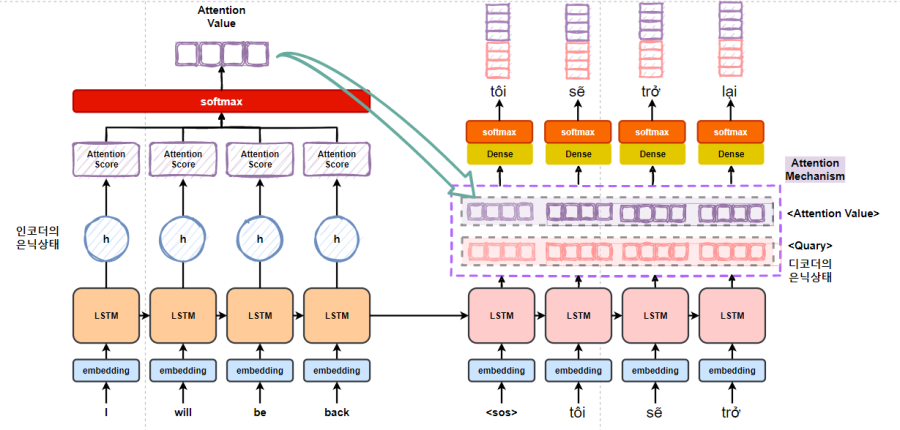

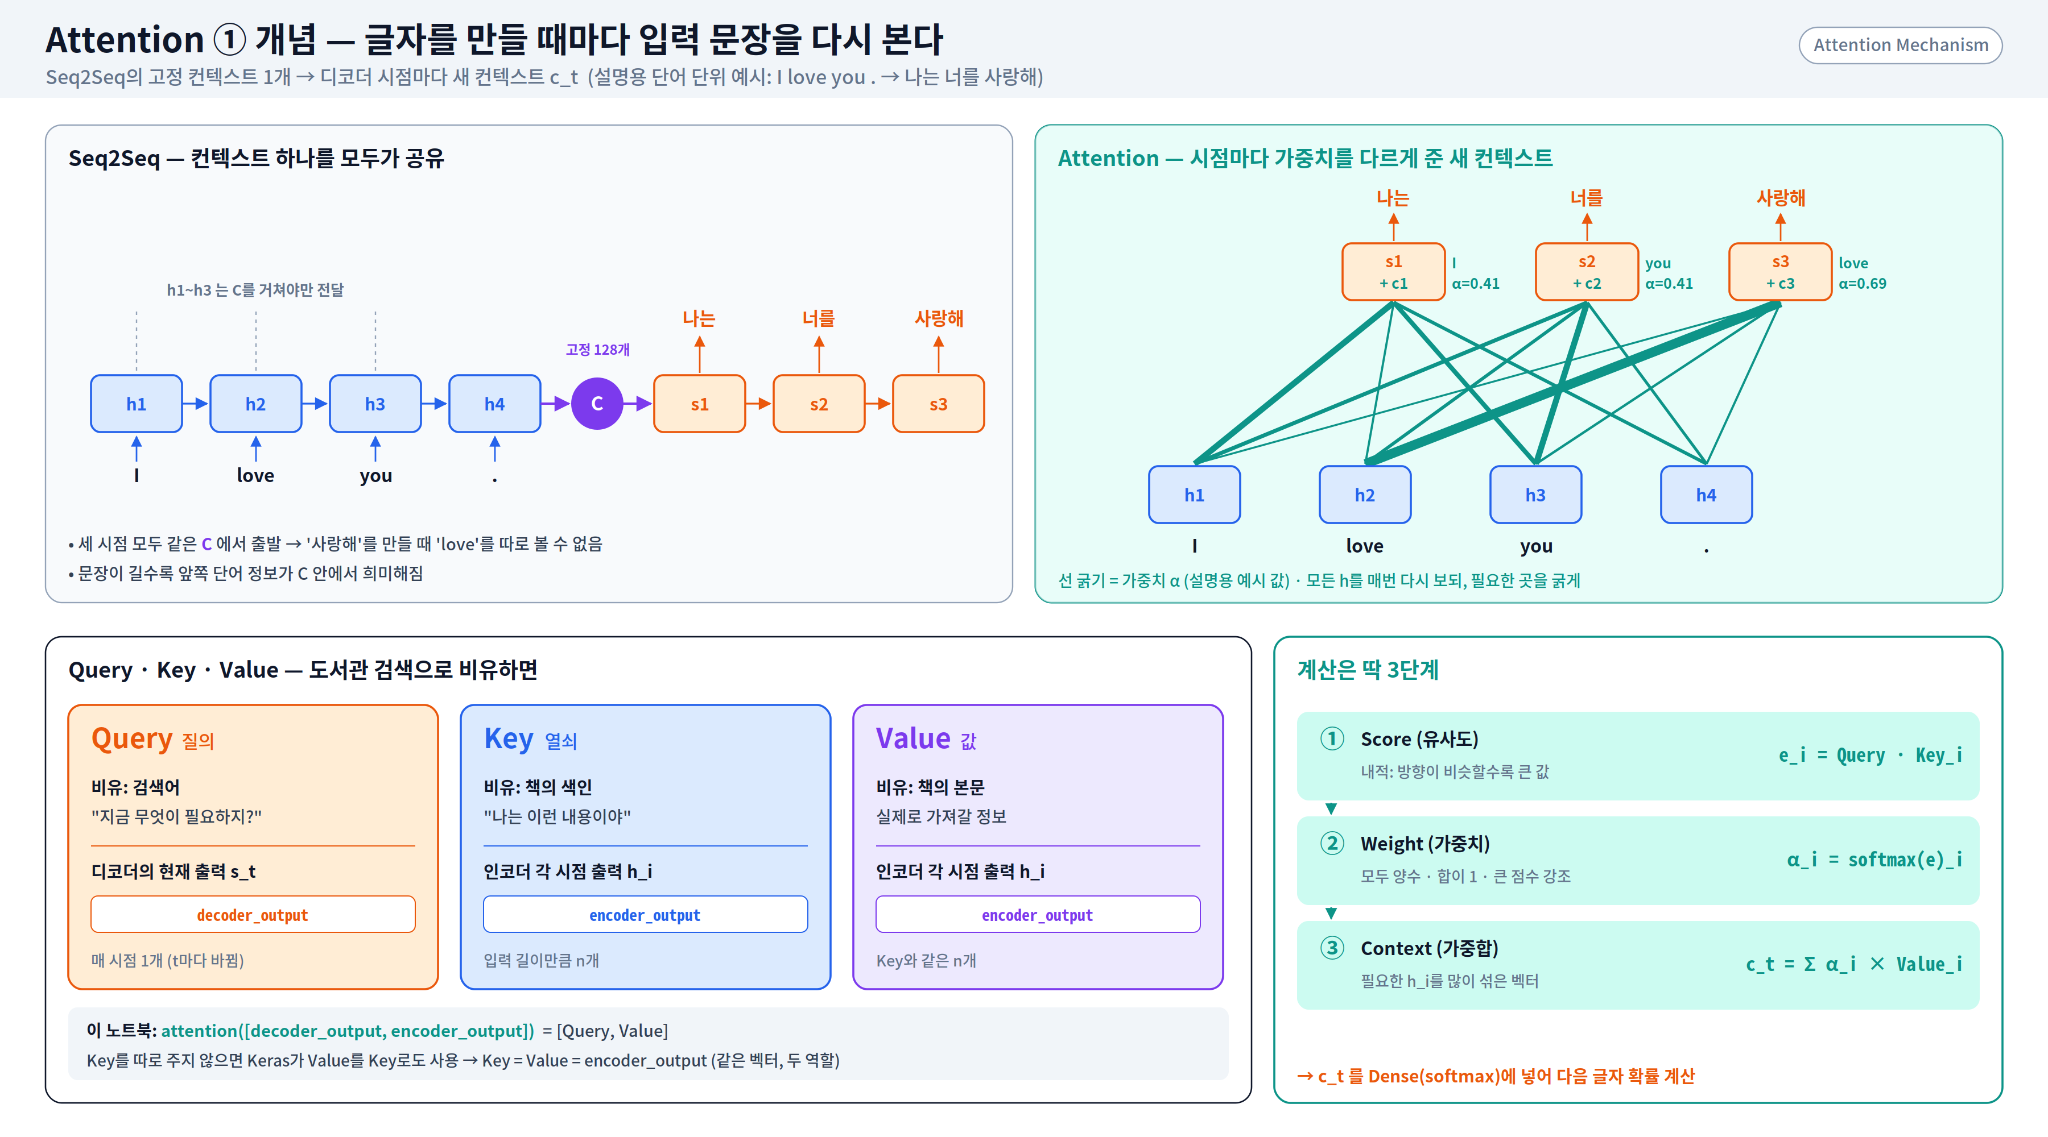

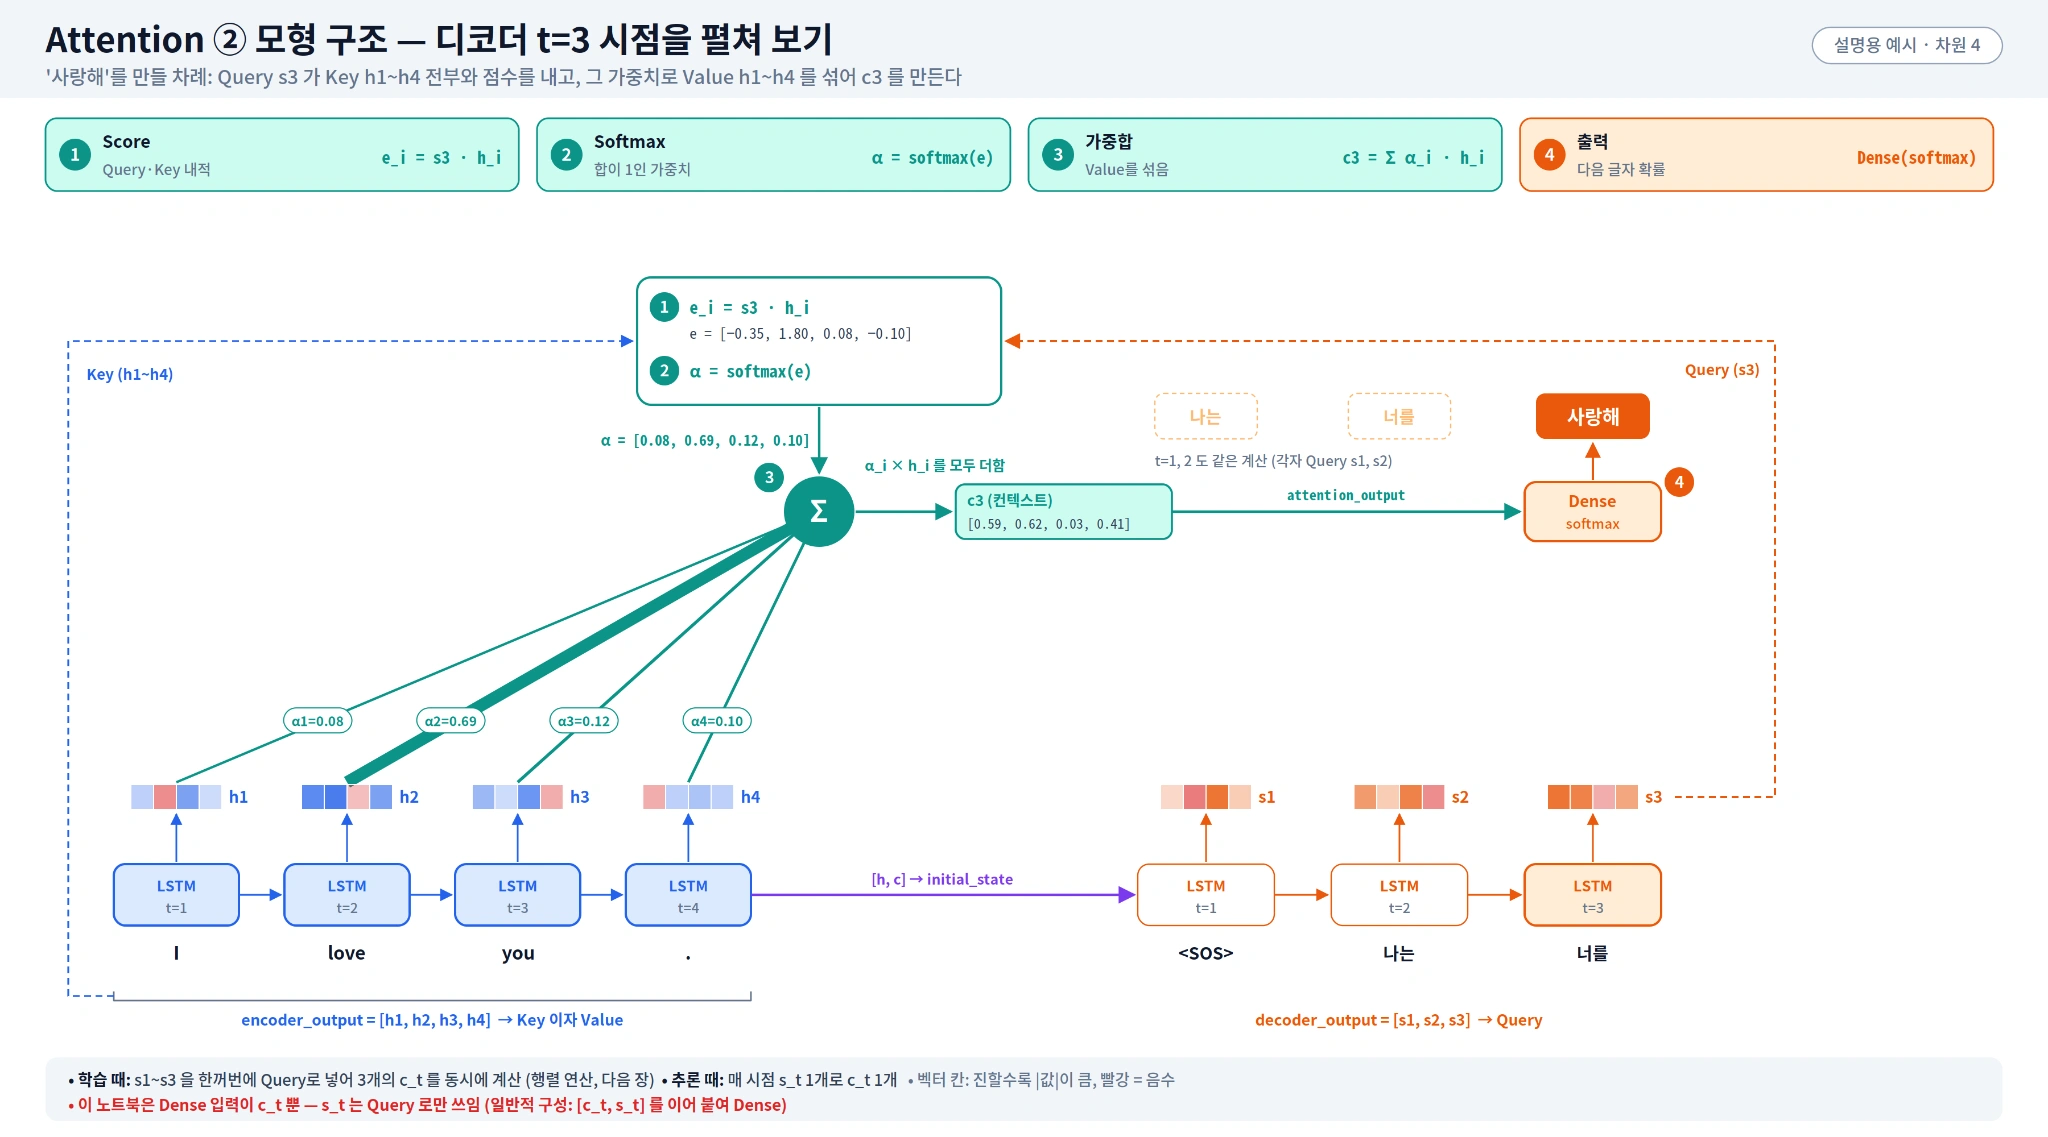

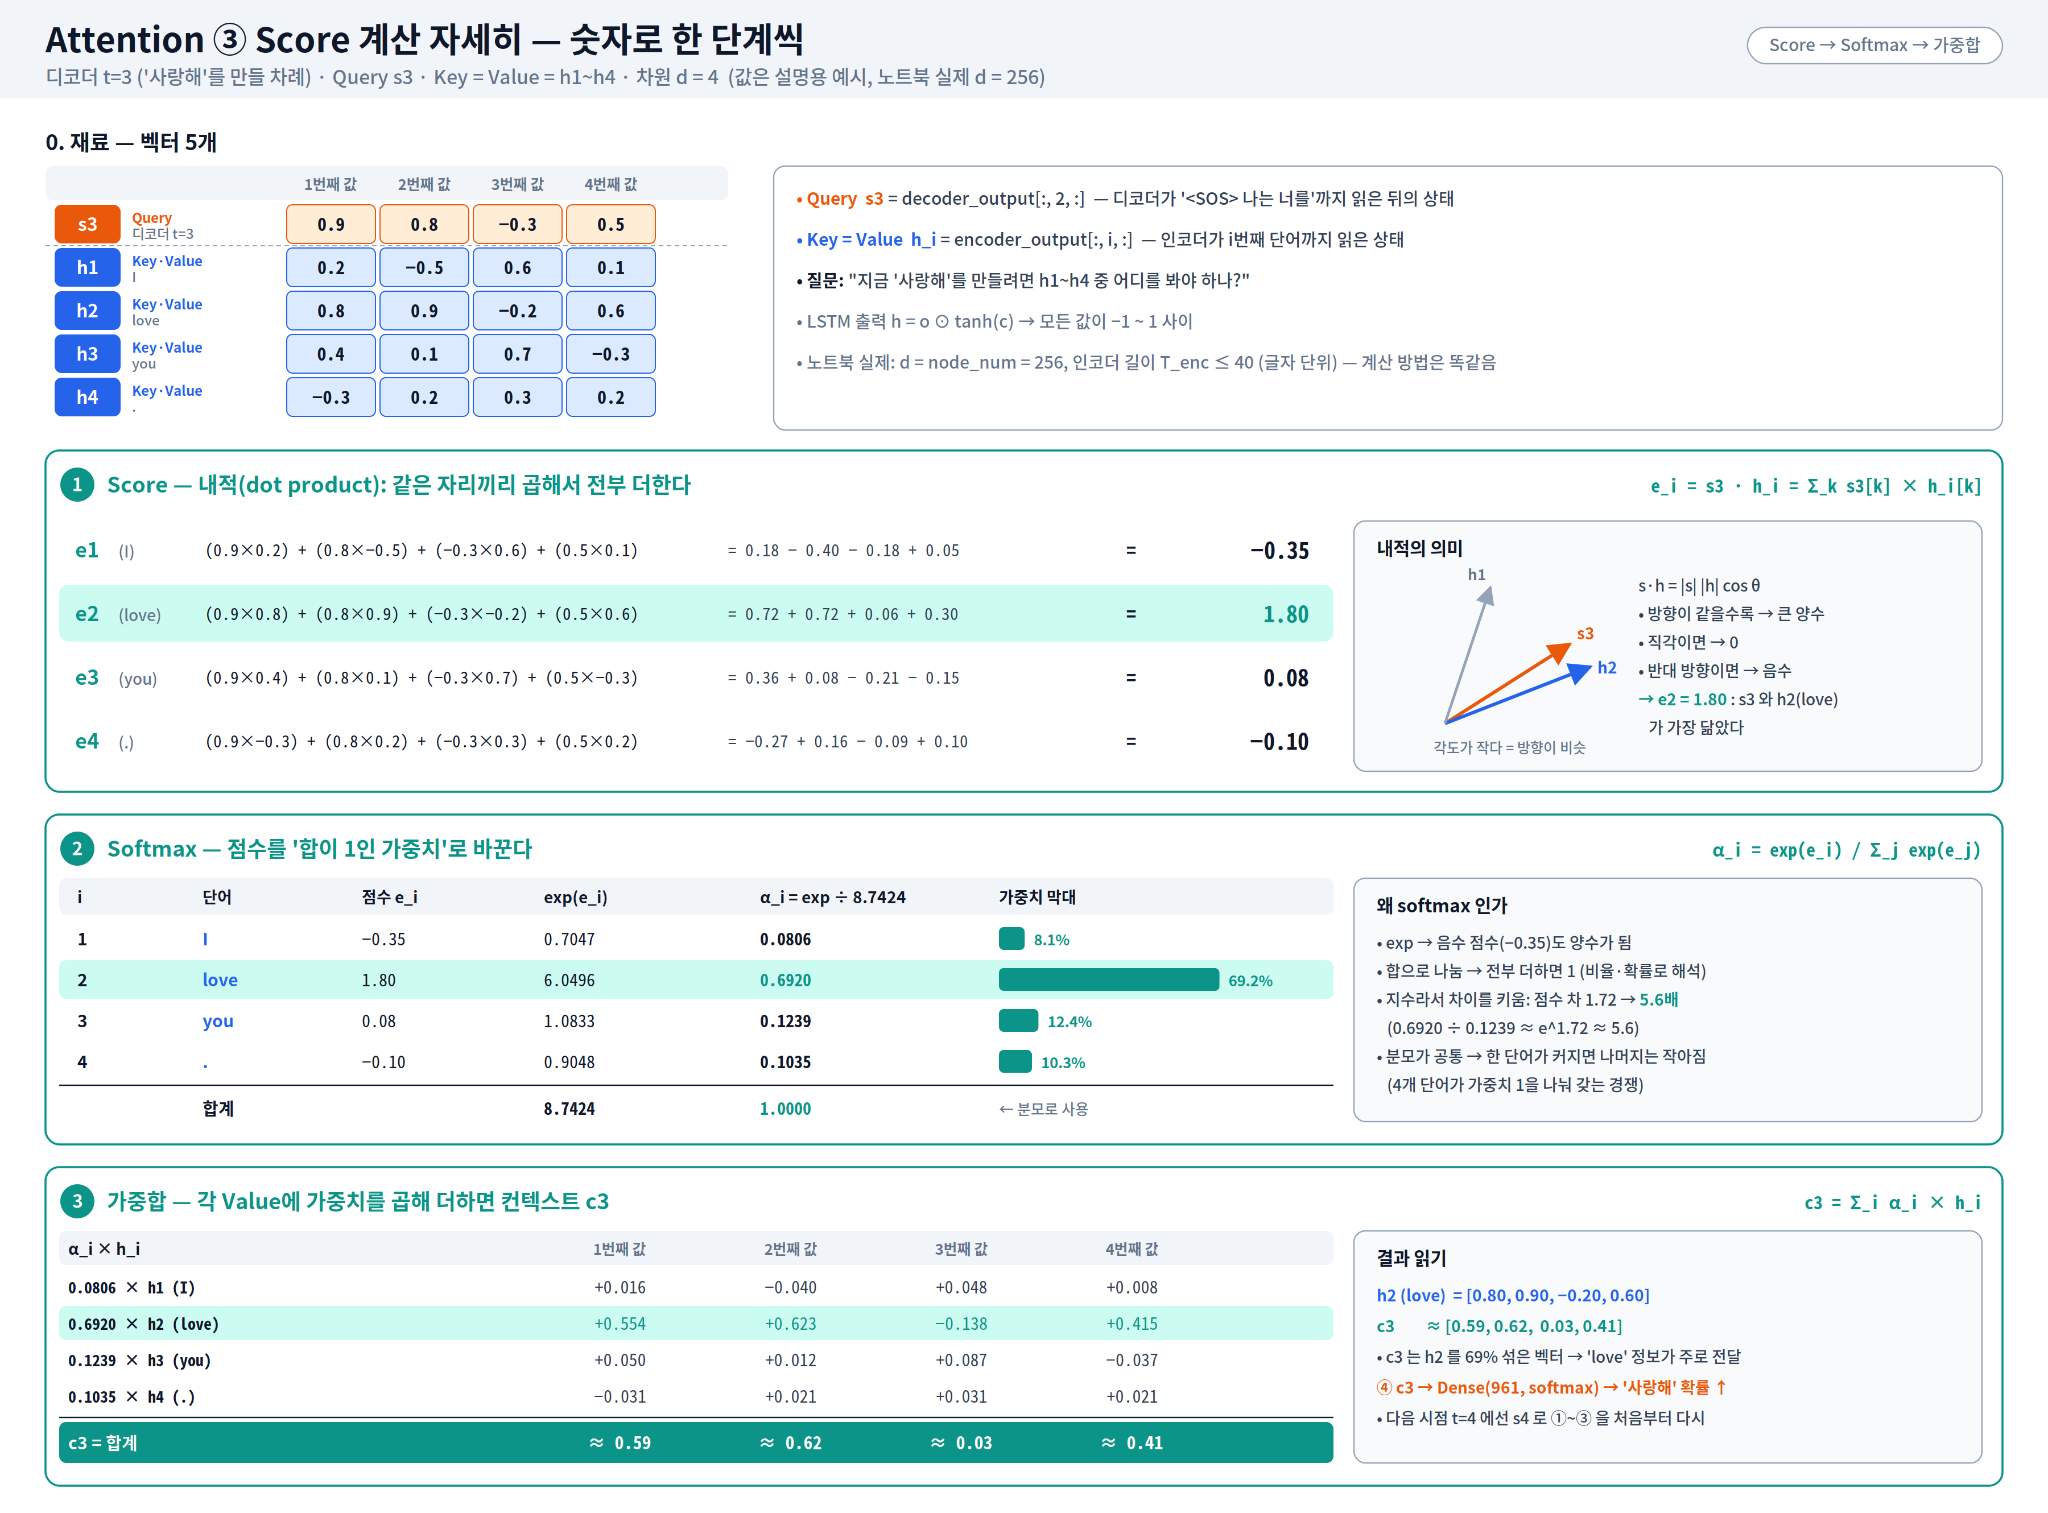

In [1]:
# 어텐션 메커니즘 그림 4장 (① 수업 그림 → ② 개념·QKV → ③ 모형 구조 t=3 펼침 → ④ Score 계산 숫자 예제)


# io : 파일을 디스크에 저장하지 않고 "메모리 안에서" 파일처럼 다루게 해주는 기본 도구
import io

# IPython.display의 Image : 출력 칸에 그림을 보여주는 기능
# display : 한 셀에서 여러 개를 차례로 출력하는 함수 (그냥 쓰면 마지막 줄 결과 1개만 보여서 필요)
from IPython.display import Image, display

# PIL(Pillow)의 Image : 그림 파일을 열고 형식을 바꾸는 기능 (이름이 겹쳐서 PILImage로 부름)
from PIL import Image as PILImage

# 보여줄 그림 목록 : (파일 경로, 화면 가로 픽셀) 쌍을 순서대로 담은 리스트
image_list = [
    ('images/A1_Attention_Seq2Seq_LSTM.png', 900),       # ① 강사님 수업 그림
    ('images/A1_Attention_개념_QKV.webp', 1000),         # ② 개념 + Query·Key·Value + 계산 3단계
    ('images/A2_Attention_모형구조_t3펼침.webp', 1000),  # ③ 디코더 t=3 시점 펼친 모형 구조
    ('images/A3_AttentionScore_계산_숫자예제.webp', 1000),  # ④ Attention Score 계산 숫자 예제
]
# for 문 : 목록에서 (경로, 너비)를 하나씩 꺼내 반복
for path, w in image_list:
    # io.BytesIO() : 메모리 속 빈 파일 (여기에 PNG를 임시로 저장)
    buf = io.BytesIO()

    # 그림 열기 → RGB 색상으로 맞추기 → 메모리 파일(buf)에 PNG 형식으로 저장
    # webp도 PNG로 바뀌어서 출력 칸에서 확실하게 보임
    PILImage.open(path).convert('RGB').save(buf, format='PNG')

    # buf.getvalue() : 메모리에 저장된 PNG 내용 / width : 화면 가로 크기
    display(Image(data=buf.getvalue(), width=w))


# → images 폴더의 그림 3장을 PNG로 바꿔가며 순서대로 셀 아래에 보여주겠다
# → ① 수업 그림 : 인코더 LSTM이 단어마다 h를 만들고, Query(디코더 상태)와 각 h의 Attention Score → softmax → Attention Value → Dense → softmax로 다음 단어 예측
# → ② 개념 : Seq2Seq는 고정 컨텍스트 C 하나를 공유 → Attention은 디코더 시점마다 모든 h를 다시 보고 필요한 곳에 가중치를 크게 줌
# → ② QKV : Query = 디코더 현재 출력 s_t (검색어) / Key = 인코더 출력 h_i (색인) / Value = 인코더 출력 h_i (본문)
# → ② 계산 3단계 : ① Score e_i = Query·Key_i → ② Weight α = softmax(e) → ③ Context c_t = Σ α_i × Value_i
# → ③ 모형 구조 : '사랑해'를 만들 t=3 시점에 e = [-0.35, 1.80, 0.08, -0.10] → α = [0.08, 0.69, 0.12, 0.10] → 'love'(h2)에 69% 집중
# → ③ c3(컨텍스트)를 Dense(softmax)에 넣어 다음 글자 확률 계산
# → 학습 때는 s1~s3를 한꺼번에 Query로 넣어 동시에 계산, 추론 때는 매 시점 s_t 1개로 c_t 1개
# → 그림 속 숫자는 설명용 예시 값 (실제 학습

In [2]:
# 어텐션 메커니즘을 수행할 라이브러리 호출


# pickle : 파이썬 객체(토크나이저, 리스트 등)를 파일로 저장하거나 불러오는 기본 도구
import pickle

# numpy : 숫자 배열(행렬) 계산 라이브러리. 문장을 숫자로 바꾼 데이터를 다룰 때 사용
import numpy as np

# Model : 입력층과 출력층을 연결해 하나의 모델로 묶는 클래스 (함수형 API 방식)
from keras.models import Model

# Input : 모델에 들어올 데이터의 모양(shape)을 정하는 입력층
from keras.layers import Input

# LSTM : 순서가 있는 데이터를 앞에서부터 읽으며 기억을 이어가는 순환 신경망 층 (인코더·디코더에 사용)
from keras.layers import LSTM

# Dense : 모든 뉴런이 연결된 층. 마지막에 softmax로 다음 단어 확률을 계산할 때 사용
from keras.layers import Dense

# Attention : Query와 Value(=Key)를 받아 Score → softmax → 가중합까지 계산해 Context Vector를 만들어주는 층
from keras.layers import Attention


# → 인코더·디코더(LSTM)에 어텐션 층을 붙인 Seq2Seq + Attention 모델을 만들 준비를 하겠다
# → 어제 Seq2Seq와 비교하면 새로 추가된 것은 Attention 층 하나
# → Attention 층이 마크다운에서 정리한 계산 흐름 1~3단계(Score → Weight → Context)를 한 번에 처리해준다

In [3]:
# 영어 문장과 한국어 문장을 숫자로 변환한 결과 불러오기


# open(경로, 'rb') : 파일을 연다
#   'r' = read(읽기), 'b' = binary(사람이 읽는 글자가 아닌 컴퓨터용 이진 데이터)
#   .sav는 pickle로 저장한 이진 파일이라 'rb'로 열어야 함
# pickle.load : 파일에 저장된 파이썬 객체를 원래 모양 그대로 되살림
load_seq_data = pickle.load(open('data/08_Translation_Data/eng_to_kor.sav', 'rb'))

# 저장된 객체가 3개짜리 묶음이라, 변수 3개에 순서대로 나눠 담음 (언패킹)
# encoder_input_data  : 인코더에 넣을 영어 문장 (숫자로 변환된 것)
# decoder_input_data  : 디코더에 넣을 한국어 문장 (시작 토큰 포함, Teacher Forcing용)
# decoder_target_data : 디코더가 맞혀야 할 정답 한국어 문장 (한 칸 뒤로 밀린 것)
encoder_input_data, decoder_input_data, decoder_target_data = load_seq_data


# → 어제 Seq2Seq 때 미리 숫자로 바꿔 저장해 둔 영어→한국어 번역 데이터를 그대로 불러오겠다
# → 전처리(문장 → 숫자)를 다시 하지 않고, 어제 결과를 재사용해서 모델 비교에 집중
# → 파일이 약 1.5GB라 실행에 시간이 조금 걸릴 수 있음

In [4]:
# 인코더 입력 데이터의 모양(shape) 확인


# .shape : 배열이 몇 차원이고 각 차원 크기가 얼마인지 알려주는 속성
# (문장 개수, 문장 내 토큰 위치(문장 내 최대 길이), 언어에 등장하는 토큰을 정수로 변환한 값)
encoder_input_data.shape


# → 결과 (5000, 39, 72)
# → 5000 : 학습에 쓰는 영어 문장 개수
# → 39   : 가장 긴 문장 기준 토큰 위치 수 (짧은 문장은 나머지 칸을 0으로 채움 = 패딩)
# → 72   : 영어 쪽에 등장하는 토큰 종류 수 → 각 위치가 72칸짜리 원-핫 벡터로 표현됨

(5000, 39, 72)

In [5]:
# 단어 토큰에 대한 사전 데이터


# token_index.sav : 토큰 ↔ 숫자 번호를 짝지어 둔 딕셔너리 2개가 묶여 저장된 파일
# input_token_index  : 영어(입력) 토큰 사전  예) {'a': 0, 'b': 1, ...}
# target_token_index : 한국어(출력) 토큰 사전
input_token_index, target_token_index = pickle.load(open('data/08_Translation_Data/token_index.sav', 'rb'))


# → 모델이 예측한 숫자를 다시 글자로 바꾸려면 "어떤 숫자가 어떤 토큰인지" 사전이 필요해서 불러오겠다

In [6]:
# 인코더·디코더 토큰 종류 수 확인


# len(딕셔너리) : 딕셔너리에 들어 있는 항목 개수 = 토큰 종류 수
# num_encoder_tokens : 영어 토큰 종류 수 (인코더 입력 벡터의 크기)
num_encoder_tokens = len(input_token_index)

# num_decoder_tokens : 한국어 토큰 종류 수 (디코더 입력·출력 벡터의 크기)
num_decoder_tokens = len(target_token_index)

print(num_encoder_tokens)
print(num_decoder_tokens)


# → 결과 72, 961
# → 72  : 셀 2 shape의 마지막 숫자 72와 일치 → 인코더 원-핫 벡터 크기
# → 961 : 한국어 토큰 종류 수 → 디코더 마지막 Dense 층의 출력 개수 (softmax로 961개 중 하나를 고름)
# → 영어 72개 = 알파벳 대소문자 + 숫자·문장부호·공백 수준 → 단어가 아니라 글자 단위로 쪼갠 데이터
# → 한국어 961개 = '가, 각, 간…' 같은 음절 글자 종류가 많아서
# → 이 두 숫자가 뒤에서 Input(shape=...)과 Dense(units=...)의 크기로 쓰인다

72
961


In [7]:
# 학습 하이퍼파라미터 설정


# batch_size : 한 번에 묶어서 학습하는 문장 개수
#   64문장씩 보고 가중치를 한 번 업데이트 (실제로 유의미한 결과가 나오는 수치는 128)
batch_size = 64

# epochs : 전체 데이터(5000문장)를 처음부터 끝까지 몇 번 반복해서 학습할지
#   수업에서는 시간 때문에 20, 실제로 쓸 만한 번역이 나오려면 200~500
epochs = 20

# node_num : LSTM 층의 뉴런(유닛) 개수 = 은닉 상태 벡터의 크기
#   클수록 문장 정보를 더 많이 담을 수 있지만 학습이 느려짐 (실제로는 1024개 이상)
node_num = 256

# max_encoder_seq_length : 인코더(영어) 문장의 최대 길이
# max_decoder_seq_length : 디코더(한국어) 문장의 최대 길이
#   추론할 때 "최대 몇 글자까지 만들지" 같은 한계값으로 사용
max_encoder_seq_length = 40
max_decoder_seq_length = 40


# → 수업용으로 가볍게 설정한 값 (batch 64, epoch 20, LSTM 256)
# → 강사님 주석의 * 값(128, 200~500, 1024)은 실전에서 제대로 된 결과를 얻기 위한 권장 수치
# → node_num 256은 인코더·디코더 LSTM과, 두 LSTM이 주고받는 은닉 상태 크기에 똑같이 쓰인다

In [8]:
# Encoder와 Decoder 정의 (Seq2Seq + Attention 모델 구조)


# ===== Encoder =====

# Input : 인코더 입력층
# shape=(None, num_encoder_tokens) : (문장 길이, 토큰 종류 수 72)
#   None = 문장 길이를 고정하지 않음 → 길이가 다른 문장도 넣을 수 있음
#   배치 크기(한 번에 넣는 문장 수)는 Keras가 자동으로 앞에 붙여줌
encoder_input = Input(shape=(None, num_encoder_tokens))

# [강사님] Attention Score를 계산하기 위해, Encoder에서도 각 Node의 결과를 출력 (return_sequences=True)
# LSTM(node_num) : 뉴런 256개짜리 LSTM 층
# return_state=True     : 마지막 은닉 상태(h)와 셀 상태(c)도 함께 돌려받음 → 디코더에 넘겨줄 용도
# return_sequences=True : 마지막 시점만이 아니라 "모든 시점(각 Node)"의 출력(h1, h2, ..., hn)을 돌려받음
#   ★ 어제 Seq2Seq와 가장 큰 차이 : 어텐션은 인코더의 모든 h와 Score를 계산해야 하므로 True가 필수
encoder_lstm = LSTM(node_num, return_state=True, return_sequences=True)

# encoder_output : 모든 시점의 출력 [h1, h2, ..., hn] → 어텐션의 Key 겸 Value
# state_h        : 마지막 시점의 은닉 상태 (단기 기억)
# state_c        : 마지막 시점의 셀 상태 (장기 기억)
encoder_output, state_h, state_c = encoder_lstm(encoder_input)

# 마지막 h, c를 묶어 디코더의 시작 상태로 넘김 (Context Vector)
encoder_state = [state_h, state_c]


# ===== Decoder =====

# 디코더 입력층 : (문장 길이, 한국어 토큰 종류 수 961)
decoder_input = Input(shape=(None, num_decoder_tokens))

# 디코더 LSTM : 인코더와 같은 크기(256)여야 상태를 이어받을 수 있음
# return_sequences=True : 매 시점마다 출력을 내야 매 시점 단어를 예측할 수 있음
decoder_lstm = LSTM(node_num, return_state=True, return_sequences=True)

# initial_state=encoder_state : 디코더를 인코더의 마지막 상태에서 출발시킴
# decoder_output : 디코더 모든 시점의 출력 [s1, s2, ..., st] → 어텐션의 Query
# d_h, d_c       : 디코더 마지막 상태 (학습 모델에서는 안 쓰고, 추론 모델에서 사용)
decoder_output, d_h, d_c = decoder_lstm(decoder_input, initial_state=encoder_state)


# ===== Attention =====

# [강사님] Attention Layer를 추가
# Attention() : 내적 방식 어텐션 층 (Score → softmax → 가중합을 한 번에 계산)
attention = Attention()

# [강사님] decoder_output : Query / encoder_output : Key-Value
# attention([Query, Value]) : 리스트 순서가 [Query, Value]
#   Query = decoder_output (디코더가 "지금 뭐가 필요하지?")
#   Value = encoder_output (인코더가 읽은 문장 정보)
#   Key를 따로 안 주면 Value를 Key로도 사용 → Key = Value = encoder_output
# attention_output : 디코더 각 시점마다 새로 만든 Context Vector [c1, c2, ..., ct]
attention_output = attention([decoder_output, encoder_output])


# ===== Output Layer =====

# Dense(num_decoder_tokens) : 출력 뉴런 961개 = 한국어 토큰 종류 수
# activation='softmax' : 961개 점수를 합이 1인 확률로 바꿈 → 가장 높은 것이 다음 글자
decoder_dense = Dense(num_decoder_tokens, activation='softmax')

# [강사님] 최종 출력 (Decoder)
# 어텐션 결과(Context Vector)를 넣어 매 시점 다음 글자의 확률을 계산
decoder_outputs = decoder_dense(attention_output)



# → 인코더가 영어 문장을 읽어 모든 시점의 h와 마지막 상태를 만들고
# → 디코더는 인코더 마지막 상태에서 출발해 한국어를 한 글자씩 만들며
# → 매 시점 어텐션이 디코더 상태(Query)로 인코더 전체 h(Key·Value)를 다시 훑어 Context Vector를 만들고
# → 그 Context Vector를 Dense(softmax)에 넣어 다음 글자 확률을 계산하겠다
# → 마크다운의 계산 흐름 1~4단계가 attention(...) 한 줄과 decoder_dense(...) 한 줄로 구현된 것

### 정리 : 어제 Seq2Seq와 비교

| 구분 | Day10 Seq2Seq | Day11 Seq2Seq + Attention |
|---|---|---|
| 인코더 `return_sequences` | `False` (마지막 h만) | **`True`** (모든 시점 h) |
| 인코더에서 쓰는 것 | 마지막 상태 `[h, c]`만 | 마지막 상태 + **모든 h** |
| Dense 입력 | `decoder_output` | **`attention_output`** |
| 새로 추가된 층 | 없음 | **`Attention()`** |

### 참고

- 위 셀은 **층을 연결해서 설계도만 만든 것**이라 실행해도 출력이 없다 → 오류 없이 셀 번호만 붙으면 성공. 실제 모델로 묶는 건 다음 셀의 `Model(...)`
- `decoder_output` vs `decoder_outputs` : **s 하나 차이로 다른 변수**
    - `decoder_output` : 디코더 LSTM의 모든 시점 출력 → 어텐션의 **Query**
    - `decoder_outputs` : Dense(softmax)를 거친 **최종 확률 출력**
- 이 노트북은 Dense 입력이 **Context Vector(`attention_output`)뿐**
    - 일반적인 구성 : `[attention_output, decoder_output]`을 이어 붙여(**Concatenate**) Dense에 넣음 → Context와 디코더 자신의 상태를 함께 보고 예측

In [9]:
# 모델 생성, 컴파일, 학습


# ===== Model =====

# Model([입력들], 출력) : 앞 셀에서 연결한 층들을 하나의 모델로 묶음 (함수형 API)
# 입력이 2개 → [encoder_input, decoder_input] 리스트로 전달
#   encoder_input : 영어 문장 / decoder_input : Teacher Forcing용 한국어 문장
# 출력 : decoder_outputs (매 시점 961개 한국어 토큰의 확률)
model = Model([encoder_input, decoder_input], decoder_outputs)


# ===== Compile =====

# compile : 학습 방법을 정하는 단계
# optimizer='adam' : 가중치를 어떻게 고칠지 정하는 방법. 학습률을 알아서 조절해줘서 가장 많이 씀
# loss='categorical_crossentropy' : 정답과 예측 확률의 차이를 재는 손실 함수
#   정답(decoder_target_data)이 원-핫 벡터라서 categorical 버전을 사용
#   (정답이 원-핫이 아니라 정수 번호였다면 sparse_categorical_crossentropy)
model.compile(optimizer='adam', loss='categorical_crossentropy')


# ===== Train =====

# fit : 실제 학습 실행
# [encoder_input_data, decoder_input_data] : 모델 입력 2개 (Model 정의 순서와 같아야 함)
# decoder_target_data : 정답 (디코더 입력보다 한 칸 뒤로 밀린 한국어 문장)
# batch_size=batch_size : 64문장씩 묶어서 학습
# epochs=epochs : 전체 데이터를 20번 반복 학습
# validation_split=0.2 : 데이터의 20%(1000문장)는 학습에 쓰지 않고 검증용으로 떼어둠
#   → 매 에포크마다 "처음 보는 문장"에서의 손실(val_loss)도 함께 보여줌
model.fit([encoder_input_data, decoder_input_data], decoder_target_data,
          batch_size=batch_size, epochs=epochs, validation_split=0.2)


# → 인코더·디코더·어텐션을 하나의 모델로 묶고, adam + categorical_crossentropy로 학습 방법을 정한 뒤
# → 영어 문장과 Teacher Forcing용 한국어 문장을 넣어 정답 한국어 문장을 맞히도록 20 에포크 학습하겠다
# → 학습 4000문장 / 검증 1000문장, 에포크 1번당 약 63번 가중치 업데이트 (4000 ÷ 64)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 48s 678ms/step - loss: 1.7331 - val_loss: 2.3985
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 608ms/step - loss: 1.6186 - val_loss: 2.3963
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 552ms/step - loss: 1.6184 - val_loss: 2.3961
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 653ms/step - loss: 1.6183 - val_loss: 2.3958
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 462ms/step - loss: 1.6182 - val_loss: 2.4007
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 383ms/step - loss: 1.6181 - val_loss: 2.3990
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 692ms/step - loss: 1.6187 - val_loss: 2.3958
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - loss: 1.6188 - val_loss: 2.3947
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 378ms/step - loss: 1.6186 - val_loss: 2.3958
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 385ms/step - loss: 1.6185 - val_loss: 2.3973
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 402ms/step - loss: 1.6192 - val_loss: 2.3971
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 4

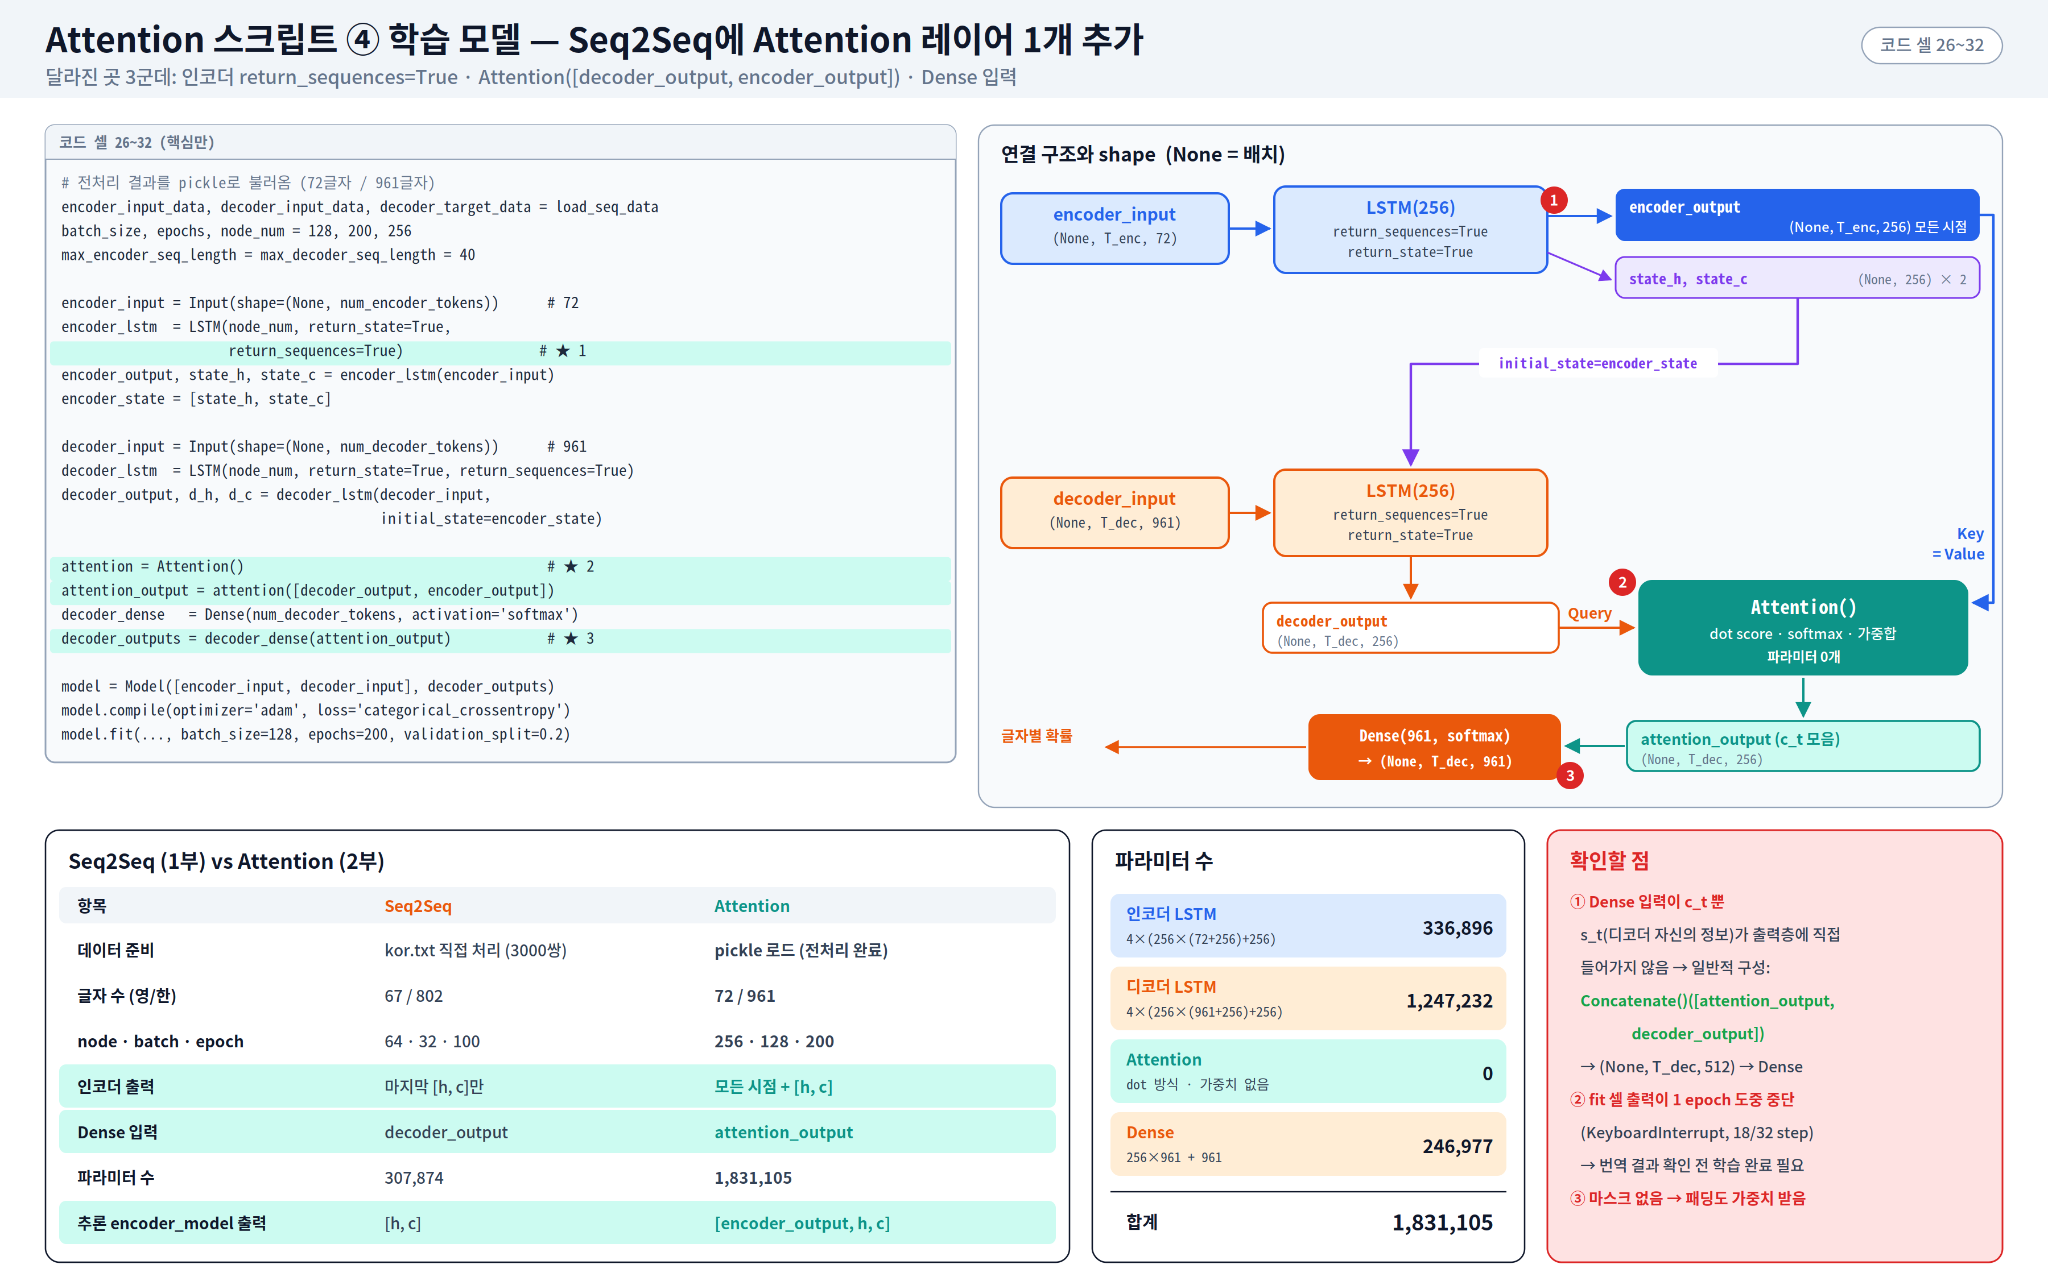

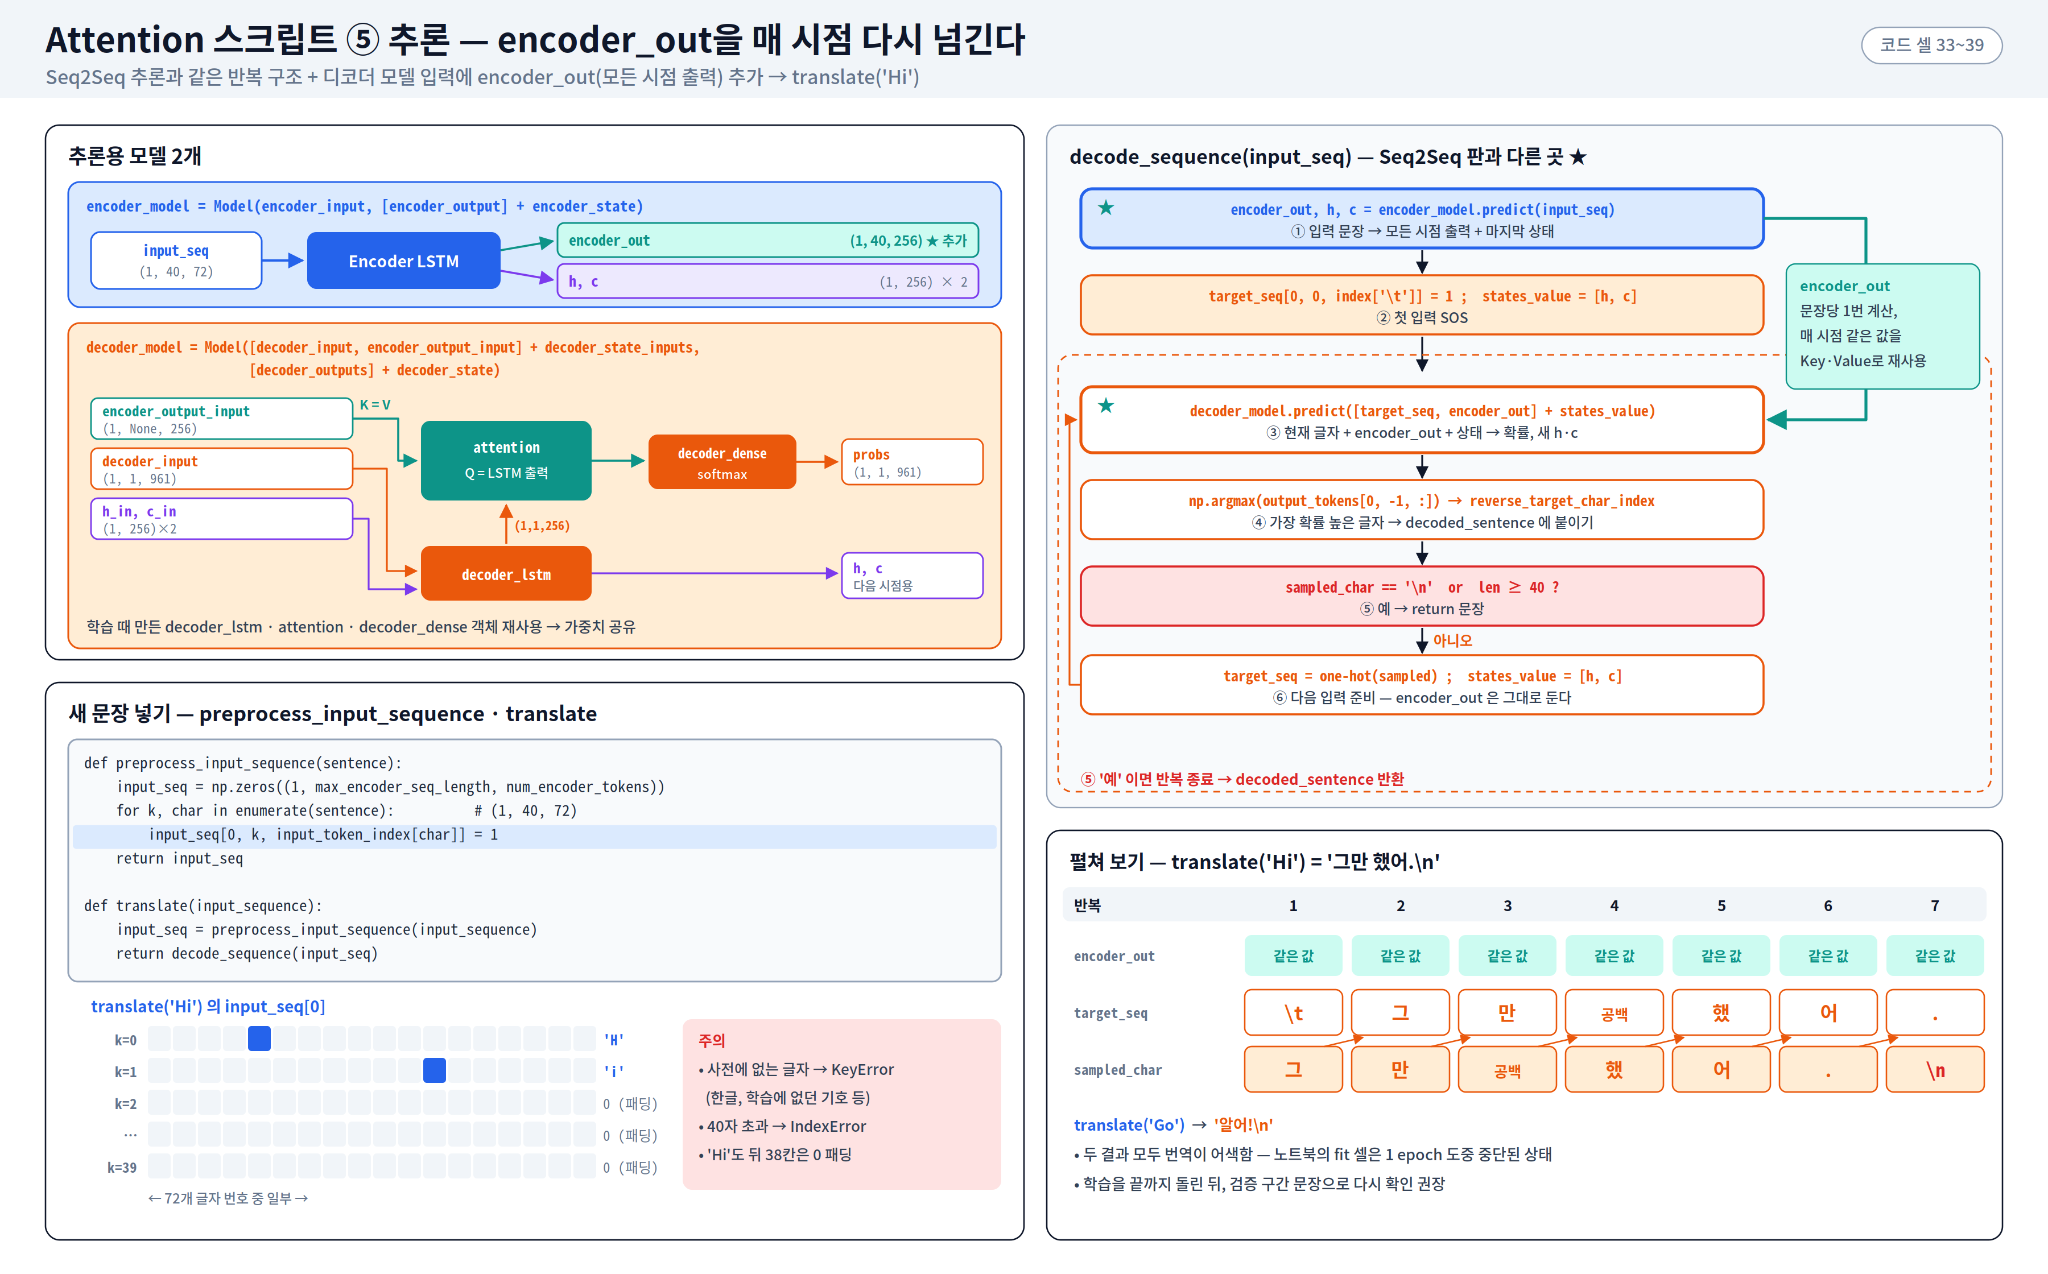

In [10]:
# 스크립트 4·5 그림 (A5 Attention 학습 모델 → A6 Attention 추론)


# io : 파일을 디스크에 저장하지 않고 "메모리 안에서" 파일처럼 다루게 해주는 기본 도구
import io

# IPython.display의 Image : 출력 칸에 그림을 보여주는 기능
# display : 한 셀에서 여러 개를 차례로 출력하는 함수
from IPython.display import Image, display

# PIL(Pillow)의 Image : 그림 파일을 열고 형식을 바꾸는 기능 (이름이 겹쳐서 PILImage로 부름)
from PIL import Image as PILImage

# 보여줄 그림 목록 : (파일 경로, 화면 가로 픽셀)
image_list = [
    ('images/A5_스크립트4_Attention_학습모델.webp', 1000),  # ⑤ 학습 모델 구조
    ('images/A6_스크립트5_Attention_추론.webp', 1000),      # ⑥ 추론 모델 구조
]

# 목록에서 하나씩 꺼내 webp → PNG로 메모리에서 변환한 뒤 출력
for path, w in image_list:
    buf = io.BytesIO()
    PILImage.open(path).convert('RGB').save(buf, format='PNG')
    display(Image(data=buf.getvalue(), width=w))


# → images 폴더의 A5(학습 모델), A6(추론 모델) 그림을 차례로 보여주겠다
# → 학습 모델 : 정답 한국어 문장을 한꺼번에 넣어(Teacher Forcing) 모든 시점을 동시에 계산
# → 추론 모델 : 정답이 없으므로 한 글자씩 예측하고, 예측한 글자를 다음 입력으로 다시 넣음

In [11]:
# 추론 모형 구성 파트
# 학습이 완료된 Encoder와 Decoder를 분리하여, 새로운 문장이 들어올 때 추론(번역)을 수행하게 함


# ===== Encoder Model =====

# Model(입력, 출력) : 학습 모델에서 인코더 부분만 떼어낸 모델
# encoder_input  : 입력 문장 토큰 (영어 문장)
# encoder_output : Encoder LSTM의 모든 시점(Timestep) 출력값 [h1 ~ hn] → Attention 계산에 필요
# encoder_state  : Encoder 마지막 시점의 Hidden State / Cell State [h, c] → Context Vector
# [encoder_output] + encoder_state : 리스트 + 리스트 = 이어 붙이기 → [모든 시점 h, 마지막 h, 마지막 c] 3개 출력
encoder_model = Model(encoder_input, [encoder_output] + encoder_state)


# ===== Decoder State Inputs =====

# Decoder는 한 글자씩 순차적으로 예측(Autoregressive)하므로, 매 시점마다 이전 상태를 입력으로 받아야 함
#   Autoregressive(자기회귀) : 방금 만든 출력을 다음 시점의 입력으로 다시 쓰는 방식
# Input(shape=(node_num,)) : 크기 256짜리 벡터 하나 (시간 축 없음)
#   (node_num,)의 쉼표 : 원소가 1개인 튜플이라는 표시. 쉼표가 없으면 그냥 숫자 256이 됨

# 이전 시점의 Hidden State (단기 기억 h)
decoder_state_input_h = Input(shape=(node_num,))

# 이전 시점의 Cell State (장기 기억 c)
decoder_state_input_c = Input(shape=(node_num,))

# 두 입력을 리스트로 묶어 LSTM의 initial_state로 넣을 준비
decoder_state_inputs = [decoder_state_input_h, decoder_state_input_c]


# ===== Encoder Output Input =====

# Attention 계산을 위해 Encoder의 전체 출력(h1 ~ hn)을 입력으로 받음 → Key·Value로 사용
# Decoder의 매 시점마다 Encoder의 어떤 부분에 집중할지를 결정하는 데 사용
# shape=(None, node_num) : (문장 길이는 가변, 각 시점 256)
# 추론 때는 encoder_model을 먼저 한 번 돌려서 나온 encoder_output을 여기에 넣어줌
encoder_output_input = Input(shape=(None, node_num))


# ===== Decoder (Reuse) =====

# decoder_lstm : 학습 때 만든 LSTM 층을 그대로 재사용 → 학습된 가중치를 공유
# decoder_input        : 현 시점에서 입력되는 글자 (이전 시점에서 예측한 글자)
# decoder_state_inputs : 이전 시점의 Hidden / Cell State
#   첫 글자일 때만 인코더 마지막 상태를 넣고, 그다음부터는 디코더가 방금 낸 상태를 넣음
decoder_outputs, state_h, state_c = decoder_lstm(decoder_input,
                                                 initial_state=decoder_state_inputs)

# decoder_outputs  : 현 시점 Decoder의 출력 → 어텐션의 Query
# state_h, state_c : 현 시점에서 계산된 State → 다음 시점 LSTM으로 전달
decoder_state = [state_h, state_c]


# ===== Attention (Reuse) =====

# attention : 학습 때 만든 어텐션 층 재사용
# decoder_outputs(Query)와 encoder_output_input(Key-Value)을 비교하여,
# 현재 시점에서 입력 토큰(Encoder)의 어떤 부분에 집중할지 가중치를 적용해 Context Vector를 만듦
attention_output = attention([decoder_outputs, encoder_output_input])


# ===== Output Layer (Reuse) =====

# 최종 출력 층 (추론 출력)
# decoder_dense : 학습 때 만든 Dense(softmax) 재사용
# Attention이 적용된 결과(Context Vector)를 Dense 층에 통과시켜 각 글자(961개)의 확률을 계산
decoder_outputs = decoder_dense(attention_output)


# ===== Decoder Model =====

# 추론용 디코더 모델 정의 : 위에서 연결한 입력 4개 → 출력 3개를 하나의 모델로 묶음
# 입력 : [decoder_input, encoder_output_input] + decoder_state_inputs
#   → [현 시점 글자, 인코더 모든 시점 출력, 이전 h, 이전 c] 4개
# 출력 : [decoder_outputs] + decoder_state
#   → [다음 글자 확률, 새 h, 새 c] 3개
decoder_model = Model([decoder_input, encoder_output_input] + decoder_state_inputs,
                      [decoder_outputs] + decoder_state)


# → 학습된 모델을 추론용 encoder_model과 decoder_model 두 개로 나누겠다
# → encoder_model : 영어 문장을 한 번 넣으면 [모든 시점 h, 마지막 h, 마지막 c]를 돌려줌
# → decoder_model : [직전 글자, 인코더 모든 h, 직전 h, 직전 c]를 받아 [다음 글자 확률, 새 h, 새 c]를 냄
# → 번역할 때는 decoder_model이 낸 "새 h, c"와 "예측한 글자"를 다시 decoder_model에 넣는 것을 반복 (Autoregressive)
# → decoder_lstm, attention, decoder_dense는 새로 만들지 않고 재사용 → 학습된 가중치를 그대로 씀

### 정리 : 추론 모형을 따로 만드는 이유

- **왜 모델을 나누나?**
    - 학습 때 : 정답 문장을 통째로 넣어 모든 시점을 한 번에 계산 (Teacher Forcing)
    - 추론 때 : 정답이 없음 → **인코더는 한 번만** 돌리고, **디코더는 한 글자씩 반복**해서 돌려야 함
- **층 재사용 = 가중치 공유**
    - `LSTM(...)`, `Attention()`, `Dense(...)`를 **새로 만들면** 학습 안 된 빈 층이 됨
    - 이미 만든 `decoder_lstm`, `attention`, `decoder_dense`를 **다시 호출**해야 학습된 가중치를 그대로 사용
- **변수 이름 덮어쓰기**
    - `decoder_outputs`, `state_h`, `state_c`는 학습 모델 때 쓴 이름을 **덮어쓰는** 것
    - 학습 모델은 이미 `model`로 묶여 있어서 덮어써도 문제없음

### 정리 : 학습 모델 vs 추론 모델

| 구분 | 학습 모델 (`model`) | 추론 모델 (`encoder_model` + 디코더) |
|---|---|---|
| 디코더 입력 | 정답 한국어 문장 전체 (Teacher Forcing) | **직전에 예측한 글자 1개** |
| 디코더 시작 상태 | 인코더 마지막 상태 `encoder_state` | 첫 글자 : 인코더 마지막 상태 / 이후 : **직전 디코더 상태** |
| 인코더 모든 h | 모델 안에서 바로 연결 | `encoder_output_input`으로 **따로 입력** |
| 계산 방식 | 모든 시점을 한 번에 | 한 글자씩 반복 (끝 토큰이 나올 때까지) |

In [12]:
# 모형이 추론한 결과(토큰 번호)를 다시 글자로 변환하기 위한 역방향 사전


# input_token_index  : {'글자': 번호} 형태 (예: {'a': 0, 'b': 1, ...})
# .items() : 딕셔너리의 (키, 값) 쌍을 하나씩 꺼냄 → ('a', 0), ('b', 1), ...
# for char, i in ... : 꺼낸 쌍에서 글자는 char, 번호는 i에 담음
# (i, char) : 순서를 뒤집어 (번호, 글자) 쌍으로 만듦
# dict(...) : 뒤집은 쌍들로 새 딕셔너리 생성 → {0: 'a', 1: 'b', ...}
reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())

# 한국어(출력) 쪽도 같은 방식으로 뒤집음 → {번호: '한글 글자'}
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())


# → 모델은 "번호"로 예측하므로, 번호를 보고 바로 글자를 찾을 수 있게 키와 값을 뒤집은 사전을 만들겠다
# → 예) 모델이 152번을 예측 → reverse_target_char_index[152] → '사'

In [13]:
# 번역(추론) 함수 : 영어 문장 1개를 받아 한국어 문장을 한 글자씩 만들어 돌려줌


def decode_sequence(input_seq):

    # ===== 1. Encoder =====

    # Encoder에 입력 문장을 넣어 결과를 계산 (문장당 딱 한 번만 실행)
    # encoder_model.predict : 인코더 모델에 문장을 넣어 출력 3개를 받음
    #   verbose=0 : 진행 막대 같은 출력 메시지를 끔 (한 글자마다 뜨면 화면이 지저분해짐)
    # encoder_out : 인코더 모든 시점 출력 [h1 ~ hn] → 매 시점 Attention 계산에 사용
    # h, c        : 인코더 마지막 시점의 Hidden / Cell State
    encoder_out, h, c = encoder_model.predict(input_seq, verbose=0)

    # states_value : 디코더 첫 시점의 시작 상태 (Context Vector)
    #   이후에는 디코더가 새로 낸 h, c로 계속 바꿔 끼움
    states_value = [h, c]


    # ===== Start Token =====

    # 출력 토큰이 담길 Matrix 구성
    # np.zeros((1, 1, num_decoder_tokens)) : (문장 1개, 글자 1개, 961칸)짜리 0으로 채운 배열
    target_seq = np.zeros((1, 1, num_decoder_tokens))

    # <SOS>(시작 토큰) 지정 : 탭 문자('\t') 번호 칸만 1로 바꿔 "문장 시작" 원-핫 벡터 완성
    target_seq[0, 0, target_token_index['\t']] = 1

    # 종료 조건 : ① <EOS>(줄바꿈 '\n')가 나오거나 ② 문장이 최대 길이에 도달하면 멈춤
    # stop_condition : True인 동안 while 문을 계속 반복 (이름과 달리 "계속할지" 여부)
    stop_condition = True

    # decoded_sentence : 예측한 글자를 하나씩 이어 붙일 빈 문자열
    decoded_sentence = ''


    # ===== 2. Autoregressive Loop =====

    # 한 글자씩 순차적으로 예측하는 반복문
    while stop_condition:

        # [Decoder에 현재 글자 + Encoder 전체 출력 + 이전 상태]를 입력하여 다음 글자를 추론
        # 입력 4개 : [target_seq, encoder_out] + states_value = [현재 글자, 인코더 모든 h, 이전 h, 이전 c]
        # 출력 3개 : output_tokens(다음 글자 961개 확률), h, c(새 상태)
        output_tokens, h, c = decoder_model.predict(
            [target_seq, encoder_out] + states_value, verbose=0)

        # output_tokens[0, -1, :] : 첫 번째 문장(0)의 마지막 시점(-1)의 961개 확률 전체(:)
        # np.argmax : 가장 큰 값의 위치(번호)를 반환 → 확률이 가장 높은 글자의 번호
        sampled_token_index = np.argmax(output_tokens[0, -1, :])

        # 역방향 사전으로 번호 → 글자 변환
        sampled_char = reverse_target_char_index[sampled_token_index]

        # 예측한 글자를 문장 뒤에 이어 붙임 (+= : 기존 값에 더해서 다시 저장)
        decoded_sentence += sampled_char

        # 종료 확인 : 끝 토큰('\n')이 나왔거나, 문장 길이가 최대 길이(40) 이상이면 반복 종료
        # or : 둘 중 하나만 참이어도 참
        if (sampled_char == '\n') or (len(decoded_sentence) >= max_decoder_seq_length):
            stop_condition = False

        # 다음 시점 입력 준비 : 방금 예측한 글자를 새 원-핫 벡터로 만들어 다음 입력으로 사용
        target_seq = np.zeros((1, 1, num_decoder_tokens))
        target_seq[0, 0, sampled_token_index] = 1

        # 다음 시점 상태 준비 : 디코더가 방금 낸 h, c로 교체
        states_value = [h, c]


    # ===== 3. Return =====

    # 완성된 한국어 문장을 돌려줌
    return decoded_sentence


# → 영어 문장을 인코더에 한 번 넣고, 시작 토큰('\t')부터 출발해
# → 디코더가 [현재 글자, 인코더 모든 h, 이전 상태]로 다음 글자를 예측 → 문장에 붙임 → 그 글자와 새 상태를 다시 입력
# → 끝 토큰('\n')이 나오거나 40글자가 될 때까지 반복해서 번역 문장을 완성하겠다
# → 매 시점 decoder_model 안에서 Attention이 인코더 전체 h를 다시 훑어 Context Vector를 만든다

### 정리 : decode_sequence 한 바퀴 흐름

| 순서 | 하는 일 | 핵심 코드 |
|---|---|---|
| ① | 영어 문장을 인코더에 **한 번만** 넣기 | `encoder_model.predict(input_seq)` |
| ② | 시작 토큰 `'\t'`을 원-핫으로 준비 | `target_seq[0, 0, target_token_index['\t']] = 1` |
| ③ | 디코더로 다음 글자 확률 예측 | `decoder_model.predict([target_seq, encoder_out] + states_value)` |
| ④ | 확률이 가장 높은 글자 고르기 | `np.argmax(...)` → `reverse_target_char_index[...]` |
| ⑤ | 끝 토큰 `'\n'` 또는 40글자면 종료 | `stop_condition = False` |
| ⑥ | 고른 글자 + 새 상태를 다음 입력으로 | `target_seq`, `states_value` 갱신 → ③으로 |

### 참고

- **Autoregressive** : ⑥에서 "내가 방금 만든 글자"를 다음 입력으로 다시 넣는 구조 → 학습 때의 Teacher Forcing(정답을 넣어줌)과 반대
- **argmax는 매번 가장 확률 높은 글자 1개만 고르는 방식(Greedy Search)** → 빠르지만, 앞에서 한 글자를 틀리면 뒤 글자도 연쇄적으로 틀어질 수 있음
- 반환된 문장 끝에는 끝 토큰 `'\n'`이 붙어 있음 (글자를 붙인 **뒤에** 종료를 확인하기 때문) → 출력할 때 줄바꿈이 한 번 더 생길 수 있음

In [14]:
# 영어로 입력한 글자를 원-핫 벡터로 변환 → (1, 40, 72) Matrix로 변환


def preprocess_input_sequence(sentence):

    # np.zeros((1, max_encoder_seq_length, num_encoder_tokens)) : (문장 1개, 40칸, 72종류)짜리 0 배열
    #   학습 데이터 encoder_input_data와 같은 모양(글자 위치 × 글자 종류)으로 빈 틀을 만듦
    # dtype='float32' : 숫자 형식을 32비트 실수로 지정 (모델이 학습한 데이터 형식과 맞춤)
    input_seq = np.zeros((1, max_encoder_seq_length, num_encoder_tokens), dtype='float32')

    # enumerate(sentence) : 문장에서 글자를 하나씩 꺼내면서 몇 번째인지(k)도 같이 알려줌
    #   예) 'Hi' → (0, 'H'), (1, 'i')
    for k, char in enumerate(sentence):

        # input_token_index[char] : 그 글자의 번호
        # [0, k, 번호] 칸만 1로 바꿈 → k번째 위치에 그 글자가 있다는 원-핫 표시
        input_seq[0, k, input_token_index[char]] = 1

    # 완성된 원-핫 배열을 돌려줌 → 이걸 decode_sequence에 넣으면 번역됨
    return input_seq


# → 사용자가 입력한 영어 문장을 학습 데이터와 똑같은 (1, 40, 72) 원-핫 형태로 바꾸겠다
# → 글자마다 위치(k)와 종류(번호)에 해당하는 칸만 1로 표시하고 나머지는 0 (패딩)

### 참고 : preprocess_input_sequence 사용 시 주의

- **학습 데이터에 없던 글자를 넣으면 오류** : `input_token_index`에 없는 글자(예: 한글, 이모지, 처음 보는 특수문자)는 `KeyError` 발생 → 영어 72종류 글자 안에서만 입력
- **40글자를 넘기면 오류** : 배열 칸이 40개뿐이라 41번째 글자에서 `IndexError` 발생 → 짧은 문장으로 테스트
- **대소문자 구분** : `'A'`와 `'a'`는 다른 글자(다른 번호) → 학습 데이터처럼 첫 글자 대문자, 끝에 마침표를 붙이면 결과가 더 자연스러울 수 있음
- 사용 흐름 : `preprocess_input_sequence('Hi.')` → `decode_sequence(결과)` → 한국어 번역 문장

In [15]:
# 번역 함수 : 영어 문장(글자) → 원-핫 변환 → 추론 → 한국어 문장


def translate(input_sequence):

    # 1. 입력한 영어 문장을 (1, 40, 72) 원-핫 배열로 변환
    input_seq = preprocess_input_sequence(input_sequence)

    # 2. 인코더 → 디코더를 반복 실행해 한국어 문장을 한 글자씩 생성
    decoded_sentence = decode_sequence(input_seq)

    # 3. 완성된 번역 문장 반환
    return decoded_sentence


# → 전처리(preprocess_input_sequence)와 추론(decode_sequence)을 하나로 묶어, 영어 문장만 넣으면 번역되게 하겠다

In [16]:
# 번역 테스트


# 짧은 영어 문장을 넣어 번역 결과 확인
# print() : 결과를 따옴표와 끝 토큰(\n) 없이 깔끔하게 출력
print(translate('Hi'))
print(translate('Go!'))
print(translate('I am fine. Thank you.'))


# → 강사님 결과 : 'Hi' → '그 그 사리는 사리는 있어.' / 'Go!' → '계속 계리 있어.'
# → 20 에포크만 학습해서 아직 제대로 된 번역이 아님 (같은 말 반복, 뜻이 맞지 않음)
# → 학습은 매번 무작위로 시작하므로 내 결과는 강사님과 다르게 나올 수 있음
# → 학습 데이터에 없던 글자를 넣으면 KeyError, 40글자를 넘기면 IndexError

### 정리 : 번역 결과 해석

| 입력 | 강사님 결과 | 문제점 |
|---|---|---|
| Hi | 그 그 사리는 사리는 있어. | 같은 단어 반복, 뜻 불일치 |
| Go! | 계속 계리 있어. | 비슷한 글자 반복, 뜻 불일치 |

- **왜 번역이 엉망인가?**
    - 학습량 부족 : epochs 20 (권장 200~500), node_num 256 (권장 1024 이상)
    - 데이터 부족 : 5000문장, 그중 학습은 4000문장
    - 글자 단위 모델 : 단어가 아니라 글자를 하나씩 만들어서, 글자는 그럴듯해도 단어·문장 뜻이 무너지기 쉬움
    - Greedy Search : 매번 가장 확률 높은 글자 1개만 골라서, 한 번 어긋나면 반복 패턴에 빠지기 쉬움 ("그 그", "사리는 사리는")
- **결과 끝의 `\n`** : 끝 토큰을 문장에 붙인 뒤 종료를 확인하기 때문에 남아 있음 → `print()`로 출력하면 안 보임
- **학습은 무작위로 시작** : 가중치 초기값이 매번 달라서, 같은 코드라도 내 결과는 강사님과 다를 수 있음

### 참고 : 원-핫 인코딩 vs 임베딩

| 구분 | 원-핫 인코딩 (이 노트북) | 임베딩 (Embedding 층) |
|---|---|---|
| 표현 | 해당 글자 칸만 1, 나머지 0 | 의미를 담은 실수 벡터 |
| 크기 | 글자 종류 수만큼 (72, 961) | 사람이 정함 (예: 128, 256) |
| 학습 | 고정, 학습 안 됨 | 학습으로 값이 바뀜 |
| 글자 간 관계 | 없음 (모두 서로 무관) | 비슷한 단어끼리 가까워짐 |

- 뒤에 나올 **트랜스포머**는 `Embedding` 층을 사용 → 차이를 비교하며 보면 좋음

# Transformer 모형

- Attention Mechanism을 응용하여, 이전에 RNN이나 LSTM 모델에서 Sequence를 순차적으로 처리한 것과 달리, **전체 Sequence를 한 번에 처리**하는 모형
- 2017년 논문 "Attention Is All You Need"에서 제안 → RNN(LSTM)을 완전히 제거하고 Attention만으로 인코더·디코더를 구성
- 오늘날 GPT, BERT, Claude 같은 대형 언어 모델(LLM)의 기반

## 구성

### 1. Encoder

- 입력 Sequence를 이해하고 고차원의 Vector로 변환 (학습)
- **Multi-Head Self Attention** : 입력 문장 내 단어들 간 관계를 학습
- **Position-wise Feed Forward Neural Network (FFNN)** : 앞서 파악한 단어 간 관계나 특징을 비선형 형태로 변환하는 구조

### 2. Decoder

- Encoder로부터 받은 정보를 기반으로 출력 Sequence를 생성 (학습 + 추론)
- **Masked Multi-Head Self Attention** : Decoder에 입력된 단어 간 관계를 학습 → 이전 출력들을 고려한 현재 단어를 생성 (추론)
- **Encoder-Decoder Attention** : Encoder에서 받은 정보를 기반으로 Decoder가 어떤 토큰을 예측할지 계산
- **FFNN** : 출력을 비선형 형태로 변환

### 3. Position Encoding

- 전체 Sequence를 한 번에 처리하기 위해, **순서 정보가 담긴 Matrix**를 구성
- 한 번에 처리하면 단어의 순서를 모르기 때문에, sin·cos 값으로 "몇 번째 단어인지"를 벡터에 더해줌

## 자연어 생성 모형 간 비교

### Seq2Seq

- 순차적으로 처리된 정보를 **고정된 길이의 벡터(Context Vector)**로 전달하여 학습 / 추론
- 문장이 길어지면 성능이 저하 / 학습 속도 느림 (순차적으로 처리)

### Attention

- 입력 Sequence에서 문장 내 **중요한 정보를 참조**하여 순차적으로 처리한 뒤 학습 / 추론
- Seq2Seq에 비해 매우 길이가 긴 문장이나, 특정 부분이 강조되는 문장을 더욱 잘 처리
- 구성 : Encoder + Decoder + Context + Attention Score
- 학습 속도 느림 (여전히 LSTM으로 순차 처리)

### Transformer

- Sequence 길이에 상관없이, 문장 내 단어들 간 **문법적 규칙**과 전체 문장의 **문맥** 등의 정보를 처리
- Attention을 **병렬로 처리**하여 빠르고 높은 성능을 나타냄
- 구성 : Encoder + Decoder + Positional Encoding
- Transformer 모형의 **Encoder → BERT** Model
- Transformer 모형의 **Decoder → GPT** Model

---

### 보충 : 세 모형 한눈에 비교

| 구분 | Seq2Seq | Seq2Seq + Attention | Transformer |
|---|---|---|---|
| 핵심 구조 | LSTM 인코더·디코더 | LSTM + Attention | **Attention + FFNN** (RNN 없음) |
| 구성 | Encoder + Decoder + Context | Encoder + Decoder + Context + Attention Score | Encoder + Decoder + Positional Encoding |
| 인코더 정보 전달 | Context Vector **1개** | 매 시점 **모든 h**를 다시 참조 | 매 층마다 **모든 단어**를 서로 참조 |
| 처리 방식 | 순차 | 순차 | **병렬** |
| 긴 문장 | 약함 (정보 손실) | 개선 | 강함 |
| 학습 속도 | 느림 | 느림 | **빠름** |
| 순서 정보 | LSTM이 자연히 앎 | LSTM이 자연히 앎 | **Position Encoding**으로 추가 |
| 입력 표현 (이번 실습) | 원-핫 | 원-핫 | **Embedding** |
| Day | Day10 | Day11 (앞 실습) | Day11 (지금) |

- 앞 실습의 Attention(디코더 Query → 인코더 Key·Value)이 트랜스포머의 **Encoder-Decoder Attention**에 해당

### 보충 : BERT vs GPT

| 구분 | BERT | GPT |
|---|---|---|
| 사용 부분 | Transformer의 **Encoder만** | Transformer의 **Decoder만** (Encoder-Decoder Attention 제외) |
| 문장 보는 방식 | 앞뒤 단어를 **양방향**으로 모두 봄 | 앞 단어만 보고 **다음 단어를 예측** (Masked) |
| 잘하는 일 | 문장 **이해** (분류, 감정 분석, 질문의 답 찾기) | 문장 **생성** (대화, 글쓰기, 요약) |
| 오늘 챗봇과의 관계 | 인코더 부분이 BERT와 같은 구조 | 디코더 부분이 GPT와 같은 구조 |

### 보충 : 구조 한눈에 보기

**입력 문장** → Embedding + Position Encoding → **Encoder** [Self Attention → FFNN] × N층 → **Decoder** [Masked Self Attention → Encoder-Decoder Attention → FFNN] × N층 → Dense(softmax) → **다음 단어**

- 오늘 코드에서는 인코더·디코더를 각각 **2층**(`num_layers=2`), Attention 헤드를 **8개**(`num_heads=8`) 사용

### 보충 : 용어 정리

| 용어 | 뜻 |
|---|---|
| 발화 (Utterance) | 대화에서 한 사람이 한 번에 하는 말. 챗봇 데이터에서는 질문(Q)과 답변(A)이 각각 하나의 발화 |
| Self Attention | 한 문장 안에서 단어들이 **서로를** 바라보며 관계를 계산 (Query·Key·Value가 모두 같은 문장에서 나옴) |
| Multi-Head | Attention을 여러 개 동시에 돌려 문법·의미 등 **여러 관점**으로 문장을 봄 |
| Masked | 디코더가 **아직 생성하지 않은 미래 단어를 못 보게** 가림 (정답을 미리 보는 것 방지) |
| FFNN | 단어 위치마다 **똑같은 작은 신경망**(Dense 2층)을 적용해 특징을 한 번 더 가공 |
| 비선형 변환 | ReLU 같은 활성화 함수로 단순 곱셈·덧셈(선형)으로는 못 나타내는 복잡한 패턴을 표현 |
| Add & Norm | 층의 입력을 출력에 더하고(잔차 연결) 정규화 → 층을 깊게 쌓아도 학습이 안정적 |
| 병렬 처리 | 여러 계산을 순서대로 기다리지 않고 **동시에** 수행 → GPU에서 특히 빠름 |
| Subword 토크나이저 | 단어를 더 작은 조각으로 쪼개는 방식 (처음 보는 단어도 조각으로 처리 가능) |

### 오늘 실습 : 한국어 질문-답변 챗봇

한국어 대화 데이터(`Chat_Data.csv`, 질문 발화 Q → 답변 발화 A) → Subword 토크나이저 → 트랜스포머 학습 → 질문하면 답변 생성

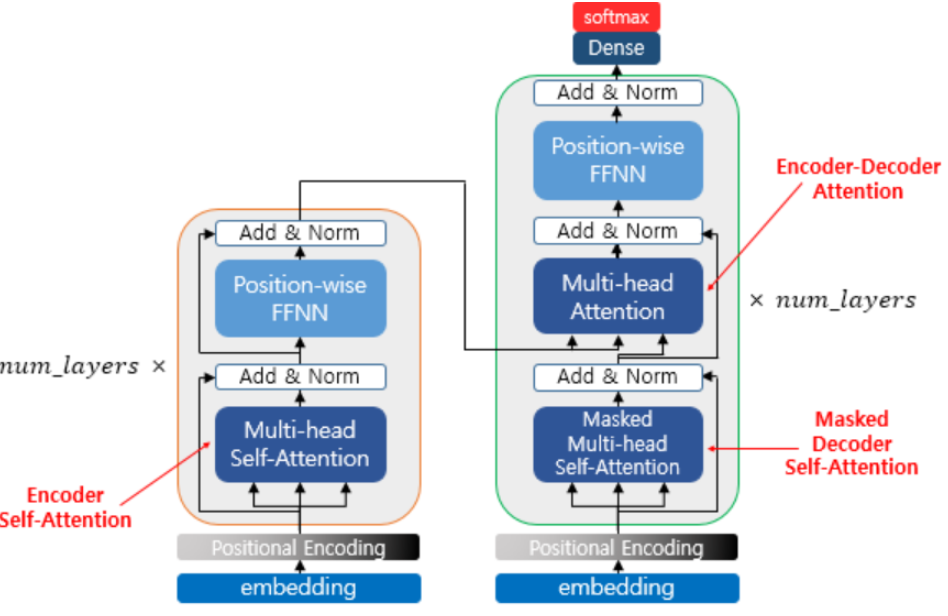

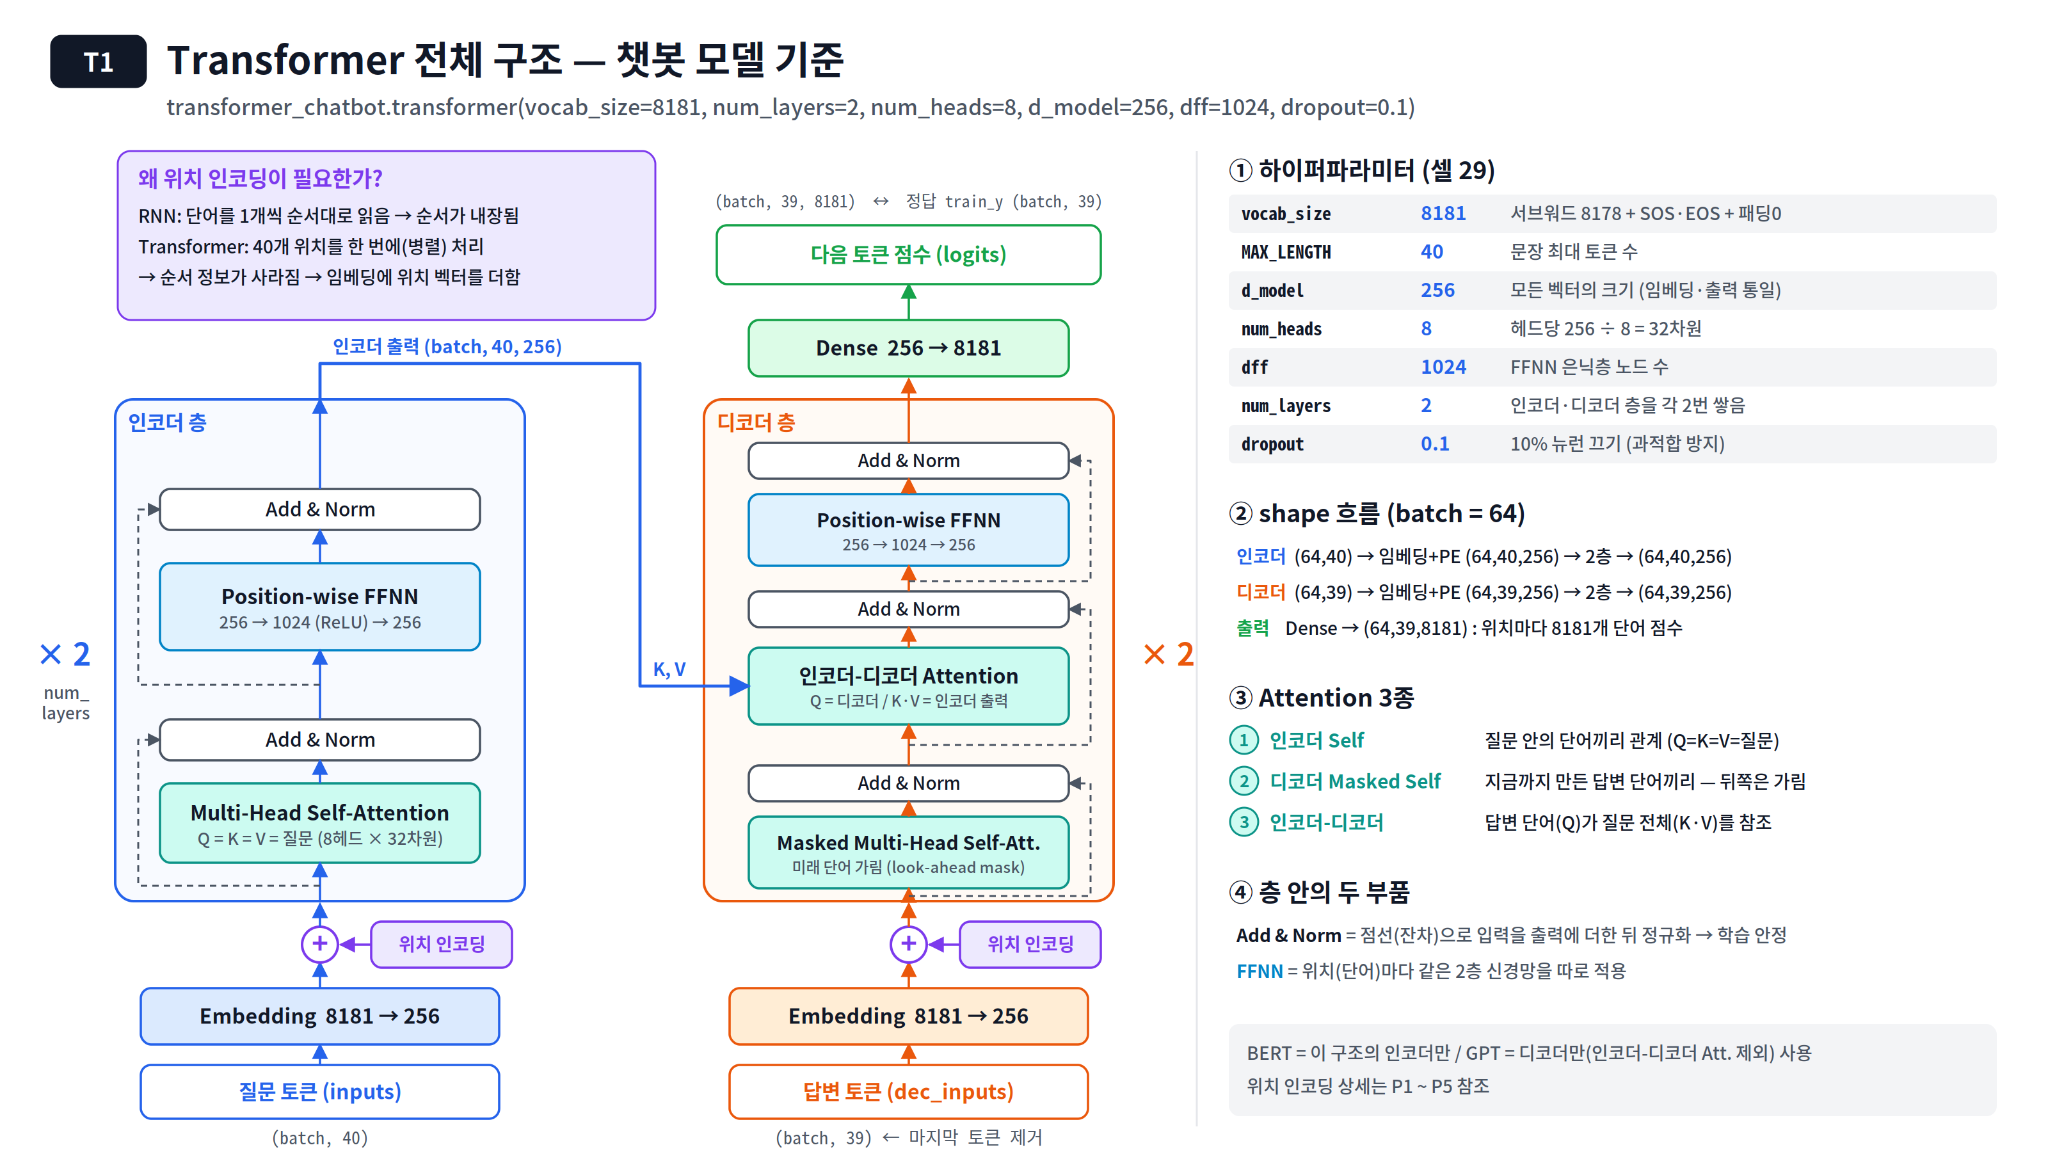

In [17]:
# Transformer 전체 구조 그림 2장 (① 수업 그림 → ② T1 챗봇 모델 기준)


# io : 파일을 디스크에 저장하지 않고 "메모리 안에서" 파일처럼 다루게 해주는 기본 도구 (webp → PNG 변환용)
import io

# IPython.display의 Image : 출력 칸에 그림을 보여주는 기능
# display : 한 셀에서 여러 개를 차례로 출력하는 함수 (그냥 쓰면 마지막 줄 결과 1개만 보여서 필요)
from IPython.display import Image, display

# PIL(Pillow)의 Image : 그림 파일을 열고 형식을 바꾸는 기능 (이름이 겹쳐서 PILImage로 부름)
from PIL import Image as PILImage

# 보여줄 그림 목록 : (파일 경로, 화면 가로 픽셀)
image_list = [
    ('images/T1_Transformer_수업구조.png', 900),       # ① 수업 그림 : 인코더·디코더 블록과 Attention 3종 위치
    ('images/T1_Transformer_전체구조_1.webp', 1100),  # ② T1 트랜스포머 전체 구조 (챗봇 모델 기준, 모양·숫자 포함)
]

# 목록에서 하나씩 꺼내 차례로 출력
for path, w in image_list:

    # path.endswith('.webp') : 파일 이름이 .webp로 끝나는지 확인 (True / False)
    #   webp는 화면에 바로 안 보일 수 있어서 PNG로 바꿔서 출력
    if path.endswith('.webp'):

        # io.BytesIO() : 메모리 안에 빈 "가짜 파일" 만들기
        buf = io.BytesIO()

        # 그림 열기 → .convert('RGB') : 색 형식을 PNG로 저장 가능한 RGB로 맞춤 → 메모리 파일에 PNG로 저장
        PILImage.open(path).convert('RGB').save(buf, format='PNG')

        # buf.getvalue() : 메모리 파일에 저장된 PNG 데이터를 꺼내서 출력
        display(Image(data=buf.getvalue(), width=w))

    # PNG 파일은 변환 없이 바로 출력
    else:
        display(Image(filename=path, width=w))


# → ① 수업 그림 : 왼쪽 주황 상자 = 인코더 블록, 오른쪽 초록 상자 = 디코더 블록, 각각 num_layers(= 2)번 반복
#        인코더 : embedding + Positional Encoding → Multi-head Self-Attention(Encoder Self-Attention) → Add & Norm → Position-wise FFNN → Add & Norm
#        디코더 : Masked Multi-head Self-Attention(Masked Decoder Self-Attention) → Add & Norm → Multi-head Attention(Encoder-Decoder Attention) → Add & Norm → FFNN → Add & Norm → Dense → softmax
#        인코더 맨 위에서 나온 선이 디코더 가운데 Attention으로 들어감 = 인코더 출력이 K·V로 전달
#        블록 옆을 돌아가는 화살표 = 잔차 연결(입력을 출력에 그대로 더해 주는 지름길)
# → 오늘 만들 챗봇 트랜스포머의 전체 구조를 한 장으로 보여주겠다
# → 왼쪽 인코더 : 질문 토큰 (batch, 40) → Embedding(8181→256) + 위치 인코딩 → [Multi-Head Self-Attention → Add & Norm → FFNN → Add & Norm] × 2층
# → 가운데 디코더 : 답변 토큰 (batch, 39) → Embedding + 위치 인코딩 → [Masked Self-Att. → 인코더-디코더 Att. → FFNN] × 2층 → Dense(256→8181)
# → 인코더 출력 (batch, 40, 256)이 디코더의 인코더-디코더 Attention에 K·V로 들어감 (Q = 디코더)
# → Attention 3종 : ① 인코더 Self(질문 안 단어끼리) ② 디코더 Masked Self(만든 답변 단어끼리, 뒤쪽은 가림) ③ 인코더-디코더(답변 Q가 질문 K·V 참조)
# → Add & Norm : 입력을 출력에 더하고(잔차 연결) 정규화 → 층을 깊게 쌓아도 학습이 안정적
# → 하이퍼파라미터 : vocab 8181, 최대 길이 40, d_model 256, 헤드 8개(헤드당 32차원), dff 1024, 층 2개, dropout 0.1
# → BERT는 이 구조의 인코더만, GPT는 디코더만(인코더-디코더 Att. 제외) 사용

In [18]:
# (최초 1회) tensorflow_datasets 설치 확인용 — 이미 설치돼 있어서 주석 처리


# %pip install tensorflow_datasets


# → 다른 컴퓨터에서 처음 실행할 때만 # 을 지우고 실행하면 되도록 남겨두겠다

In [19]:
# 트랜스포머 챗봇에 필요한 라이브러리 호출


# tensorflow_datasets : 데이터셋·텍스트 도구 모음. 여기서는 Subword 토크나이저를 쓰기 위해 불러옴
import tensorflow_datasets as tfds

# pandas : 표 형태 데이터(CSV)를 불러오고 다루는 라이브러리
import pandas as pd

# numpy : 숫자 배열 계산 라이브러리
import numpy as np

# re : 정규표현식. 문장에서 특정 패턴(문장부호 등)을 찾아 바꿀 때 사용
import re


# → 대화 데이터를 불러오고(pandas), 문장부호를 정리하고(re), 토크나이저를 만들 준비(tfds)를 하겠다
# → numpy는 앞의 Seq2Seq 파트에서도 불러왔지만, 트랜스포머 파트만 따로 실행해도 오류가 없도록 다시 불러옴

In [20]:
# 트랜스포머 모델 설계 코드(transformer_chatbot.py) 불러오기


# from data import transformer_chatbot : data 폴더 안의 transformer_chatbot.py 파일을 모듈로 불러옴
#   이 파일 안에 Positional Encoding, Multi-Head Attention, 인코더·디코더, 학습률 스케줄 등이 미리 구현돼 있음
#   (강사님은 파일을 노트북 옆에 두어서 import transformer_chatbot 으로 불러옴 → 폴더 위치에 따라 쓰는 방법이 다름)
from data import transformer_chatbot


# → 길고 복잡한 트랜스포머 구조는 별도 파일에서 가져와, 노트북에서는 데이터 준비와 학습 흐름에 집중하겠다

In [21]:
# 한국어 질문-답변 대화 데이터 불러오기
# Q : 상대 발화 (사용자의 질문) / A : 모형의 발화 (챗봇의 답변)


# pd.read_csv(경로, index_col=0) : CSV 파일을 표(DataFrame)로 불러옴
#   index_col=0 : 첫 번째 열(0, 1, 2 ... 번호)을 행 이름(인덱스)으로 사용 → 번호 열이 데이터로 중복되지 않게 함
df1 = pd.read_csv('data/09_QA_ChatBot_Data/Chat_Data.csv', index_col=0)

# .shape : (행 개수, 열 개수)
print(df1.shape)

# .head(2) : 위에서 2줄만 미리보기
df1.head(2)


# → 사용자 질문(Q), 챗봇 답변(A), 감정 라벨(label) 열로 된 한국어 대화 데이터를 불러와 크기와 모양을 확인하겠다
# → 예) Q '12시 땡!' (상대 발화) → A '하루가 또 가네요.' (모형의 발화)
# → 챗봇은 Q를 인코더에 넣고, A를 디코더가 만들어내도록 학습한다

(11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0


In [22]:
# 질문(Q) 문장 전처리 : 특수 문자(! . ? ,)를 독립된 토큰으로 분리
# 특수 문자가 등장하면 앞/뒤로 공백을 추가하여 별도의 토큰으로 인식시킴
# 예) 안녕하세요! → 안녕하세요 !


# re.sub(패턴, 바꿀내용, 문장) : 문장에서 패턴에 맞는 부분을 찾아 바꿈
#   r'...' : raw 문자열. 역슬래시(\)를 특수문자가 아닌 글자 그대로 쓰게 해줌 (정규표현식에 필수)
#   [!.?,] : 대괄호 안 글자 중 "하나" → 느낌표, 마침표, 물음표, 쉼표 중 하나와 일치
#   ( )    : 괄호로 감싸면 찾은 글자를 "기억"해둠 (그룹)
#   r' \1 ' : \1 = 1번 괄호에서 기억한 그 글자 → 앞뒤에 공백을 붙여서 다시 넣음
# [ ... for x in df1['Q'] ] : Q 열의 문장을 하나씩 꺼내(x) 바꾼 결과를 리스트로 모음 (리스트 컴프리헨션)
questions = [re.sub(r'([!.?,])', r' \1 ', x) for x in df1['Q']]

# 앞에서 10개만 확인
questions[:10]


# → 질문 문장의 특수 문자 앞뒤에 공백을 넣어, 단어와 특수 문자를 서로 다른 토큰으로 분리하겠다
# → 토크나이저는 공백 기준으로 먼저 자르므로, '땡!'이 아니라 '땡'과 '!'를 따로 인식함
# → 효과 : '안녕하세요!', '안녕하세요?', '안녕하세요'가 같은 단어 '안녕하세요'로 통일 → 단어 사전이 작고 효율적

['12시 땡 ! ',
 '1지망 학교 떨어졌어',
 '3박4일 놀러가고 싶다',
 '3박4일 정도 놀러가고 싶다',
 'PPL 심하네',
 'SD카드 망가졌어',
 'SD카드 안돼',
 'SNS 맞팔 왜 안하지ㅠㅠ',
 'SNS 시간낭비인 거 아는데 매일 하는 중',
 'SNS 시간낭비인데 자꾸 보게됨']

In [23]:
# 답변(A) 문장 전처리 : 질문과 같은 방식으로 문장부호 앞뒤에 공백 추가


# 질문과 똑같은 패턴·바꿀내용을 A 열에 적용
answers = [re.sub(r'([!.?,])', r' \1 ', x) for x in df1['A']]

# 앞에서 10개만 확인
answers[:10]


# → 챗봇 답변 문장도 문장부호를 떼어 질문과 같은 규칙으로 맞추겠다
# → 예) '하루가 또 가네요.' → '하루가 또 가네요 . '
# → 질문·답변을 같은 규칙으로 처리해야 다음 단계에서 하나의 토크나이저로 함께 학습할 수 있음

['하루가 또 가네요 . ',
 '위로해 드립니다 . ',
 '여행은 언제나 좋죠 . ',
 '여행은 언제나 좋죠 . ',
 '눈살이 찌푸려지죠 . ',
 '다시 새로 사는 게 마음 편해요 . ',
 '다시 새로 사는 게 마음 편해요 . ',
 '잘 모르고 있을 수도 있어요 . ',
 '시간을 정하고 해보세요 . ',
 '시간을 정하고 해보세요 . ']

In [24]:
# Subword 토크나이저 생성 : 질문 + 답변 전체 문장으로 단어 조각 사전을 학습


# tfds.deprecated.text.SubwordTextEncoder : 단어를 더 작은 조각(subword)으로 쪼개는 토크나이저
#   deprecated : "앞으로 없어질 예정인 기능"이라는 표시. 지금은 동작하지만 최신 버전에서는 권장하지 않음
# .build_from_corpus(문장들, target_vocab_size) : 주어진 문장 모음(corpus)을 보고 자주 나오는 조각으로 사전을 만듦
#   questions + answers : 질문 리스트와 답변 리스트를 이어 붙임 → 질문·답변 모두에 나오는 단어를 한 사전에 담음
#   target_vocab_size=2**13 : 사전 크기 목표치 2의 13제곱 = 8192개 (정확히 이 숫자가 아니라 "대략 이 정도"를 목표로 함)
tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    questions + answers,
    target_vocab_size=2**13
)

#  target_vocab_size=2**13 : 어휘 사전 크기를 8192개로 설정하겠다. 

# → 질문과 답변 전체 문장을 보고, 자주 나오는 글자 조각들로 약 8천 개짜리 단어 사전을 만들겠다
# → 질문·답변을 한 토크나이저로 만드는 이유 : 인코더 입력과 디코더 출력이 같은 번호 체계를 써야 함
# → 문장이 많아서 실행에 수십 초 ~ 몇 분 걸릴 수 있음 (셀 왼쪽 [*] 표시가 사라질 때까지 기다리기)

### 참고 : Subword 토크나이저

- **단어를 더 작은 조각(subword)으로 나눠서** 사전을 만드는 방식
- 예) `떨어졌어` → `떨어` + `졌어` 처럼 자주 쓰이는 조각 단위로 분리 (실제 분리 결과는 학습된 사전에 따라 다름)

| 방식 | 사전 단위 | 장점 | 단점 |
|---|---|---|---|
| 글자 단위 (앞의 Seq2Seq) | 글자 하나 (`가`, `나`, `a`) | 사전이 작음, 처음 보는 단어 없음 | 문장이 길어지고 단어 의미를 잡기 어려움 |
| 단어 단위 | 띄어쓰기 기준 단어 | 의미 단위가 분명 | 사전이 너무 커지고, 처음 보는 단어는 처리 못 함 |
| **Subword (이번 실습)** | 자주 쓰이는 **글자 조각** | 사전 크기 적당, 처음 보는 단어도 조각으로 표현 가능 | 조각 경계가 사람 눈엔 어색할 수 있음 |

- 한국어는 `먹다 / 먹었어 / 먹고 싶다`처럼 어미가 다양하게 변해서, 공통 조각(`먹`)을 공유하는 Subword 방식이 특히 유리함
- GPT, BERT 같은 최신 모델도 모두 Subword 계열 토크나이저를 사용

In [25]:
# 토크나이저가 만든 서브워드 사전 확인


# tokenizer.subwords : 토크나이저가 학습한 서브워드(단어 조각) 목록
# [:5] : 앞에서 5개만 확인
tokenizer.subwords[:5]


# → 만들어진 사전에 어떤 조각들이 들어갔는지 앞에서 5개만 보겠다
# → 자주 나오는 조각일수록 앞쪽 번호를 받음 (예: '이_', '을_', '거예요' 같은 조각)
# → 조각 끝의 '_' 는 "여기서 단어가 끝남(뒤에 공백)"을 뜻하는 표시

[' . ', ' ? ', '거예요', '수_', '게_']

In [26]:
# 생성된 서브워드 사전 크기(토큰 개수) 확인


# tokenizer.vocab_size : 토크나이저 사전에 들어 있는 전체 번호 개수 (0번 패딩 자리 포함)
tokenizer.vocab_size


# → 서브워드 사전 크기를 확인하겠다 → 결과 8179 (번호 0 ~ 8178 사용, 0번은 패딩용으로 비워 둠)
# → 은·는·이·가 같은 조사 조각은 문장 뜻을 이해할 때는 크게 필요 없지만, 답변을 만들어 낼(추론) 때는 있어야 자연스러운 문장이 됨 → 사전에서 빼지 않음
# → 다음 셀에서 이 값 바로 뒤 번호(8179, 8180)를 시작·끝 토큰으로 사용

8179

In [27]:
# 시작·끝 토큰과 사전 크기, 최대 길이 정의


# 사전이 0 ~ (vocab_size - 1)번까지 쓰고 있으므로, 그다음 빈 번호를 시작·끝 토큰으로 사용
# START_TOKEN : 사전 크기와 같은 번호 = 8179 (강사님 코드의 8178은 마지막 서브워드와 겹침)
START_TOKEN = [tokenizer.vocab_size]

# END_TOKEN : 그다음 번호 = 8180
END_TOKEN = [tokenizer.vocab_size + 1]

# VOCAB_SIZE : 모델이 다룰 전체 번호 개수 = 서브워드 사전 + 시작·끝 토큰 2개 = 8181
#   Embedding 층과 마지막 Dense 층의 크기로 사용됨
VOCAB_SIZE = tokenizer.vocab_size + 2

# MAX_LENGTH : 문장 최대 토큰 수 (시작·끝 토큰 포함)
MAX_LENGTH = 40

print(START_TOKEN, END_TOKEN, VOCAB_SIZE)


# → 결과 [8179] [8180] 8181 : 시작·끝 토큰이 기존 서브워드 번호와 겹치지 않게 사전 바로 뒤에 붙이겠다
# → VOCAB_SIZE 8181은 강사님 값과 같음 (시작·끝 토큰 번호만 1씩 뒤로 이동)
# → 리스트로 감싼 이유 : START_TOKEN + tokenizer.encode(문장) + END_TOKEN 처럼 이어 붙이기 위해

[8179] [8180] 8181


In [28]:
# 문장을 토큰 번호로 변환(인코딩)해 보기


# questions[5] : 전처리한 질문 중 6번째 문장 (인덱스는 0부터 시작)
print(questions[5])

# tokenizer.encode(문장) : 문장을 서브워드 조각으로 나누고, 각 조각의 번호 리스트로 바꿈
tokenizer.encode(questions[5])


# → 결과 'SD카드 망가졌어' → [8006, 7991, 2190, 918, 78, 820]
# → 단어 2개짜리 문장인데 번호가 6개 : 'SD카드', '망가졌어'가 더 작은 서브워드 조각으로 쪼개짐
# → 번호가 8000번대로 큰 조각('SD' 쪽)은 사전에서 드물게 나오는 조각, 작은 번호는 자주 나오는 조각
# → 이 번호 리스트 앞뒤에 START_TOKEN, END_TOKEN을 붙여 모델에 넣게 됨


SD카드 망가졌어


[8006, 7991, 2190, 918, 78, 820]

In [29]:
# 토큰 번호를 다시 문장으로 변환(디코딩)해 보기


# token_list : 앞 셀에서 'SD카드 망가졌어'를 인코딩한 결과 번호들
token_list = [8006, 7991, 2190, 918, 78, 820]

# tokenizer.decode(번호 리스트) : 번호를 서브워드 조각으로 바꾸고 이어 붙여 원래 문장으로 복원
tokenizer.decode(token_list)


# → 결과 'SD카드 망가졌어' : 인코딩 → 디코딩을 거쳐도 원래 문장이 그대로 복원됨
# → 토크나이저가 문장을 손실 없이 숫자로 바꾸고 되돌릴 수 있다는 확인
# → 나중에 챗봇이 예측한 번호들도 이 decode로 사람이 읽는 답변 문장으로 바꿈

'SD카드 망가졌어'

In [30]:
# 인코딩 → 디코딩 한 번에 확인 (번호를 손으로 옮겨 적지 않고 바로 연결)


# tokenizer.encode(questions[5]) : 문장 → 토큰 번호 리스트
# tokenizer.decode(...) : 토큰 번호 리스트 → 다시 문장
tokenizer.decode(tokenizer.encode(questions[5]))


# → 인코딩한 결과를 곧바로 디코딩해서 원래 문장으로 돌아오는지 확인하겠다
# → 결과 'SD카드 망가졌어' : 원래 문장과 같음 → 서브워드로 쪼개도 정보 손실 없이 복원 가능

'SD카드 망가졌어'

In [31]:
# 문장 길이를 맞춰주는 패딩 함수 불러오기


# pad_sequences : 길이가 제각각인 숫자 리스트들을 같은 길이로 맞춰 하나의 배열로 만들어줌
#   짧은 문장은 빈칸을 0으로 채우고(패딩), 긴 문장은 잘라냄
from tensorflow.keras.preprocessing.sequence import pad_sequences


# → 문장마다 토큰 개수가 달라서, 모델에 넣기 전에 모두 같은 길이로 맞출 준비를 하겠다

In [32]:
# 토큰화 + 시작·끝 토큰 + 패딩 함수
# 앞서 불러온 QA 데이터의 텍스트를 tokenizer를 이용해 숫자로 변환 → SOS / EOS 추가
# 원본 텍스트 → SOS + 토큰화 + EOS → 패딩 (문장 길이 최대 40)


def tokenize_and_filter(text):

    # text_list : 변환한 문장(숫자 리스트)을 모아둘 빈 리스트
    text_list = []

    # text에 들어온 문장들을 하나씩 꺼내 반복
    for i in text:

        # tokenizer.encode(i) : 문장을 서브워드 번호 리스트로 변환
        # START_TOKEN + ... + END_TOKEN : 리스트끼리 더하면 이어 붙여짐 → [SOS, 문장 번호들..., EOS]
        sent1 = START_TOKEN + tokenizer.encode(i) + END_TOKEN

        # 완성된 문장을 리스트에 추가
        text_list.append(sent1)

    # pad_sequences : 모든 문장을 같은 길이로 맞춰 2차원 배열로 반환
    #   maxlen=MAX_LENGTH : 최대 길이 40 (앞에서 정한 변수로 통일)
    #   padding='post' : 짧은 문장은 "뒤쪽"에 0을 채움 → [SOS, 번호들, EOS, 0, 0, ...]
    return pad_sequences(text_list, maxlen=MAX_LENGTH, padding='post')


# → 문장마다 시작(SOS)·끝(EOS) 토큰을 붙이고, 길이를 40으로 맞춘 숫자 배열을 만들어 돌려주는 함수를 정의하겠다
# → 예) 'SD카드 망가졌어' → [8179, 8006, 7991, 2190, 918, 78, 820, 8180, 0, 0, ..., 0] (총 40칸)

### 참고 : tokenize_and_filter 동작과 주의점

| 단계 | 결과 예시 ('SD카드 망가졌어') |
|---|---|
| 1. encode | `[8006, 7991, 2190, 918, 78, 820]` |
| 2. 시작·끝 토큰 추가 | `[8179, 8006, 7991, 2190, 918, 78, 820, 8180]` |
| 3. 패딩 (post, 40칸) | `[8179, 8006, ..., 820, 8180, 0, 0, ..., 0]` |

- **padding='post'** : 0을 뒤에 채움 → 문장이 항상 시작 토큰으로 시작해서 디코더 학습에 자연스러움
- **주의 : 40칸보다 긴 문장은 잘림**
    - `pad_sequences`는 기본값이 `truncating='pre'` → 긴 문장은 **앞쪽**을 자름 → **시작 토큰이 잘려나갈 수 있음**
    - 함수 이름은 `filter`지만 실제로 긴 문장을 **걸러내지는 않음**
    - 원래 튜토리얼 방식은 40칸이 넘는 문장을 아예 **학습 데이터에서 제외(filter)** 하는 것
- 0번은 패딩 전용 번호라서, 뒤에서 모델이 **마스크로 무시**하도록 처리함

In [33]:
# 질문·답변 전체 문장을 숫자 배열로 변환


# tokenize_and_filter(questions) : 질문 문장 전체 → [SOS + 토큰 + EOS + 패딩] 배열 (인코더 입력용)
questions_out = tokenize_and_filter(questions)

# tokenize_and_filter(answers) : 답변 문장 전체 → 같은 방식의 배열 (디코더 입력·정답용)
answers_out = tokenize_and_filter(answers)


# → 모든 질문과 답변을 길이 40의 숫자 배열로 한꺼번에 바꾸겠다
# → questions_out은 인코더에, answers_out은 디코더 입력과 정답을 만드는 데 사용

In [34]:
# 질문 변환 결과 확인


# questions_out : (문장 수, 40) 모양의 2차원 정수 배열
#   각 줄 = 문장 하나 / 맨 앞 = SOS, 문장 토큰들, EOS, 나머지 = 0(패딩)
questions_out


# → 모든 줄이 시작 토큰으로 시작하고, 뒤쪽은 0으로 채워진 것을 확인하겠다
# → 강사님 결과는 맨 앞이 8178 (강사님 START_TOKEN), 내 결과는 8179 (vocab_size로 계산한 START_TOKEN)
# → dtype=int32 : 32비트 정수 배열 → 모델 입력에 그대로 사용 가능

array([[8179, 7917, 4208, ...,    0,    0,    0],
       [8179, 7972,   47, ...,    0,    0,    0],
       [8179, 7974, 1434, ...,    0,    0,    0],
       ...,
       [8179, 8160, 8080, ...,    0,    0,    0],
       [8179,  134,  166, ...,    0,    0,    0],
       [8179, 1952,  883, ...,    0,    0,    0]],
      shape=(11823, 40), dtype=int32)

In [35]:
# 학습 데이터 구성 : 인코더 입력, 디코더 입력, 디코더 정답


# train_x : 모델에 넣을 입력 2개를 딕셔너리로 묶음
#   딕셔너리 키 이름('inputs', 'dec_inputs')은 transformer_chatbot.py에서 만든 입력층 이름과 똑같아야 함
train_x = {

    # 'inputs' : 인코더 입력 = 질문 시퀀스 전체 (<SOS> + 질문 + <EOS> + 패딩), 40칸
    #   .astype(np.int32) : 32비트 정수형으로 변환 (Embedding 층은 정수 번호를 입력으로 받음)
    'inputs': questions_out.astype(np.int32),

    # 'dec_inputs' : 디코더 입력 = 응답 시퀀스에서 "마지막 칸만 뺀 것", 39칸
    #   [:, :-1] : 모든 문장(:)에서 처음부터 마지막 하나 전까지(:-1)
    #   디코더는 이전 시점까지의 토큰을 보고 다음 토큰을 예측하므로 → 맨 끝 토큰은 "다음"이 없어 입력으로 쓸 일이 없음
    'dec_inputs': answers_out[:, :-1].astype(np.int32)
}

# train_y : 디코더가 맞혀야 할 정답 = 응답 시퀀스에서 "첫 칸(<SOS>)만 뺀 것", 39칸
#   [:, 1:] : 모든 문장(:)에서 두 번째 칸부터 끝까지(1:)
#   <SOS>는 "이제 답변 시작" 신호일 뿐 모델이 맞혀야 할 단어가 아니므로 정답에서 제외
train_y = answers_out[:, 1:].astype(np.int32)


# → 인코더에는 질문 전체를, 디코더 입력에는 응답의 마지막 칸을 뺀 것을, 정답에는 첫 칸(<SOS>)을 뺀 것을 넣겠다
# → 입력은 뒤에서, 정답은 앞에서 한 칸씩 빠지는 이유 : 둘 다 39칸이 되고, 같은 자리끼리 "지금 토큰 → 다음 토큰" 짝이 됨
#    입력 [<SOS>, 하루, 가, 또, 가네요, ., <EOS>, 0, ...]
#    정답 [하루,  가,  또, 가네요, .,  <EOS>, 0,  0, ...]
#    → 입력 <SOS>를 보면 정답 '하루', '하루'를 보면 '가', ... '.'을 보면 <EOS> → 문장 끝을 스스로 알게 됨
# → 짧은 문장은 실제로 빠지는 마지막 칸이 패딩(0)이고 <EOS>는 입력에 남음 → 그 자리의 정답은 0(패딩)이라 loss_function의 마스크로 무시됨
# → 추론(evaluate) 때도 디코더를 <SOS>로 시작하고 <EOS>가 나오면 멈추는 이유가 바로 이 짝 맞추기 때문 (Teacher Forcing, 아래 참고 마크다운)

In [36]:
# 학습 데이터 모양 확인


# .shape : (문장 수, 칸 수)
print(f"인코더 입력 (questions)  : {train_x['inputs'].shape}")      # (문장 수, 40)
print(f"디코더 입력 (answers-1)  : {train_x['dec_inputs'].shape}")  # (문장 수, 39)
print(f"디코더 정답 (answers+1)  : {train_y.shape}")                # (문장 수, 39)
print(f"총 학습 샘플 수 : {len(train_y)}")


# → 인코더는 40칸, 디코더 입력과 정답은 39칸으로 짝이 맞는지 확인하겠다

인코더 입력 (questions)  : (11823, 40)
디코더 입력 (answers-1)  : (11823, 39)
디코더 정답 (answers+1)  : (11823, 39)
총 학습 샘플 수 : 11823


### 참고 : 디코더 입력과 정답을 한 칸 어긋나게 만드는 이유 (Teacher Forcing)

답변 '하루가 또 가네요 .' 예시 (토큰은 단순화)

| 위치 | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| `answers_out` (원본) | SOS | 하루가 | 또 | 가네요 | . | EOS |
| `dec_inputs` = `[:, :-1]` (입력) | SOS | 하루가 | 또 | 가네요 | . | |
| `train_y` = `[:, 1:]` (정답) | 하루가 | 또 | 가네요 | . | EOS | |

- 디코더는 **같은 위치**에서 입력을 보고 정답을 맞힘 → "SOS를 보면 '하루가'", "'하루가'를 보면 '또'" …
- 즉, **지금까지의 글자를 보고 다음 글자를 예측**하도록 학습
- 앞의 Seq2Seq 실습에서 `decoder_input_data`와 `decoder_target_data`가 한 칸 어긋나 있던 것과 같은 원리
- 트랜스포머는 이 39칸을 **한꺼번에** 처리하므로, Masked Self Attention으로 **뒤쪽 정답 글자를 미리 못 보게** 가림

# 포지션 인코딩 (Position Encoding)

- Transformer 모형에서 Sequence 데이터에 대해 **데이터의 순서 정보를 처리하는 입력층**
- RNN 계열 모형을 사용하는 Seq2Seq / Attention 생성 모형은 데이터를 순차적으로 받아 처리하기 때문에, 문장 내 단어의 순서가 **처리된 정보로써 존재**
- Transformer 모형은 데이터를 전체적으로 **한 번에 병렬로 처리**하기 때문에, Sequence에 대한 **각 토큰의 순차 정보를 가지고 있을 필요**
- **Sin / Cos 함수**를 활용해서 단어의 순서 정보를 Vector로 변환해 기존 단어 정보와 함께 Encoder와 Decoder에 전달

---

### 보충 : 왜 순서 정보가 필요한가

- "나는 너를 좋아해" vs "너는 나를 좋아해" → 사용하는 단어는 거의 같지만 **순서가 다르면 뜻이 완전히 달라짐**
- 순서 정보 없이 Self Attention만 쓰면, 두 문장을 **같은 단어 묶음**으로 보게 됨

### 보충 : 계산 방법 (sin · cos 함수)

- 위치 `pos`(몇 번째 단어), 차원 번호 `i`, 벡터 크기 `d_model`(이번 실습 256)일 때
    - **짝수 차원** : PE(pos, 2i) = sin( pos / 10000^(2i / d_model) )
    - **홀수 차원** : PE(pos, 2i+1) = cos( pos / 10000^(2i / d_model) )
- 결과 : 위치마다 **서로 다른 256차원 벡터**가 만들어짐 → 이걸 단어 임베딩에 **더함** ("기존 단어 정보와 함께" 전달)

| 성질 | 의미 |
|---|---|
| 값 범위가 -1 ~ 1 | 임베딩 값을 크게 흔들지 않고 위치 정보만 살짝 얹음 |
| 위치마다 패턴이 다름 | 모델이 "몇 번째 단어인지" 구별 가능 |
| 차원마다 주기가 다름 | 앞쪽 차원은 빠르게, 뒤쪽 차원은 천천히 변함 → 가까운 위치·먼 위치 관계를 모두 표현 |
| 학습 없이 계산 | 수식으로 미리 계산해 두는 고정값 (학습되는 가중치가 아님) |

### 보충 : 모델 안에서의 위치

**토큰 번호** → Embedding (8181 → 256) → **＋ Position Encoding** → Encoder / Decoder

- T1 그림에서 Embedding 위의 **⊕ 위치 인코딩** 부분
- 인코더 입력 (batch, 40, 256), 디코더 입력 (batch, 39, 256)에 각각 더해짐

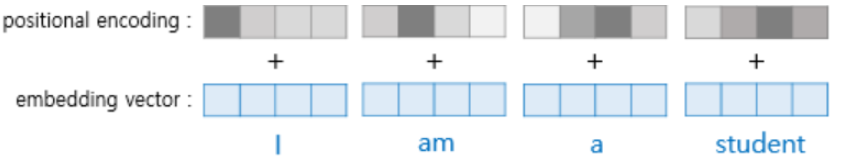

In [37]:
# 위치 인코딩 개념 그림 (T2 : 단어 임베딩 벡터 + 위치 인코딩 벡터)


# IPython.display의 Image : 출력 칸에 그림을 보여주는 기능
from IPython.display import Image

# Image(filename=경로, width=가로 픽셀) : PNG 그림을 바로 출력
Image(filename='images/T2_PositionalEncoding_Embedding_Add.png', width=900)


# → 위치 인코딩이 단어 벡터에 "더해지는" 모습을 한 장으로 보여주겠다
# → 아래 파란 칸 = 단어의 의미를 담은 임베딩 벡터 (I, am, a, student 각각)
# → 위 회색 칸 = 위치마다 다른 무늬의 위치 인코딩 벡터 (진하기가 다름 = 값이 다름)
# → 같은 크기끼리 칸마다 더함(+) → "단어 의미 + 몇 번째인지"가 함께 담긴 벡터가 인코더·디코더로 들어감
# → 그림은 4차원이지만 이번 실습은 256차원 : Embedding (batch, 40, 256) + 위치 인코딩 (1, 40, 256)

In [38]:
# Keras와 Keras 연산 도구 불러오기


# keras : 딥러닝 모델·층을 만드는 라이브러리 (Keras 3)
import keras

# keras.ops : 텐서 연산 도구 모음 (shape, 더하기, 변환 등)
#   백엔드(TensorFlow, PyTorch, JAX)가 바뀌어도 같은 코드로 동작하게 해줌
import keras.ops as ops


# → 직접 층(Layer)을 만들 준비를 하겠다

In [39]:
# Position Encoding 층 직접 만들기 (sin · cos로 위치 정보 벡터를 계산해 임베딩에 더하는 층)


# keras.layers.Layer를 상속 → Keras의 다른 층(Dense, LSTM 등)처럼 모델 안에서 쓸 수 있는 층이 됨
class PositionalEncoding(keras.layers.Layer):

    # ===== Init =====

    # __init__ : 층을 만들 때 한 번 실행되는 준비 함수
    #   position : 최대 위치 개수 (문장 최대 길이, 예: 40)
    #   d_model  : 벡터 크기 (임베딩 차원, 예: 256)
    #   **kwargs : 층 이름 등 부모 클래스에 넘길 추가 옵션
    def __init__(self, position, d_model, **kwargs):

        # super().__init__ : 부모 클래스(keras.layers.Layer)의 준비 과정을 먼저 실행
        super(PositionalEncoding, self).__init__(**kwargs)

        # 받은 값을 층 안에 저장해 둠
        self.position = position
        self.d_model_size = d_model

        # 포지션 인코딩 표를 층을 만들 때 "한 번만" 미리 계산해 저장 (학습되는 값이 아니라 고정값)
        self.pos_encoding = self._compute_positional_encoding(position, d_model)


    # ===== Position Encoding 계산 =====

    def _compute_positional_encoding(self, position, d_model):

        # positions : 위치 번호 0, 1, 2, ..., position-1 을 세로(열 벡터)로 세움 → 모양 (position, 1)
        #   [:, np.newaxis] : 뒤에 축을 하나 추가해 세로로 세움
        positions = np.arange(position, dtype=np.float32)[:, np.newaxis]

        # dims : 차원 번호 0, 1, 2, ..., d_model-1 을 가로(행 벡터)로 눕힘 → 모양 (1, d_model)
        dims = np.arange(d_model, dtype=np.float32)[np.newaxis, :]

        # angles : 위치 / 10000^(2i / d_model) → sin·cos에 넣을 각도 표, 모양 (position, d_model)
        #   dims // 2 : 차원 번호를 2로 나눈 몫 → 짝수·홀수 차원이 같은 i를 공유 (0,1 → 0 / 2,3 → 1 ...)
        #   (세로 벡터) / (가로 벡터) → 브로드캐스팅으로 (위치 × 차원) 표 전체가 한 번에 계산됨
        angles = positions / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))

        # 짝수 차원(0, 2, 4, ...)에는 sin 적용
        #   0::2 : 0번부터 2칸씩 건너뛰며 선택
        angles[:, 0::2] = np.sin(angles[:, 0::2])

        # 홀수 차원(1, 3, 5, ...)에는 cos 적용
        #   1::2 : 1번부터 2칸씩 건너뛰며 선택
        angles[:, 1::2] = np.cos(angles[:, 1::2])

        # 맨 앞에 배치 축을 추가 → 모양 (1, position, d_model)
        #   어떤 배치 크기의 입력이 와도 브로드캐스팅으로 더해질 수 있게 함
        return angles[np.newaxis, ...].astype(np.float32)


    # ===== Output Shape =====

    # compute_output_shape : 이 층의 출력 모양을 Keras에게 알려줌
    #   위치 정보를 "더하기"만 하므로 입력 모양 그대로 나옴
    def compute_output_shape(self, input_shape):
        return input_shape


    # ===== Call =====

    # call : 층에 데이터가 들어올 때마다 실행되는 실제 계산
    def call(self, inputs):

        # seq_len : 이번에 들어온 입력의 문장 길이 (인코더 40, 디코더 39처럼 다를 수 있음)
        #   ops.shape(inputs)[1] : (배치, 길이, 차원) 중 두 번째 값
        seq_len = ops.shape(inputs)[1]

        # 미리 계산한 표에서 문장 길이만큼만 잘라(:seq_len) 텐서로 바꾼 뒤 입력(임베딩)에 더함
        return inputs + ops.convert_to_tensor(self.pos_encoding[:, :seq_len, :])


# → sin·cos로 위치 정보 표를 한 번 계산해 두고, 입력(임베딩)이 들어오면 길이만큼 잘라 더해주는 층을 만들겠다
# → 결과 : 임베딩 벡터 + 위치 벡터 = 순서 정보가 담긴 입력 (T2 그림의 "+" 부분)
# → 계산식 : 짝수 차원 sin(pos / 10000^(2i/d_model)), 홀수 차원 cos(pos / 10000^(2i/d_model))

### 참고 : PositionalEncoding 클래스 구조

| 메서드 | 언제 실행 | 하는 일 |
|---|---|---|
| `__init__` | 층을 만들 때 1번 | 위치·차원 저장, 포지션 인코딩 표를 미리 계산 |
| `_compute_positional_encoding` | `__init__` 안에서 1번 | sin·cos로 (1, position, d_model) 표 생성 |
| `compute_output_shape` | 모델을 조립할 때 | 출력 모양 = 입력 모양이라고 알려줌 |
| `call` | 데이터가 들어올 때마다 | 문장 길이만큼 잘라 입력에 더함 |

- **브로드캐스팅** : 모양이 다른 배열끼리 계산할 때, 크기 1인 축을 자동으로 늘려 맞춰주는 넘파이·텐서 기능
    - (40, 1) / (1, 256) → (40, 256) 표 / (1, 40, 256) + (64, 40, 256) → (64, 40, 256)
- **표를 미리 계산하는 이유** : 위치 정보는 학습으로 바뀌지 않는 고정값이라, 매번 다시 계산할 필요가 없음
- 이 노트북의 클래스는 **원리 이해용** → 실제 모델은 `transformer_chatbot.py` 안의 같은 클래스를 사용

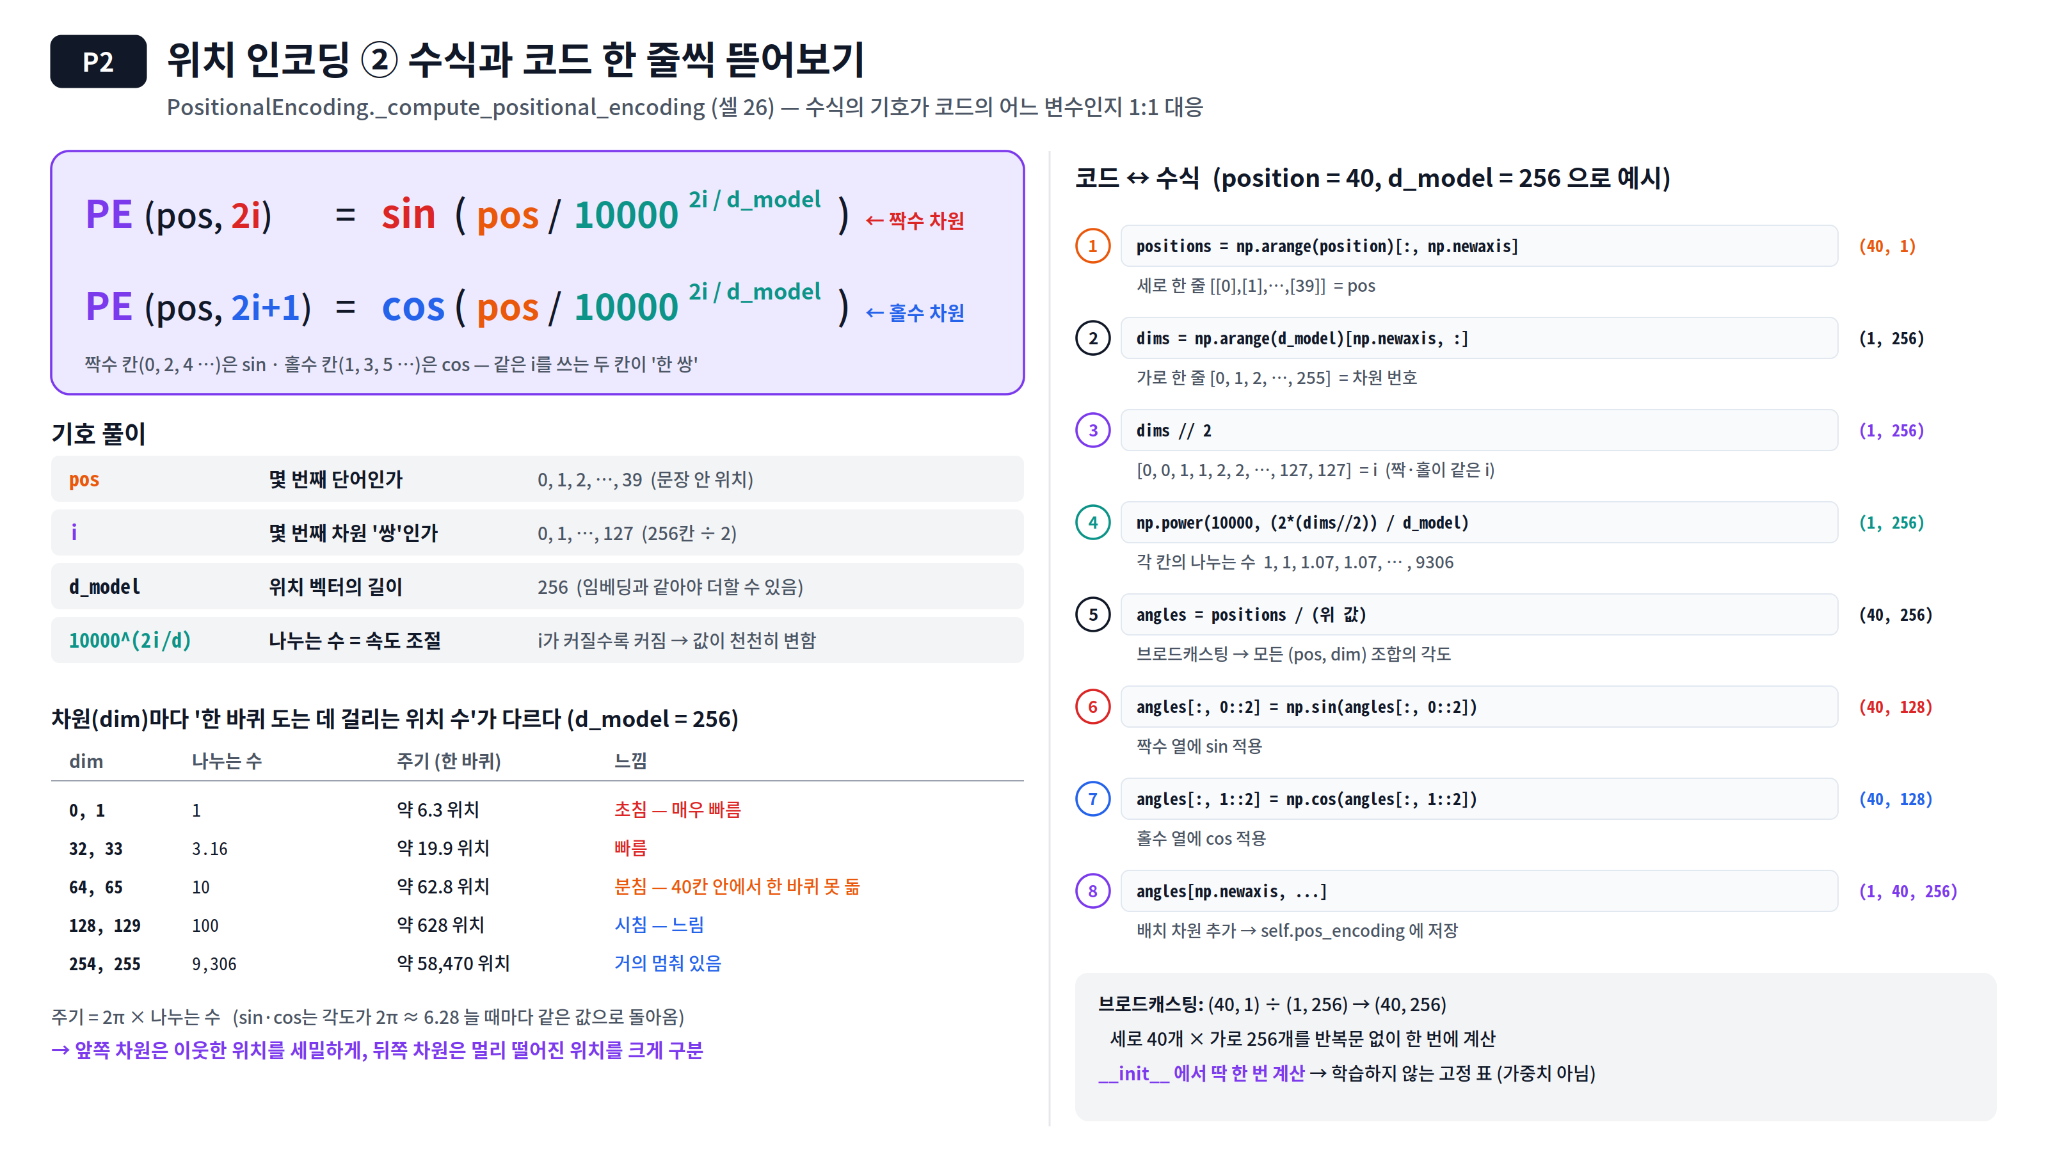

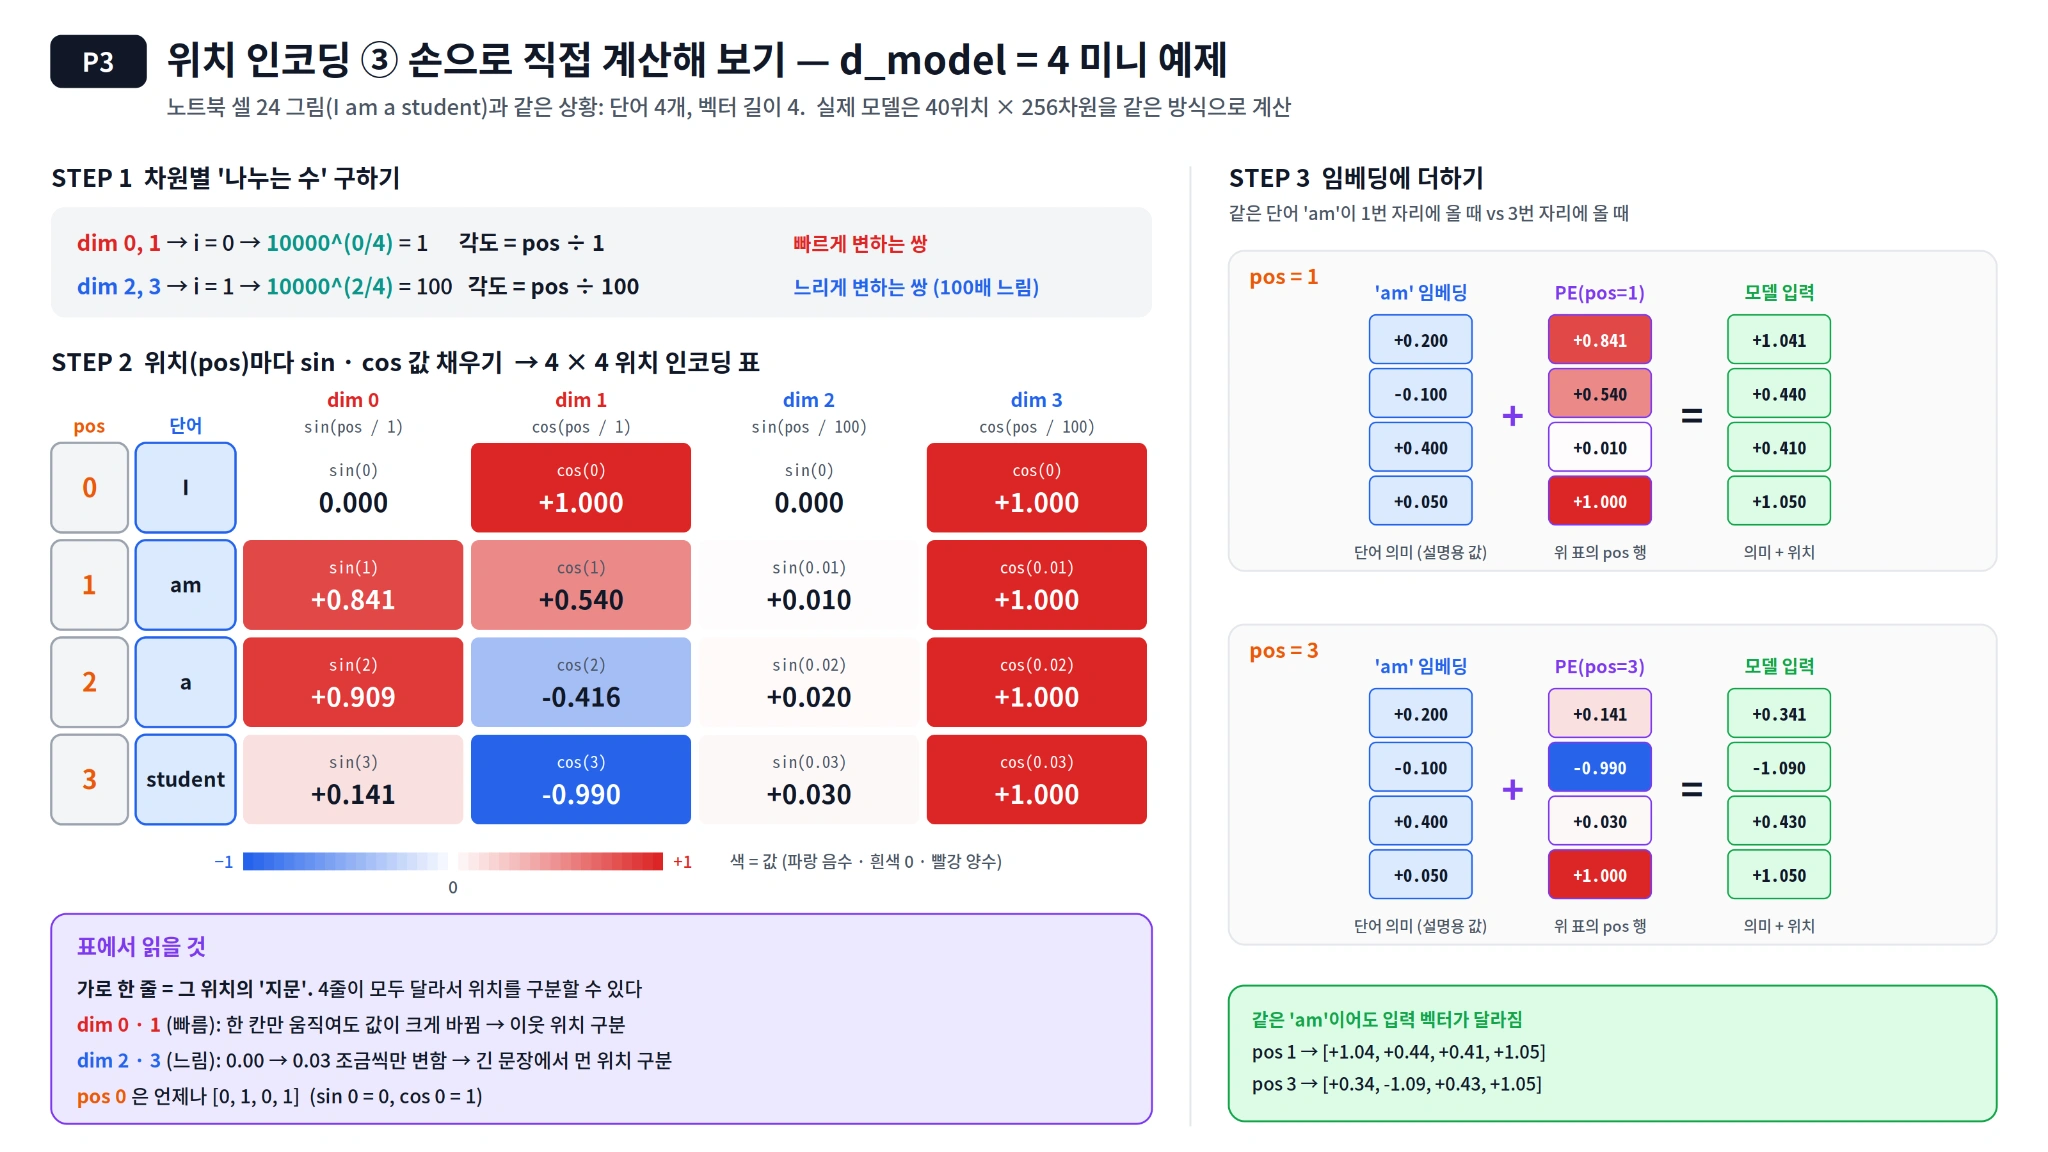

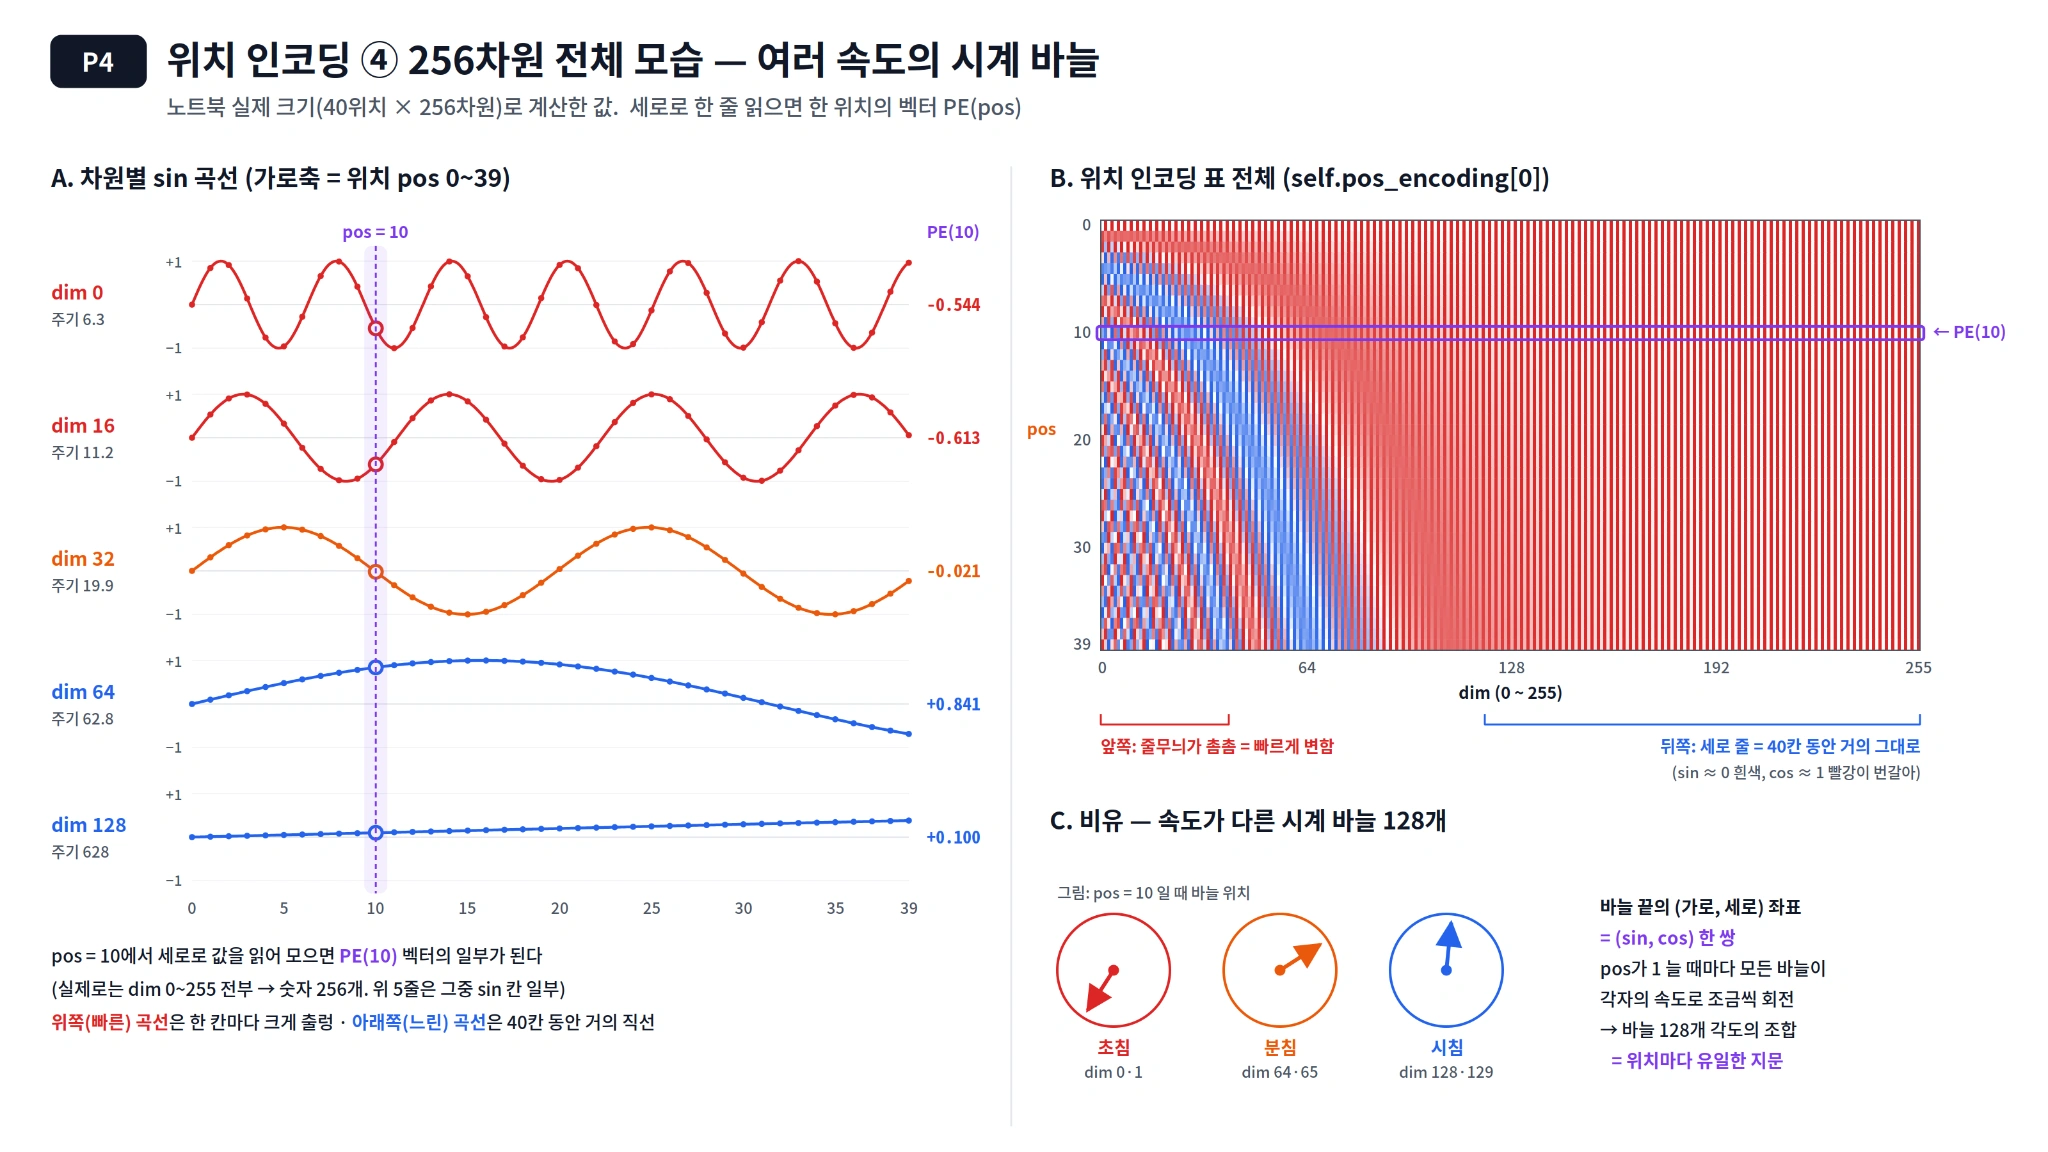

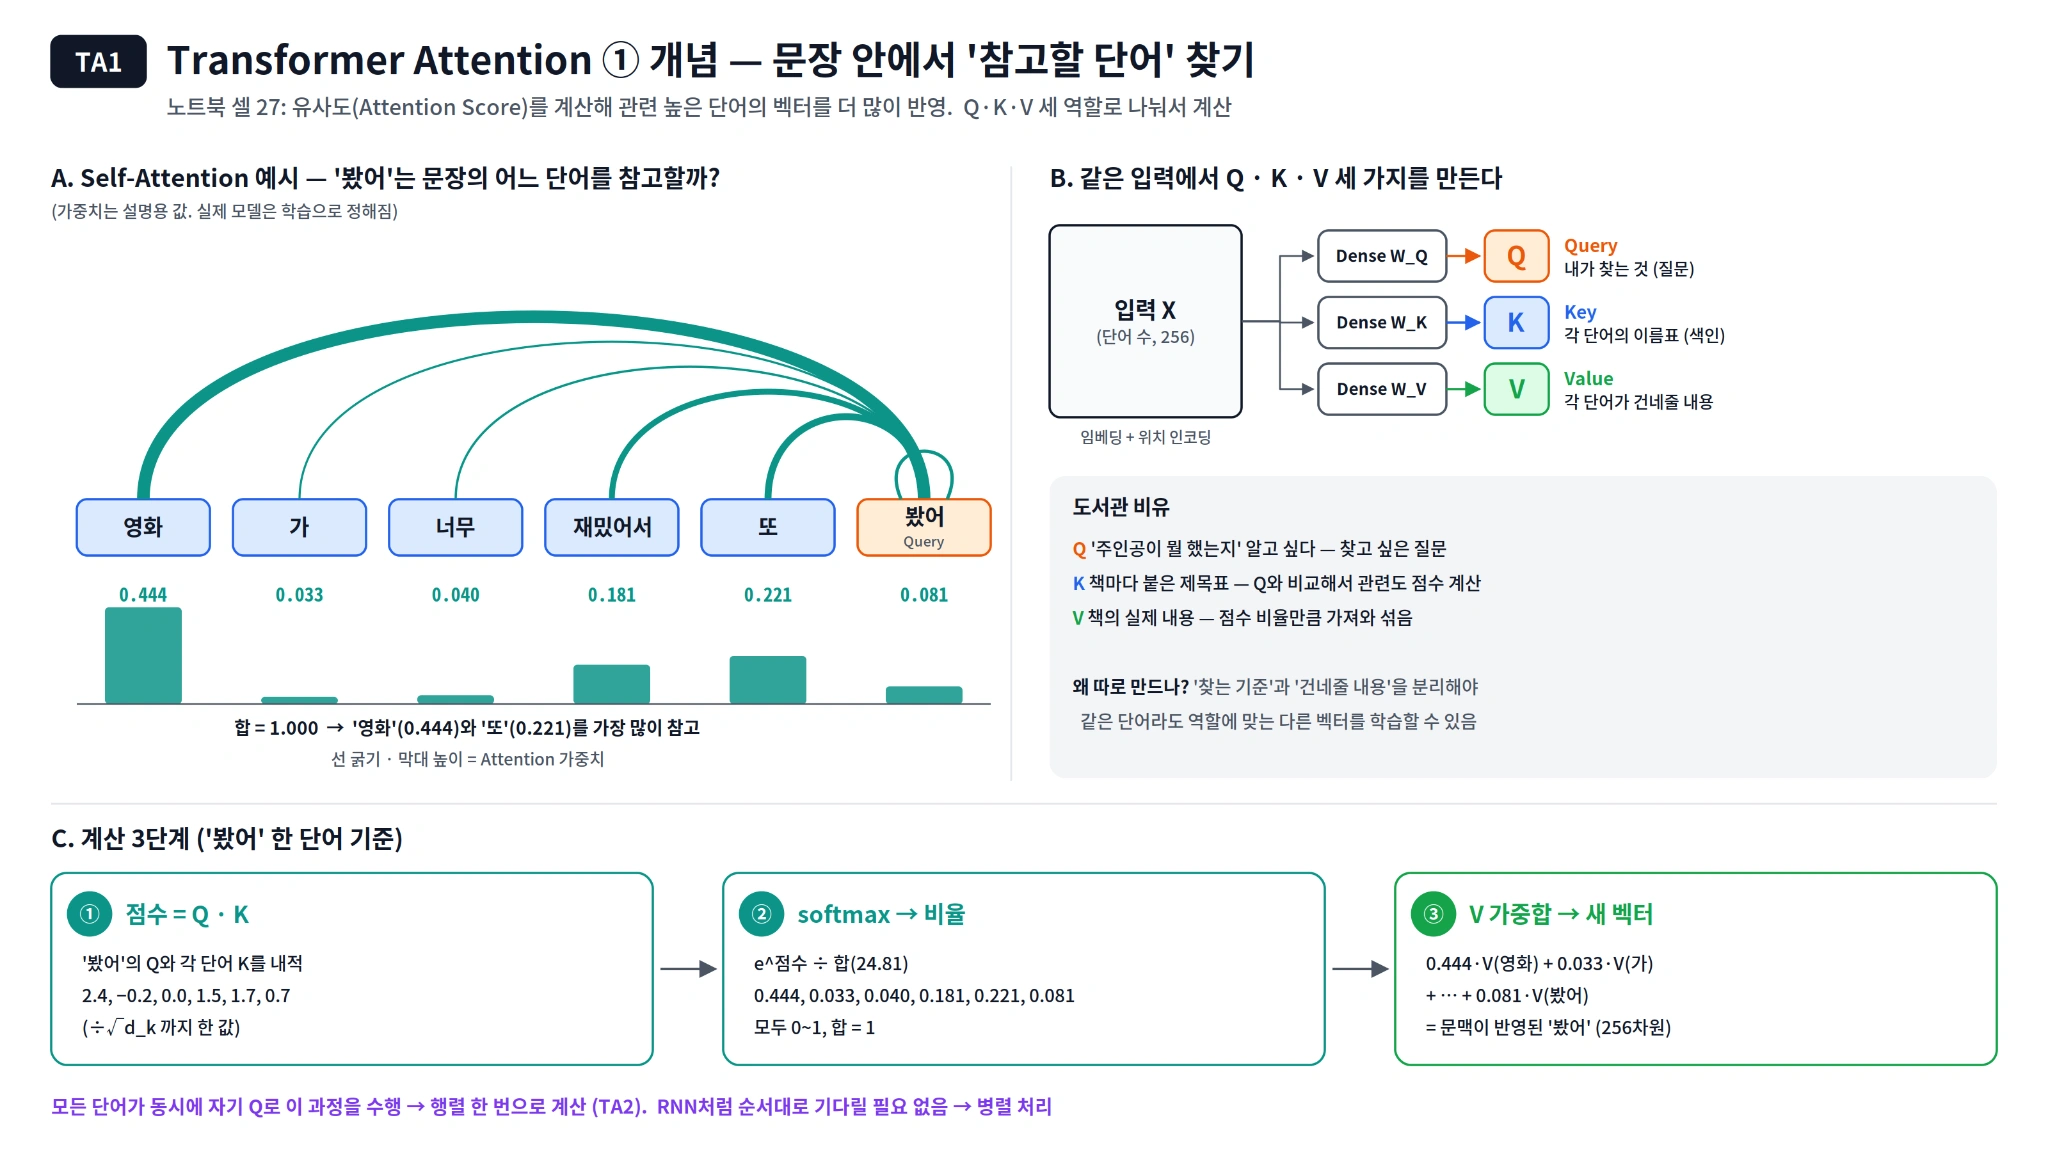

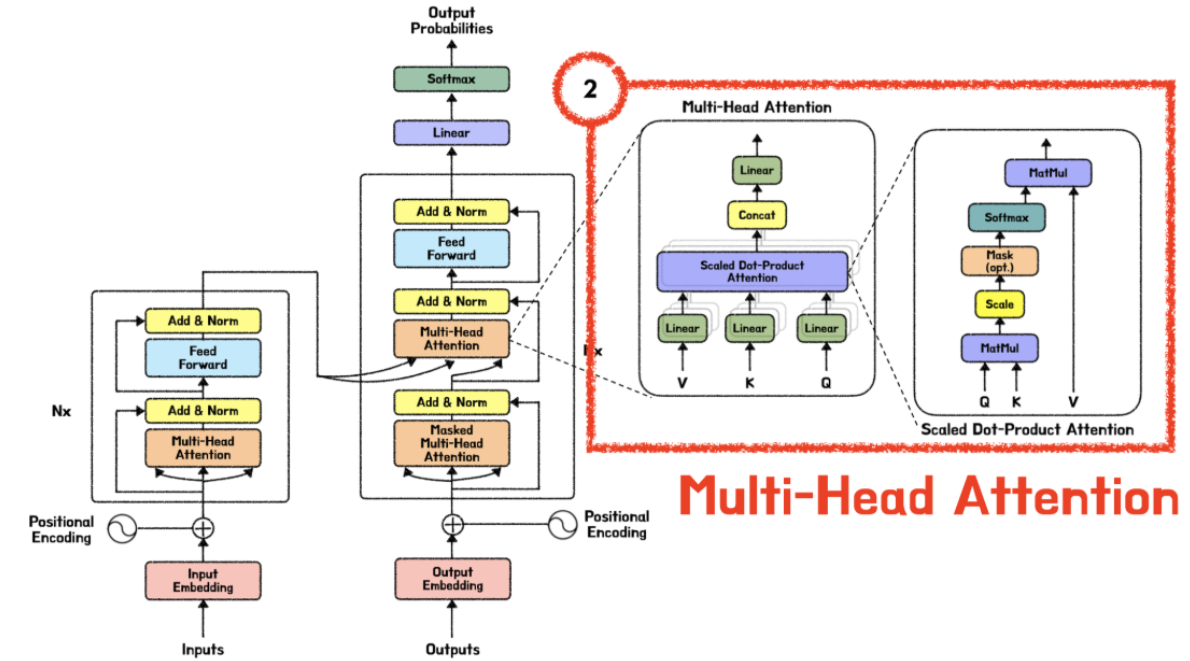

In [40]:
# 위치 인코딩 그림 3장 + Attention 그림 2장 (P2 수식과 코드 → P3 손계산 예제 → P4 256차원 전체 모습 → TA1 Q·K·V 개념 → TA1 수업 그림 Multi-Head Attention)


# io : 파일을 디스크에 저장하지 않고 "메모리 안에서" 파일처럼 다루게 해주는 기본 도구 (webp → PNG 변환용)
import io

# IPython.display의 Image : 출력 칸에 그림을 보여주는 기능
# display : 한 셀에서 여러 개를 차례로 출력하는 함수 (그냥 쓰면 마지막 줄 결과 1개만 보여서 필요)
from IPython.display import Image, display

# PIL(Pillow)의 Image : 그림 파일을 열고 형식을 바꾸는 기능 (이름이 겹쳐서 PILImage로 부름)
from PIL import Image as PILImage

# 보여줄 그림 목록 : (파일 경로, 화면 가로 픽셀)
image_list = [
    ('images/P2_PositionalEncoding_Formula_Code.png', 1100),     # P2 수식 기호 ↔ 코드 변수 1:1 대응
    ('images/P3_PositionalEncoding_Hand_Calc.png', 1100),        # P3 d_model = 4 미니 예제 손계산
    ('images/P4_PositionalEncoding_256dim_Overview.png', 1100),  # P4 40위치 × 256차원 전체 모습
    ('images/TA1_Attention_개념_QKV_1.webp', 1100),              # TA1 Self-Attention 예시 + Q·K·V + 계산 3단계
    ('images/TA1_MultiHeadAttention_수업구조.png', 1100),         # TA1 수업 그림 : 논문 전체 구조 + Multi-Head / Scaled Dot-Product 확대
]

# 목록에서 하나씩 꺼내 차례로 출력
for path, w in image_list:

    # path.endswith('.webp') : 파일 이름이 .webp로 끝나는지 확인 (True / False)
    #   webp는 화면에 바로 안 보일 수 있어서 PNG로 바꿔서 출력
    if path.endswith('.webp'):

        # io.BytesIO() : 메모리 안에 빈 "가짜 파일" 만들기
        buf = io.BytesIO()

        # 그림 열기 → .convert('RGB') : 색 형식을 PNG로 저장 가능한 RGB로 맞춤 → 메모리 파일에 PNG로 저장
        PILImage.open(path).convert('RGB').save(buf, format='PNG')

        # buf.getvalue() : 메모리 파일에 저장된 PNG 데이터를 꺼내서 출력
        display(Image(data=buf.getvalue(), width=w))

    # PNG 파일은 변환 없이 바로 출력
    else:
        display(Image(filename=path, width=w))


# → 위치 인코딩을 "수식 → 손계산 → 실제 크기" 순서로 세 장에 걸쳐 보여주고, 이어서 Attention 개념 그림을 보여주겠다
# → P2 : PE(pos, 2i) = sin(pos / 10000^(2i/d_model)), PE(pos, 2i+1) = cos(...)의 기호가 코드 어느 변수인지 대응
#        positions (40, 1) → dims (1, 256) → dims//2 = i → 나누는 수 → angles (40, 256) → sin·cos → (1, 40, 256)
# → P3 : 'I am a student' (4단어 × 4차원)로 표를 직접 계산 → 가로 한 줄 = 그 위치의 '지문'
#        같은 'am'도 1번 자리 [1.04, 0.44, 0.41, 1.05] vs 3번 자리 [0.34, -1.09, 0.43, 1.05] → 위치에 따라 입력이 달라짐
# → P4 : 실제 크기(40위치 × 256차원) 표를 그림으로 보면
#        앞쪽 차원(dim 0 쪽) = 줄무늬가 촘촘 = 빠르게 변함 / 뒤쪽 차원 = 40칸 동안 거의 그대로
#        pos 10에서 세로로 읽으면 PE(10) 벡터 (dim 0 : -0.544, dim 64 : +0.841, dim 128 : +0.100 ...)
# → 비유 : 속도가 다른 시계 바늘 128개(초침·분침·시침…)의 각도 조합 = 위치마다 유일한 지문
# → TA1 : '영화 가 너무 재밌어서 또 봤어'에서 '봤어'(Query)가 각 단어를 참고하는 비율
#        영화 0.444, 또 0.221, 재밌어서 0.181 ... 합 = 1 → '무엇을 봤는지(영화)'와 '또'를 가장 많이 참고
#        같은 입력 X (단어 수, 256)를 Dense 3개(W_Q, W_K, W_V)에 통과 → Q = 찾는 것 / K = 이름표 / V = 건네줄 내용
#        ① 점수 = Q·K ÷ √d_k (2.4, -0.2, 0.0, 1.5, 1.7, 0.7) → ② softmax (e^점수 ÷ 24.81) → ③ V 가중합 = 문맥이 반영된 새 벡터
#        모든 단어가 동시에 이 과정을 수행 → 행렬 곱 한 번으로 병렬 처리 (RNN처럼 순서대로 기다릴 필요 없음)
# → TA1 수업 그림 : 왼쪽 = 논문 원본 구조 (Nx = 층 반복, 이번 실습 2층), 오른쪽 빨간 상자 = 디코더의 Multi-Head Attention 확대
#        Multi-Head Attention : V·K·Q → Linear(W_V, W_K, W_Q) → Scaled Dot-Product Attention 여러 겹(헤드 8개) → Concat(이어 붙이기) → Linear(W_O)
#        Scaled Dot-Product Attention : MatMul(Q·Kᵀ) → Scale(÷√d_k) → Mask(선택) → Softmax → MatMul(× V)
#        파일 코드와 1:1 대응 : query_dense·key_dense·value_dense → split_heads → scaled_dot_product_attention → reshape(concat) → dense

# Transformer Attention

- transformer_chatbot.py
- Attention Mechanism : 특정 Layer층에서 출력되는 매 시점마다 Encoder에서 처리된 정보(전체 문장)를 다시 참조하여 출력을 수행하는 학습 형태
- 유사도를 계산하여 (Attention Score), 가장 유사도가 높은 문장의 Vector를 찾고, 해당 값을 다음 Layer에 반영하는 형태
    - Multi Head Attention : 인코더와 디코더의 Attention을 병렬로 배치하여 처리하는 영역
    - Encoder Self Attention (Decoder Self Attention) : 모델이 하나의 Sequence 내에서 단어들 사이의 관계를 파악
    - Encoder-Decoder Attention : 모델이 인코더의 출력과 디코더의 입력 사이 관계를 파악

---

### 보충 : Q · K · V 세 가지 역할 (TA1 그림)

| 이름 | 뜻 | 도서관 비유 |
|---|---|---|
| **Q** (Query) | 지금 단어가 "찾고 싶은 것" | '주인공이 뭘 했는지' 알고 싶다는 질문 |
| **K** (Key) | 각 단어의 "이름표" → Q와 비교해 관련도 점수 계산 | 책마다 붙은 제목표 |
| **V** (Value) | 각 단어가 "건네줄 실제 내용" | 책의 실제 내용 → 점수 비율만큼 가져와 섞음 |

- 세 가지 모두 **같은 입력**(임베딩 + 위치 인코딩)을 **서로 다른 Dense 층**(W_Q, W_K, W_V)에 통과시켜 만듦
- 따로 만드는 이유 : '찾는 기준'과 '건네줄 내용'을 분리해야, 같은 단어라도 역할에 맞는 다른 벡터를 학습할 수 있음

### 보충 : Scaled Dot-Product Attention 계산식

**Attention(Q, K, V) = softmax( Q · Kᵀ / √d_k ) · V**

| 단계 | 계산 | 의미 |
|---|---|---|
| ① 점수 | Q · Kᵀ | 내적(두 벡터를 곱해 더한 값)이 클수록 관련이 깊음 |
| ② 스케일링 | ÷ √d_k | d_k = 헤드당 차원 수 (이번 실습 256 / 8 = 32 → √32 ≈ 5.66) |
| ③ 마스킹 | 가릴 자리에 -1e9 더하기 | softmax를 지나면 그 자리 비율이 0이 됨 |
| ④ softmax | 점수 → 비율 | 모두 0~1, 합 1 = Attention 가중치 |
| ⑤ 가중합 | 가중치 · V | 참고 비율만큼 내용을 섞은 새 벡터 |

- **√d_k로 나누는 이유** : 차원이 크면 내적 값도 커져서, softmax 결과가 한 단어에만 1에 가깝게 몰림 → 나머지 단어의 기울기(학습 신호)가 거의 0이 되어 학습이 잘 안 됨 → 값을 적당히 줄여줌
- 이름의 뜻 : **Scaled**(√d_k로 나눔) + **Dot-Product**(내적) + **Attention**

### 보충 : 세 가지 Attention 비교

| 이름 | 위치 | Q | K · V | 마스크 | 역할 |
|---|---|---|---|---|---|
| Multi Head (Self) Attention | 인코더 | 질문 | 질문 | 패딩 마스크 | 질문 단어끼리 문맥 파악 |
| Masked Multi Head Attention | 디코더 1번째 층 | 답변 | 답변 | 룩어헤드 + 패딩 마스크 | 이미 만든 답변 단어끼리만 참고 |
| Encoder-Decoder Attention | 디코더 2번째 층 | 답변 (디코더) | 질문 (인코더 출력) | 패딩 마스크 | 답변을 만들 때 질문을 참고 |

- **Self-Attention** : Q, K, V가 **모두 같은 문장**에서 나옴 (Q = K = V)
- 맨 위 설명의 "Encoder 정보를 다시 참조"는 정확히는 **Encoder-Decoder Attention**의 동작 → Part 1 Seq2Seq + Attention에서 디코더가 인코더 출력을 참고한 것과 같은 개념

### 보충 : Multi-Head (여러 개의 머리)

- 위 설명의 "병렬로 배치" = Attention 계산기(헤드)를 여러 개 **나란히 두고 동시에** 계산한다는 뜻 (TA1 수업 그림의 겹쳐진 Scaled Dot-Product Attention 상자)

- d_model 256차원을 **헤드 8개로 나눠 헤드당 32차원**씩 각자 Attention 계산 → 결과를 다시 이어 붙여(concat) 256차원 → Dense(W_O) 통과
- 헤드마다 다른 관점(예 : 주어-동사 관계, 꾸밈 관계, 가까운 단어 등)을 학습할 수 있음
- 비유 : 한 사람이 256가지를 한 번에 보는 대신, 8명이 32가지씩 나눠 보고 의견을 합치는 것

### 보충 : 마스크 2가지

| 마스크 | 가리는 것 | 이유 |
|---|---|---|
| 패딩 마스크 | 패딩 자리 (토큰 번호 0) | 길이를 맞추려고 채운 빈칸은 의미가 없으니 참고하지 않음 |
| 룩어헤드 마스크 | 현재 위치보다 **뒤쪽** 단어 | 학습 때 정답

In [41]:
# Transformer 모델 생성 (transformer_chatbot.py의 transformer 함수로 인코더·디코더·출력층 전체 조립)


# keras.utils.clear_session() : 이전 세션에 남아 있을 수 있는 모델 / 변수 / 그래프 등을 초기화
#   세션 : 노트북을 실행하는 동안 Keras가 만들어 둔 것들을 기억하는 공간
#   그래프 : 층과 연산이 어떤 순서로 연결되는지 Keras가 그려 둔 계산 흐름도
#   → 메모리 누수 방지 (안 쓰는 옛 모델이 메모리를 계속 차지해 점점 느려지고 부족해지는 현상)
#   이 셀을 여러 번 실행하면 층 이름이 dense_1, dense_2 ...처럼 계속 늘어나는 것도 막아줌
keras.utils.clear_session()

# importlib : 모듈을 다시 불러오는 등 import 동작을 다루는 파이썬 기본 도구
import importlib

# importlib.reload(모듈) : .py 파일을 수정했을 때 수정된 내용을 다시 읽어옴
#   파이썬은 한 번 import한 모듈을 기억해 두고, import를 다시 실행해도 파일을 새로 읽지 않음
#   → 커널(노트북 실행 엔진) 재시작 없이 transformer_chatbot.py 수정 내용을 반영하려고 사용
#   from data import transformer_chatbot 으로 불러왔어도 이름이 transformer_chatbot이라 그대로 reload 가능
importlib.reload(transformer_chatbot)

# Transformer 모델 생성
# transformer_chatbot.transformer(...) : 파일 안 transformer 함수로 인코더 + 디코더 + 출력층을 연결한 Keras 모델 생성
model = transformer_chatbot.transformer(

    # vocab_size : 어휘 사전의 크기 (8181개) = 서브워드 8179개 + 시작·끝 토큰 2개
    #   Embedding 층의 입력 크기이자, 마지막 Dense 층의 출력 개수(다음 단어 후보 수)
    vocab_size=VOCAB_SIZE,

    # num_layers : 인코더와 디코더에 쌓을 레이어의 개수 (각각 2개씩, 논문은 6개)
    num_layers=2,

    # num_heads : 병렬 처리 개수 지정 = Multi-Head Attention의 헤드 수
    #   256차원을 8개로 나눠 헤드당 32차원씩 동시에 Attention 계산
    #   d_model이 num_heads로 나누어떨어져야 함 (아니면 파일 안 assert에서 오류)
    num_heads=8,

    # dropout : 각 레이어에서 10% 비율로 Node(뉴런) 비활성화
    #   학습할 때만 무작위로 끄고, 예측할 때는 모두 사용 → 과적합(학습 데이터만 외우는 현상) 방지
    dropout=0.1,

    # dff : FFNN(피드포워드 신경망)의 은닉층 노드 개수
    #   은닉층 "층 수"가 아니라 가운데 층 하나의 "뉴런 수" → 256 → 1024 → 256으로 넓혔다가 다시 줄임
    dff=1024,

    # d_model : 모델 내 모든 Layer의 임베딩 출력 차원 수 지정 (논문은 512)
    #   임베딩, Attention, FFNN 출력이 모두 256차원으로 통일돼야 잔차 연결(더하기)이 가능
    d_model=256
)


# → 이전 세션을 비워 메모리 누수를 막은 뒤, 파일에 미리 만들어 둔 transformer 함수로 챗봇 모델 전체를 한 번에 조립하겠다 (출력 없음, model 변수에 저장)
# → 입력 2개 : inputs (batch, 40) = 질문 / dec_inputs (batch, 39) = 시작 토큰이 붙은 답변
#   이름이 앞에서 만든 train_x의 키('inputs', 'dec_inputs')와 같아서 딕셔너리를 그대로 넣어 학습할 수 있음
# → 출력 : (batch, 39, 8181) → 답변 39자리마다 어휘 8181개 각각의 점수 (softmax 전 값 = logits)
# → 이때 쓰이는 PositionalEncoding·MultiHeadAttention은 노트북에서 정의한 클래스가 아니라 파일 안 클래스
# → 구조를 확인하려면 model.summary() 실행

### 참고 : transformer() 한 줄이 만드는 모델 구조

| 순서 | 단계 | 모양 변화 |
|---|---|---|
| 1 | 질문 입력 `inputs` / 답변 입력 `dec_inputs` | (batch, 40) / (batch, 39) |
| 2 | 마스크 3개 생성 (인코더 패딩, 디코더 룩어헤드, 디코더 패딩) | Lambda 층으로 입력에서 자동 계산 |
| 3 | 인코더 : Embedding × √256 → 위치 인코딩 → Dropout → encoder_layer × 2 | (batch, 40) → (batch, 40, 256) |
| 4 | 디코더 : Embedding × √256 → 위치 인코딩 → Dropout → decoder_layer × 2 (인코더 출력을 K · V로 참고) | (batch, 39) → (batch, 39, 256) |
| 5 | 출력층 Dense(8181) | (batch, 39, 256) → (batch, 39, 8181) |

- **디코더 패딩 마스크는 질문(`inputs`)으로 만듦** : Encoder-Decoder Attention에서 K · V가 인코더 출력(질문)이라, 가려야 할 패딩도 질문 쪽에 있기 때문
- **노트북 클래스 vs 파일 클래스** : 노트북에서 직접 정의한 PositionalEncoding 등은 원리를 배우기 위한 것이고, 실제 모델에는 `transformer_chatbot.py` 안의 클래스가 사용됨
- **파일의 작은 특징** : 인코더·디코더에서 `PositionalEncoding(vocab_size, d_model)`로 위치 개수 자리에 최대 길이(40) 대신 사전 크기(8181)를 넣음 → 실행할 때 문장 길이만큼만 잘라 쓰므로 결과는 같고, 쓰지 않는 큰 표를 미리 계산해 둘 뿐

In [42]:
# 학습에 GPU를 쓸 수 있는지 확인 (TensorFlow 기준)


# tensorflow : Keras 3가 실제 계산에 사용하는 엔진(백엔드)
import tensorflow as tf

# tf.config.list_physical_devices('GPU') : 텐서플로가 찾은 GPU 장치 목록 (없으면 빈 리스트 [])
gpus = tf.config.list_physical_devices('GPU')

# keras.backend.backend() : Keras 3가 어떤 엔진으로 계산하는지 이름 확인 ('tensorflow', 'torch', 'jax')
#   Keras 3는 백엔드로 TensorFlow / PyTorch / JAX 중 하나를 사용
#   강사님 환경 : PyTorch + CUDA(GPU) → PyTorch 백엔드로 GPU 가속 / 우리 환경 : TensorFlow 백엔드 (CPU)
#   백엔드는 환경변수 KERAS_BACKEND 또는 설정 파일(~/.keras/keras.json)로 정해짐 → 이 노트북은 설정을 바꾸지 않고 그대로 사용
print(f"Keras 백엔드 : {keras.backend.backend()}")

# len(gpus) > 0 : GPU가 1개 이상 있으면 True
print(f"GPU 사용 가능 : {len(gpus) > 0}")
print(f"GPU 장치 : {gpus if gpus else 'CPU'}")


# → 학습을 GPU로 할지 CPU로 할지 미리 확인하겠다 (강사님은 PyTorch로 확인했지만, 이 모델은 TensorFlow로 계산되므로 TF 기준으로 확인)
# → 결과 : 백엔드 tensorflow, GPU 사용 가능 False → CPU로 학습 (위에 뜨는 WARNING 문구도 같은 이유)
# → 이유 : TensorFlow는 2.11 버전부터 Windows에서 GPU를 직접 지원하지 않음 (WSL2에서는 가능)
# → CPU라도 학습은 되지만 epoch 20번이면 시간이 꽤 걸림 → 학습 셀 실행 전에 여유 시간 확인

Keras 백엔드 : tensorflow
GPU 사용 가능 : False
GPU 장치 : CPU


In [43]:
# 학습률 스케줄러와 최적화 기법 결정
# 학습 초반에는 학습률을 점진적으로 올리고 (Warmup) → 이후 점차 감소
# 모델이 학습 초반에 불안정하게 학습하는 것을 방지


# transformer_chatbot.CustomSchedule(d_model) : 학습 단계(step)마다 학습률을 계산해 주는 스케줄러
#   학습률 : 한 번 학습할 때 가중치를 얼마나 크게 고칠지 정하는 보폭
#   256 : d_model 값 → 벡터 차원이 클수록 전체 학습률을 작게 잡음 (1 / √256 = 0.0625를 곱함)
#   warmup_steps=4000 (기본값) : 처음 4000단계 동안 학습률을 서서히 올림
learning_rate = transformer_chatbot.CustomSchedule(256)

# keras.optimizers.Adam : 가장 널리 쓰는 최적화 기법 (기울기의 방향과 크기를 기억해 보폭을 자동 조절)
#   learning_rate : 고정 숫자 대신 위 스케줄러를 넣음 → 단계마다 학습률이 바뀜
#   beta_1=0.9  : 지난 기울기 "방향"을 얼마나 기억할지 (관성) → 90% 이전 방향 + 10% 새 방향
#   beta_2=0.98 : 지난 기울기 "크기"를 얼마나 기억할지 → 기본값 0.999보다 낮춰 변화에 더 빨리 반응
#   epsilon=1e-9 : 0으로 나누는 오류를 막는 아주 작은 수
#   세 값 모두 Transformer 논문(Attention Is All You Need)에서 쓴 설정
optimizer = keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)


# → 트랜스포머 논문 방식대로 "처음엔 천천히 올리고 나중엔 줄이는" 학습률과 Adam 최적화 기법을 준비하겠다 (출력 없음)
# → 학습 초반에 학습률이 크면 무작위 상태의 가중치가 크게 흔들려 학습이 망가질 수 있음 → warmup으로 예열
# → 이 optimizer를 뒤의 model.compile(optimizer=optimizer, ...)에 넣어야 적용됨

### 참고 : CustomSchedule 학습률 계산

**lr = (1 / √d_model) × min( 1 / √step , step × warmup_steps^(-1.5) )**

| 구간 | 더 작은 쪽 | 학습률 변화 |
|---|---|---|
| step < 4000 (warmup) | step × 4000^(-1.5) | step에 비례해 **직선으로 증가** |
| step = 4000 | 두 값이 같아짐 | **최고점** ≈ 0.0625 × (1 / √4000) ≈ 0.00099 |
| step > 4000 | 1 / √step | √step에 반비례해 **천천히 감소** |

- **warmup(예열)이 필요한 이유** : 학습 시작 때는 가중치가 무작위라 기울기가 들쭉날쭉함 → 처음부터 보폭이 크면 엉뚱한 방향으로 크게 튐
- **이번 실습에서 볼 점** : 데이터 약 1.2만 문장 ÷ batch 64 ≈ 1 epoch에 약 185 step → 20 epoch ≈ 3,700 step
    - warmup 4000 step보다 적어서, 학습이 끝날 때까지 **학습률이 계속 올라가는 구간만** 지나감
    - 오류는 아니지만, 감소 구간까지 보려면 warmup_steps를 줄이거나 epoch를 늘려야 함
- **compile 주의** : 강사님 노트북처럼 compile이 두 번 있으면 두 번째가 첫 번째를 덮어씀 → 이 optimizer와 전용 loss_function이 들어간 compile이 마지막에 실행돼야 함

In [44]:
# 정확도 계산 함수 정의 : 디코더의 예측 문장과 실제 정답 문장을 비교하여 정확도를 계산


# accuracy(y_true, y_pred) : Keras가 학습 중 매 배치마다 자동으로 불러 쓰는 평가 함수
#   y_true : 실제 정답 토큰 번호 → 모양 (batch, 39)          예) [하루, 가, 또, 가네요, ., 끝, 0, 0 ...]
#   y_pred : 모델이 낸 점수      → 모양 (batch, 39, 8181)    자리마다 어휘 8181개 각각의 점수
def accuracy(y_true, y_pred):

    # y_pred[:, :길이] : 예측 문장 길이를 정답 길이에 맞춰 자름
    #   ops.shape(y_true)[1] : 정답의 문장 길이 (39)
    #   지금은 둘 다 39라 그대로지만, 길이가 다를 때 오류를 막는 안전장치 (loss_function과 같은 방식)
    y_pred = y_pred[:, :ops.shape(y_true)[1]]

    # ops.argmax(y_pred, axis=-1) : 마지막 축(8181개 점수) 중 가장 큰 값의 "번호"를 고름
    #   = 모델이 자리마다 가장 그럴듯하다고 예측한 토큰 번호 → 모양 (batch, 39)
    y_pred = ops.argmax(y_pred, axis=-1)

    # ops.reshape(x, [-1]) : 2차원 표를 1줄로 쭉 펼침 → 모양 (batch × 39,)
    #   -1 : "나머지 크기는 알아서 계산해" 라는 뜻
    #   정답과 예측을 토큰 하나하나 1:1로 비교하기 위해 펼침
    y_true = ops.reshape(y_true, [-1])
    y_pred = ops.reshape(y_pred, [-1])

    # ops.equal(a, b) : 같은 자리끼리 비교해 같으면 True, 다르면 False
    # ops.cast(..., "float32") : True → 1.0, False → 0.0 으로 바꿈
    # ops.mean(...) : 1.0의 비율 = 맞힌 토큰 수 ÷ 전체 토큰 수
    return ops.mean(ops.cast(ops.equal(y_true, y_pred), "float32"))


# → 디코더가 자리마다 고른 토큰(점수가 가장 큰 번호)이 정답 토큰과 얼마나 일치하는지 비율로 계산하겠다
# → 흐름 : 점수 (batch, 39, 8181) → argmax → 예측 번호 (batch, 39) → 1줄로 펼치기 → 정답과 비교 → 평균
# → 이 함수를 뒤의 model.compile(metrics=[accuracy])에 넣으면 학습 중 accuracy 값으로 출력됨
# → 주의 : 패딩(0) 자리도 비교에 포함됨 → 아래 참고 마크다운

### 참고 : accuracy 함수가 실제보다 높게 나오는 이유

- 답변은 길이 39로 패딩되어 있어서, 대부분의 자리가 **0 (패딩)**
    - 예) '하루가 또 가네요 .' → 실제 토큰 6개 + 패딩 33개
- 모델이 패딩 자리에 0만 잘 찍어도 "맞힌 것"으로 계산됨 → **문장을 잘 만들지 못해도 정확도가 높게 보일 수 있음**

| 구분 | 비교 대상 | 특징 |
|---|---|---|
| 수업 accuracy | 패딩 포함 전체 39자리 | 값이 높게 나옴, 계산 간단 |
| 패딩 제외 accuracy | 실제 단어가 있는 자리만 | 실제 답변 품질에 더 가까움 |

- `loss_function`은 파일 안에서 `mask`로 패딩을 빼고 계산하지만, 이 accuracy는 패딩을 빼지 않음
- 패딩을 빼고 싶다면 (선택, 수업 코드는 그대로 두고 비교용으로만) :

```python
def masked_accuracy(y_true, y_pred):
    y_pred = ops.argmax(y_pred[:, :ops.shape(y_true)[1]], axis=-1)
    match = ops.cast(ops.equal(ops.cast(y_true, "int64"), y_pred), "float32")
    mask = ops.cast(ops.not_equal(y_true, 0), "float32")
    return ops.sum(match * mask) / ops.sum(mask)
```

- 결론 : 학습 결과를 볼 때는 accuracy 숫자보다 **loss 감소 추세**와 **실제 질문 테스트 결과**를 함께 봐야 함

In [45]:
# 모델 컴파일 : 학습 방법(최적화 기법 · 손실 함수 · 평가 지표) 지정


# model.compile(...) : 모델을 "어떻게 학습할지" 설정하는 함수 (학습 전에 꼭 한 번 실행)
#   compile을 여러 번 실행하면 마지막 설정만 남음 → 한 번만 실행
model.compile(

    # optimizer : 앞에서 만든 Adam (CustomSchedule 학습률 + beta_1=0.9, beta_2=0.98, epsilon=1e-9)
    optimizer=optimizer,

    # loss : 파일 안 loss_function → 정답과 예측의 차이(오차)를 계산
    #   SparseCategoricalCrossentropy(정답이 번호일 때 쓰는 분류 손실) + 패딩(0) 자리는 빼고 평균
    loss=transformer_chatbot.loss_function,

    # metrics : 학습 중 화면에 보여줄 평가 지표 → 앞에서 정의한 accuracy 함수
    #   리스트로 넣는 이유 : 지표를 여러 개 넣을 수도 있어서
    metrics=[accuracy]
)


# → 논문 방식의 학습률(Warmup → 감소), 패딩을 뺀 손실, 직접 만든 정확도로 학습 방법을 확정하겠다 (출력 없음)
# → 강사님 노트북은 아래에서 compile을 한 번 더 해서 이 설정이 덮어써짐 → 여기서는 한 번만 실행

In [ ]:
# 모델 학습 : 질문 → 답변 데이터로 20 epoch 학습


# model.weights[0] : 모델의 첫 번째 가중치(보통 Embedding 층)
first_weight = model.weights[0]

# .value.device : 그 가중치가 어떤 장치(CPU/GPU) 메모리에 올라가 있는지 → 모델이 계산되는 장치 확인
#   TensorFlow에서는 '/job:localhost/.../device:CPU:0' 처럼 긴 이름으로 나옴
#   (강사님은 PyTorch 백엔드라 torch로 GPU 메모리도 확인했지만, 우리는 TensorFlow라 장치만 확인)
print(f"모델 연산 장치: {first_weight.value.device}")

# model.fit(입력, 정답, ...) : 실제 학습 실행
#   train_x : {'inputs': 질문 (N, 40), 'dec_inputs': 답변[:, :-1] (N, 39)} → 모델 입력 이름과 키가 같아야 함
#   train_y : 답변[:, 1:] (N, 39) → 한 칸 뒤로 밀린 정답 (Teacher Forcing)
#   batch_size=64 : 64문장씩 묶어서 한 번에 가중치 수정 → 1 epoch = 약 11,800 ÷ 64 ≈ 185번(step)
#   epochs=20 : 전체 데이터를 20번 반복 학습
#   history : epoch마다 loss·accuracy 기록이 담김 → 나중에 그래프로 볼 수 있음
history = model.fit(train_x, train_y, batch_size=64, epochs=20)

print("\n학습 완료!")


# → 준비한 질문·답변 데이터로 트랜스포머 챗봇을 20번 반복 학습하겠다
# → 진행 표시 '5/185' = 이번 epoch의 185개 묶음 중 5번째 / '577ms/step' = 묶음 하나에 걸린 시간
# → CPU 학습이라 시간이 오래 걸림 (강사님 기준 1 epoch 약 1~2분 → 20 epoch 약 30분 이상)
# → loss는 줄어들수록, accuracy는 올라갈수록 학습이 잘 되는 것

모델 연산 장치: /job:localhost/replica:0/task:0/device:CPU:0
Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.0320 - loss: 1.4395
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.0495 - loss: 1.1673
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.0507 - loss: 0.9968
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.0547 - loss: 0.9225
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.0580 - loss: 0.8640
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.0625 - loss: 0.8040
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.0689 - loss: 0.7364
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.0771 - loss: 0.6615
Epoch 9/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.0859 - loss: 0.5806
Epoch 10/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.0957 - loss: 0.4959
Epoch 11/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.1062 -

### 참고 : compile 두 방식 비교

| 구분 | 방식 A (이 노트북) | 방식 B (강사님 두 번째 compile) |
|---|---|---|
| optimizer | Adam + CustomSchedule (Warmup → 감소) | `"adam"` → 학습률 0.001 고정 |
| loss | `loss_function` → **패딩 제외** | `SparseCategoricalCrossentropy(from_logits=True)` → **패딩 포함** |
| metrics | 직접 만든 `accuracy` | Keras 기본 `"accuracy"` |
| 특징 | 논문 방식, 앞에서 만든 함수를 모두 사용 | 코드가 간단, 초반부터 학습률이 커서 빨리 배움 |

- `from_logits=True` : 모델 출력이 softmax를 거치지 않은 점수(logits)라는 뜻 → 손실 함수가 안에서 softmax를 계산해 줌
- compile을 두 번 실행하면 **마지막 compile만 적용** → 강사님 코드는 실제로 방식 B로 학습됨
- **방식 A 주의점** : 1 epoch ≈ 185 step × 20 epoch ≈ 3,700 step < warmup 4,000 step
    - 학습이 끝날 때까지 학습률이 0에서 약 0.0009까지 **올라가기만 함** → 평균 학습률이 방식 B(0.001)보다 작음
    - 그래서 같은 20 epoch이라도 강사님 결과보다 답변 품질이 덜 자랄 수 있음
    - 더 빠르게 배우게 하려면 `CustomSchedule(256, warmup_steps=1000)`처럼 warmup을 줄이는 방법이 있음

### 참고 : 학습 로그 읽는 법 (강사님 첫 로그 기준)

`5/185  1:43  577ms/step - accuracy: 0.6590 - loss: 6.4234`

| 항목 | 의미 |
|---|---|
| 5/185 | 이번 epoch 185개 묶음 중 5번째 |
| 1:43 | 이번 epoch가 끝날 때까지 남은 예상 시간 |
| 577ms/step | 묶음(64문장) 하나 학습에 걸린 시간 |
| accuracy 0.659 | 학습을 거의 안 했는데도 66% → **패딩(0) 자리를 맞힌 게 포함**돼서 높게 나옴 |
| loss 6.42 | 아무것도 모를 때 값은 약 ln(8181) ≈ 9.0 → 학습하면서 점점 줄어듦 |

In [ ]:
# 저장된 토크나이저 불러오기 (data/09_QA_ChatBot_Data/token.sav)


# pickle : 파이썬 객체(토크나이저 등)를 파일로 저장하거나 불러오는 기본 도구
#   Part 1에서 이미 불러왔지만, 이 셀만 따로 실행해도 오류가 없도록 다시 불러옴
import pickle

# train_vocab_size : 학습할 때 쓴 서브워드 사전 크기 (VOCAB_SIZE 8181 - 시작·끝 토큰 2개 = 8179)
#   tokenizer.vocab_size로 적지 않은 이유 : 이 셀을 두 번 실행하면 tokenizer가 이미 바뀌어 있어서 비교가 의미 없어짐
train_vocab_size = VOCAB_SIZE - 2

# open(경로, 'rb') : 파일을 바이너리(컴퓨터용 0·1 데이터) 읽기 모드로 열기
# pickle.load(...) : 파일에 저장된 토크나이저 객체를 그대로 되살림
#   loaded_tokenizer : 바로 tokenizer에 덮어쓰지 않고, 크기를 비교한 뒤에 바꾸려고 다른 이름으로 받음
#   주의 : pickle 파일은 불러오는 순간 안에 든 코드가 실행될 수 있음 → 내가 만들었거나 믿을 수 있는 파일만 불러오기
loaded_tokenizer = pickle.load(open('data/09_QA_ChatBot_Data/token.sav', 'rb'))

# 학습 때 사전 크기와 불러온 사전 크기 비교
print(f"학습 때 사전 크기  : {train_vocab_size}")
print(f"token.sav 사전 크기 : {loaded_tokenizer.vocab_size}")

# 크기가 같을 때만 교체 → 다르면 시작·끝 토큰 번호(8179, 8180)와 단어 번호가 어긋나서 엉뚱한 답이 나옴
if loaded_tokenizer.vocab_size == train_vocab_size:
    tokenizer = loaded_tokenizer
    print("일치 → token.sav 토크나이저로 교체")
else:
    print("불일치 → 학습 때 만든 토크나이저를 그대로 사용")


# → 미리 저장해 둔 토크나이저를 불러오되, 학습 때 쓴 사전과 크기가 같은지 확인한 뒤에만 사용하겠다
# → 학습 때와 똑같은 토크나이저를 추론에서도 써야 "단어 ↔ 번호" 짝이 같게 유지됨 (다르면 모델이 배운 번호와 입력 번호가 어긋남)
# → 강사님 코드는 tokenizer = pickle.load(...)로 바로 덮어씀 → 크기가 다르면 되돌릴 수 없어서 비교 후 교체로 바꿈
# → 같은 노트북에서 방금 학습했다면 tokenizer가 이미 있으므로, 이 셀은 "노트북을 새로 열어 추론만 할 때" 필요한 단계

In [ ]:
# 입력 문장 전처리 함수 : 학습 데이터와 똑같이 문장부호(? , ! .)를 독립된 토큰으로 분리


def preprocess_sentence(sentence):

    # re.sub(패턴, 바꿀내용, 문장) : 문장부호를 찾아 앞뒤에 공백을 붙임
    #   [?,!.] : 물음표, 쉼표, 느낌표, 마침표 중 하나 (학습 때 쓴 [!.?,]와 같은 글자들, 순서만 다름)
    #   r" \1 " : 찾은 글자(1번 그룹) 앞뒤에 공백
    sentence = re.sub(r"([?,!.])", r" \1 ", sentence)

    # .strip() : 문장 맨 앞·맨 뒤의 공백 제거 (예 : '안녕 ! ' → '안녕 !')
    return sentence.strip()


# → 사용자가 입력한 질문을 학습 데이터와 같은 모양으로 다듬는 함수를 정의하겠다
# → 학습 때와 전처리가 다르면 토크나이저가 다른 조각으로 쪼개서 모델이 처음 보는 입력이 됨 → 같은 규칙 사용이 중요

In [ ]:
# 디코더를 이용한 문장 생성 (Auto-Regressive 방식) : 질문 1개를 받아 답변 토큰 번호를 한 개씩 만들어 돌려줌
# Auto-Regressive(자기회귀) : 앞에서 자기가 만든 단어를 다시 입력으로 넣어 다음 단어를 만드는 방식


def evaluate(sentence):

    # 질문 전처리 (문장부호 분리)
    sentence = preprocess_sentence(sentence)

    # 질문 → [시작 토큰 + 토큰 번호들 + 끝 토큰] → np.array([...]) 로 감싸 모양 (1, 길이)
    #   바깥 [ ] : 배치 축 → 문장 1개짜리 묶음으로 만들어 모델에 넣을 수 있게 함
    sentence = np.array([START_TOKEN + tokenizer.encode(sentence) + END_TOKEN])

    # output : 디코더 입력의 시작 = [시작 토큰]만 있는 상태, 모양 (1, 1)
    output = np.array([START_TOKEN])

    # 최대 40번까지 한 토큰씩 답변을 이어서 만듦 (MAX_LENGTH와 같은 값)
    for i in range(40):

        # model(inputs=[질문, 지금까지 만든 답변], training=False) : 모델로 다음 토큰 점수 계산
        #   training=False : 추론 모드 → Dropout을 끄고 모든 뉴런 사용
        #   결과 모양 : (1, 지금까지 답변 길이, 8181)
        predictions = model(inputs=[sentence, output], training=False)

        # [:, -1:, :] : 마지막 자리의 점수만 사용 → 모양 (1, 1, 8181)
        #   앞자리들은 이미 정해진 단어라 필요 없고, "다음 단어" 예측만 필요
        predictions = predictions[:, -1:, :]

        # ops.argmax(..., axis=-1) : 8181개 점수 중 가장 큰 번호 = 예측한 다음 토큰
        #   매번 가장 점수가 높은 것 하나만 고르는 방식 = Greedy Decoding (욕심쟁이 방식)
        # int(...) : 텐서 → 파이썬 정수로 변환 (비교·이어 붙이기 쉽게)
        predicted_id = int(ops.argmax(predictions, axis=-1))

        # 끝 토큰(8180)이 나오면 답변 완성 → 반복 중단
        #   END_TOKEN[0] : 리스트 [8180]에서 숫자 8180만 꺼냄
        if predicted_id == END_TOKEN[0]:
            break

        # np.concatenate([output, [[predicted_id]]], axis=-1) : 지금까지 답변 뒤에 새 토큰을 붙임
        #   [[predicted_id]] : 모양 (1, 1)로 맞춰야 (1, 길이)인 output과 이어 붙일 수 있음
        #   붙인 결과가 다음 반복의 디코더 입력이 됨 (자기가 만든 단어를 다시 넣는 방식)
        output = np.concatenate([output, [[predicted_id]]], axis=-1)

    # .flatten() : (1, 길이) → (길이,) 1줄로 펼쳐서 돌려줌 → 예) [8179, 12, 345, ...]
    return output.flatten()


# → 질문을 인코더에 넣고, 디코더는 [시작 토큰]에서 출발해 가장 점수가 높은 단어를 하나씩 골라 붙이며 답변을 만들겠다
# → 멈추는 조건 2가지 : 끝 토큰이 나오거나, 40번 반복하거나
# → 학습 때(Teacher Forcing)는 정답을 한 번에 넣었지만, 추론 때는 정답이 없으니 "자기가 만든 단어"를 다시 입력으로 사용
# → 반환값 맨 앞에는 시작 토큰(8179)이 들어 있음 → 다음 predict 함수에서 걸러냄

In [ ]:
# 챗봇 응답 출력 함수 : evaluate 결과(토큰 번호)를 문장으로 바꿔 질문과 함께 출력


def predict(sentence):

    # evaluate() 함수로 입력 문장에 대한 응답 토큰 시퀀스 생성
    prediction = evaluate(sentence)

    # 생성된 정수 토큰 시퀀스를 다시 문자열로 변환 (decode)
    # vocab_size 미만인 토큰만 필터링 : SOS/EOS 등 특수 토큰이 사전 범위를 벗어날 수 있으므로 제외
    #   [x for x in prediction if x < 8179] : 시작 토큰 8179(와 혹시 모를 8180)를 빼고 서브워드 번호만 남김
    #   tokenizer.decode(...) : 서브워드 번호 → 문장
    predict_sent = tokenizer.decode(
        [x for x in prediction if x < tokenizer.vocab_size]
    )

    # 질문과 챗봇 답변 출력
    print(' 입력 질문 : ', sentence)
    print(' 챗봇 대답 : ', predict_sent)


# → 추론한 토큰 번호에서 시작·끝 토큰을 빼고 글자로 바꿔, 질문과 챗봇 답변을 나란히 보여주겠다
# → decode는 사전에 없는 번호(8179, 8180)를 넣으면 오류가 날 수 있어서 미리 걸러내는 것

In [ ]:
# 챗봇 테스트 : 질문을 직접 입력해 답변 확인


# input("안내 문구") : 사용자가 글자를 입력할 때까지 기다렸다가, 입력한 문장을 돌려줌
#   VS Code에서는 창 맨 위 가운데에 입력 칸이 뜸 → 질문 입력 후 Enter
input_sequence = input("질문을 입력하세요: ")

# 입력한 질문으로 챗봇 답변 출력
predict(input_sequence)


# → 원하는 질문을 직접 넣어 학습한 챗봇이 어떻게 대답하는지 확인하겠다
# → 셀이 계속 [*] 상태로 멈춰 있으면 입력 칸이 뜬 채 기다리는 것 → 화면 위쪽 입력 칸 확인
# → 학습(fit)을 하지 않았거나 epoch가 적으면 같은 말을 반복하거나 엉뚱한 답이 나옴

### 정리 : 챗봇 추론 한 바퀴 흐름

| 순서 | 하는 일 | 핵심 코드 |
|---|---|---|
| ① | 질문 문장부호 분리 | `preprocess_sentence` |
| ② | 질문 → [시작 + 번호들 + 끝] (1, 길이) | `START_TOKEN + tokenizer.encode(...) + END_TOKEN` |
| ③ | 디코더 입력을 [시작 토큰]으로 준비 | `output = np.array([START_TOKEN])` |
| ④ | 모델로 점수 계산 → 마지막 자리에서 가장 큰 번호 선택 | `model(...)[:, -1:, :]` → `argmax` |
| ⑤ | 끝 토큰이면 멈춤, 아니면 output 뒤에 붙이고 ④ 반복 (최대 40번) | `np.concatenate` |
| ⑥ | 시작·끝 토큰을 빼고 글자로 복원 | `tokenizer.decode([x for x in ... if x < vocab_size])` |

- **학습 vs 추론**

| 구분 | 학습 (fit) | 추론 (evaluate) |
|---|---|---|
| 디코더 입력 | 정답 답변 전체 (Teacher Forcing) | 지금까지 **자기가 만든** 단어 |
| 계산 횟수 | 문장당 1번 (39자리 동시 계산) | 단어 하나당 1번 (최대 40번 반복) |
| Dropout | 켜짐 | 꺼짐 (`training=False`) |

- **Part 1 (Seq2Seq + Attention) 추론과 비교**
    - Part 1은 추론용 encoder_model·decoder_model을 따로 만들고 상태(h, c)를 넘겼음
    - Transformer는 학습한 model을 그대로 쓰고, 매번 **질문 전체 + 지금까지의 답변 전체**를 다시 넣음 (상태를 넘기는 대신 룩어헤드 마스크로 뒤를 가림)
- **argmax 방식(greedy, 매번 가장 점수 높은 것 선택)의 한계** : 늘 같은 질문에 같은 답, 같은 표현 반복이 생기기 쉬움 → 실제 챗봇은 확률에 따라 뽑는 샘플링이나 빔 서치(후보 여러 개를 동시에 따라가기)를 사용